# Setting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip -q install imageio tqdm pillow matplotlib scipy gdown


In [3]:
import os, sys, platform, warnings, torch

warnings.filterwarnings(
    "ignore",
    message=r"enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True",
    category=UserWarning,
)

if not torch.cuda.is_available():
    try:
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
    except Exception:
        pass
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Platform:", platform.platform())


Python: 3.12.12
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Platform: Linux-6.6.113+-x86_64-with-glibc2.35


# Config

In [4]:
# ===== 상단 사용자 제어 영역 =====

# -------------------------------
# 0) 노트북 / 실행 모드
# -------------------------------
NOTEBOOK_VER = 30
NOTEBOOK_NAME = f"VQ_SGen_ver{NOTEBOOK_VER}"
RUN_MODE = "train"   # "train" or "test"
RUN_SUFFIX = "main"
RESET_WORKSPACE = False
FORCE_DOWNLOAD = False
NUM_WORKERS = 4
PROJECT_SEED = 42

# train/test 둘 다 끝난 뒤 디버깅 시각화는 아래 셀들에서 항상 실행 가능
SAVE_NEWLY_TRAINED_MODELS_TO_GDRIVE = True

# -------------------------------
# 1) QuickDraw 클래스
# -------------------------------
USER_CLASSES = [
    "hot air balloon",
    "motorbike",
    "sailboat",
    "airplane",
    "helicopter",
    "submarine",
    "canoe",
    "bus",
    "car",
    "train",
]

# -------------------------------
# 2) 5개 모델의 pretrained 사용 여부
#    - True  + train=False : pretrained load만 수행
#    - True  + train=True  : pretrained로 초기화 후 finetune
#    - False + train=True  : scratch 학습
#    - False + train=False : 허용하지 않음
# -------------------------------
USE_PRETRAINED_WEIGHTS = {
    "shape_ae": True,
    "location_ae": True,
    "shape_tokenizer": True,
    "location_tokenizer": True,
    "generator": False,
}

TRAIN_OR_FINETUNE = {
    "shape_ae": False,
    "location_ae": False,
    "shape_tokenizer": False,
    "location_tokenizer": False,
    "generator": True,
}

# -------------------------------
# 3) 각 모델이 사용할 데이터셋 preset
#    - 이 노트북은 QuickDraw만 사용
#    - 모든 모델은 "target_quickdraw" 고정
# -------------------------------
MODEL_DATASET_ASSIGNMENTS = {
    "shape_ae": "target_quickdraw",
    "location_ae": "target_quickdraw",
    "shape_tokenizer": "target_quickdraw",
    "location_tokenizer": "target_quickdraw",
    "generator": "target_quickdraw",
}

# -------------------------------
# 4) 경로 / 버전 기반 자동 설정
# -------------------------------
DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝"
DRIVE_MODEL_ROOT = f"{DRIVE_PROJECT_ROOT}/모델"
DRIVE_MODEL_VER_DIR = f"{DRIVE_MODEL_ROOT}/ver{NOTEBOOK_VER}"

WORKSPACE_ROOT = f"/content/{NOTEBOOK_NAME}_workspace"
RUN_TAG = f"{NOTEBOOK_NAME}_{RUN_MODE}_{RUN_SUFFIX}"

# CreativeSketch 다운로드 / 캐시
CREATIVESKETCH_AUTO_DOWNLOAD = False
CREATIVESKETCH_LOCAL_ROOT = ""
CREATIVESKETCH_GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/14ZywlSE-khagmSz23KKFbLCQLoMOxPzl"
CREATIVESKETCH_EXTRACT_ARCHIVES = False

USE_PREPROCESSED_CS_CACHE = True
PREPROCESSED_CS_PARSED_ROOT = f"{DRIVE_PROJECT_ROOT}/코드2/creativesketch/parsed/creativesketch"
PREPROCESSED_CS_SUMMARY_PATH = f"{DRIVE_PROJECT_ROOT}/코드2/preprocess_summary.json"

# -------------------------------
# 5) source / target 데이터셋 preset 설정
# -------------------------------
SOURCE_SHAPE_AE_DOMAINS = ["cb", "cc"]
SOURCE_TOKENIZER_DOMAINS = ["cb"]
SOURCE_USE_DOMAIN_AS_CLASS_LABEL = False

SOURCE_SHAPE_AE_DATASET_FRACTION = 0.1
SOURCE_TOKENIZER_DATASET_FRACTION = 0.1
TARGET_DATASET_FRACTION = 1.0

TARGET_REPRESENTATION_MAX_DRAWINGS_PER_CLASS = 1000
TARGET_GENERATOR_MAX_DRAWINGS_PER_CLASS = TARGET_REPRESENTATION_MAX_DRAWINGS_PER_CLASS
MAX_STROKES = 32

# QuickDraw stroke canonical order
# - "none": 원본 순서 유지
# - "top_to_bottom": 각 stroke centroid 기준 위->아래, tie-break 왼->오
# - "bbox_area_desc": 각 stroke bbox 넓이 큰 순, tie-break 위->아래 후 왼->오
QUICKDRAW_CANONICAL_STROKE_ORDER = "bbox_area_desc"


In [5]:
# ===== 세부 하이퍼파라미터 / 자동 cfg 빌드 =====

# -------------------------------
# 5) shape / location AE
# -------------------------------
SHAPE_AE_EPOCHS = 80
SHAPE_AE_BATCH_SIZE = 16

LOCATION_AE_EPOCHS = 40
LOCATION_AE_BATCH_SIZE = 128

SHAPE_STROKE_WIDTH = 4

# -------------------------------
# 6) tokenizer / codebook
# -------------------------------
SHAPE_CODEBOOK_SIZE = 8192
LOCATION_CODEBOOK_SIZE = 8192

SHAPE_TOKENIZER_EPOCHS = 100
SHAPE_TOKENIZER_BATCH_SIZE = 32
SHAPE_TOKENIZER_SCHEDULER_FACTOR = 0.5
SHAPE_TOKENIZER_SCHEDULER_PATIENCE = 6
SHAPE_TOKENIZER_MIN_LR = 1e-5
SHAPE_TOKENIZER_EARLY_STOPPING_PATIENCE = 20

LOCATION_TOKENIZER_EPOCHS = 80
LOCATION_TOKENIZER_BATCH_SIZE = 64
LOCATION_TOKENIZER_SCHEDULER_FACTOR = 0.5
LOCATION_TOKENIZER_SCHEDULER_PATIENCE = 6
LOCATION_TOKENIZER_MIN_LR = 1e-5
LOCATION_TOKENIZER_EARLY_STOPPING_PATIENCE = 15

# -------------------------------
# 7) generator
# -------------------------------
GENERATOR_EPOCHS = 50
GENERATOR_BATCH_SIZE = 64
GENERATOR_TOKEN_RESIDUAL_SCALE = 0.10
GENERATOR_INPUT_MODE = "codebook_residual"

GENERATOR_SCHEDULED_SAMPLING_START = 1.00
GENERATOR_SCHEDULED_SAMPLING_END = 0.80
GENERATOR_SCHEDULED_SAMPLING_WARMUP_EPOCHS = 12
GENERATOR_SCHEDULED_SAMPLING_DECAY_EPOCHS = 20

GENERATOR_EARLY_STROKE_LOSS_MIN_WEIGHT = 1.0
GENERATOR_EARLY_STROKE_LOSS_MAX_WEIGHT = 2.5
GENERATOR_EARLY_STROKE_LOSS_POWER = 1.0

# -------------------------------
# 8) rendering / preprocess
# -------------------------------
SOURCE_CANVAS_SIZE = 256
CANVAS_SIZE = 256
IMAGE_SIZE = 256
SHAPE_CENTER_SCALE_MARGIN = 1.00
SHAPE_MAX_CANVAS_COVERAGE = 1.00
SHAPE_DECODE_THRESHOLD = 0.42
DECODE_USE_BBOX_SIZE = False

CLASS_ONLY_SAMPLES_PER_CLASS = 5
CLASS_ONLY_TEMPERATURE = 1.0
CLASS_ONLY_TOP_P = 0.90

MIN_STROKE_POINTS = 2
MIN_STROKE_LENGTH = 5.0
MIN_STROKE_SPAN = 2.5
MIN_STROKE_BBOX_SIZE = 3.0
DROP_LONG_STROKE_FACTOR = 4.0
MERGE_SHORT_STROKES = True
MERGE_SHORT_LENGTH = 10.0
MERGE_ENDPOINT_GAP = 4.0

TRAIN_AUG_ENABLE = True
TRAIN_AUG_ROT_DEG = 10.0
TRAIN_AUG_SCALE = 0.10
TRAIN_AUG_TRANSLATE = 0.04

# -------------------------------
# 9) shape loss / tokenizer loss
# -------------------------------
SHAPE_BITMAP_BCE_WEIGHT = 0.8
SHAPE_BITMAP_L1_WEIGHT = 0.8
SHAPE_DISTANCE_WEIGHT = 0.5
SHAPE_DICE_WEIGHT = 0.5
SHAPE_DISTANCE_DECAY = 2.5

EMBEDDING_STANDARDIZE = True
TOKENIZER_INPUT_CLAMP = 6.0

SHAPE_TOKENIZER_SEQ_WEIGHT = 0.5
SHAPE_TOKENIZER_LOCAL_WEIGHT = 0.25
SHAPE_TOKENIZER_COSINE_WEIGHT = 0.05
SHAPE_TOKENIZER_VQ_WEIGHT = 0.05
SHAPE_TOKENIZER_IMAGE_RECON_WEIGHT = 2.0
SHAPE_TOKENIZER_IMAGE_LOCAL_WEIGHT = 1.0
SHAPE_TOKENIZER_IMAGE_IOU_WEIGHT = 1.0
SHAPE_TOKENIZER_IMAGE_BCE_WEIGHT = 1.0
SHAPE_SMALL_STROKE_GAMMA = 0.50
SHAPE_SMALL_STROKE_WEIGHT_MIN = 0.75
SHAPE_SMALL_STROKE_WEIGHT_MAX = 3.00

LOCATION_TOKENIZER_SEQ_WEIGHT = 0.50
LOCATION_TOKENIZER_LOCAL_WEIGHT = 0.25
LOCATION_TOKENIZER_COSINE_WEIGHT = 0.00
LOCATION_TOKENIZER_VQ_WEIGHT = 0.10
LOCATION_TOKENIZER_BBOX_WEIGHT = 2.00
LOCATION_TOKENIZER_IOU_WEIGHT = 1.00

TOKENIZER_EMA_DECAY = 0.99
TOKENIZER_EMA_EPS = 1e-5
TOKENIZER_DEAD_CODE_THRESHOLD = 0.5
TOKENIZER_RESET_INTERVAL = 200
TOKENIZER_COMMITMENT_COST = 0.25
TOKENIZER_COMMITMENT_WARMUP_STEPS = 500
TOKENIZER_INIT_BATCH_SAMPLES = 4096

SHAPE_TOKENIZER_MODEL_DIM = 512
SHAPE_TOKENIZER_NUM_LAYERS = 4
SHAPE_TOKENIZER_KERNEL_SIZE = 5

LOCATION_TOKENIZER_MODEL_DIM = 256
LOCATION_TOKENIZER_NUM_LAYERS = 4
LOCATION_TOKENIZER_KERNEL_SIZE = 3

GENERATOR_MODEL_DIM = 640
GENERATOR_NUM_HEADS = 10
GENERATOR_NUM_LAYERS = 8
GENERATOR_FF_DIM = 2560
GENERATOR_DROPOUT = 0.10

GENERATOR_TEMPERATURE = 1.0
GENERATOR_TOP_P = 0.90

import copy
import hashlib
import json
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

MODEL_KEYS = [
    "shape_ae",
    "location_ae",
    "shape_tokenizer",
    "location_tokenizer",
    "generator",
]
MODEL_FILE_NAMES = {
    "shape_ae": "shape_ae.pt",
    "location_ae": "location_ae.pt",
    "shape_tokenizer": "shape_tokenizer.pt",
    "location_tokenizer": "location_tokenizer.pt",
    "generator": "generator.pt",
}
ALLOWED_MODEL_DATASET_PRESETS = {
    "target_quickdraw",
}

def _normalize_run_mode(mode: str) -> str:
    mode = str(mode).strip().lower()
    if mode not in {"train", "test"}:
        raise ValueError(f"RUN_MODE must be 'train' or 'test', got: {mode}")
    return mode

def _normalize_model_dataset_assignments(assignments: dict) -> dict:
    defaults = {
        "shape_ae": "target_quickdraw",
        "location_ae": "target_quickdraw",
        "shape_tokenizer": "target_quickdraw",
        "location_tokenizer": "target_quickdraw",
        "generator": "target_quickdraw",
    }
    if assignments is None:
        assignments = {}
    merged = {}
    for key in MODEL_KEYS:
        value = assignments.get(key, defaults[key])
        value = str(value).strip()
        if value not in ALLOWED_MODEL_DATASET_PRESETS:
            raise ValueError(
                f"MODEL_DATASET_ASSIGNMENTS[{key!r}]={value!r} 는 허용되지 않습니다. "
                f"허용값: {sorted(ALLOWED_MODEL_DATASET_PRESETS)}"
            )
        merged[key] = value

    unknown = sorted(set(assignments.keys()) - set(MODEL_KEYS))
    if unknown:
        raise ValueError(f"Unknown MODEL_DATASET_ASSIGNMENTS keys: {unknown}")
    return merged

def _auto_pretrained_paths(model_dir: str) -> dict:
    model_dir = str(model_dir).strip()
    return {stage: str(Path(model_dir) / fname) for stage, fname in MODEL_FILE_NAMES.items()}

def _build_effective_stage_plan(run_mode: str, use_pretrained: dict, train_or_finetune: dict) -> dict:
    run_mode = _normalize_run_mode(run_mode)
    if run_mode == "test":
        return {
            stage: {
                "use_pretrained": True,
                "train": False,
                "effective_mode": "load_only",
            }
            for stage in MODEL_KEYS
        }

    plan = {}
    for stage in MODEL_KEYS:
        use_pt = bool(use_pretrained.get(stage, False))
        do_train = bool(train_or_finetune.get(stage, False))

        if (not use_pt) and (not do_train):
            raise ValueError(
                f"{stage}: USE_PRETRAINED_WEIGHTS=False and TRAIN_OR_FINETUNE=False 는 허용되지 않습니다. "
                "최소한 pretrained load 또는 학습 하나는 켜야 합니다."
            )

        if do_train and use_pt:
            eff = "finetune"
        elif do_train and (not use_pt):
            eff = "train_from_scratch"
        elif (not do_train) and use_pt:
            eff = "load_only"
        else:
            raise RuntimeError(f"Unexpected stage state for {stage}")

        plan[stage] = {
            "use_pretrained": use_pt,
            "train": do_train,
            "effective_mode": eff,
        }
    return plan

def _validate_pretrained_paths(stage_plan: dict, pretrained_paths: dict) -> None:
    missing = []
    for stage, info in stage_plan.items():
        if not bool(info["use_pretrained"]):
            continue
        ckpt = str(pretrained_paths.get(stage, "")).strip()
        if not ckpt:
            missing.append((stage, "(empty path)"))
            continue
        if not Path(ckpt).exists():
            missing.append((stage, ckpt))
    if missing:
        msg = "\n".join([f"- {stage}: {path}" for stage, path in missing])
        raise FileNotFoundError(
            "아래 pretrained checkpoint 경로를 찾을 수 없습니다. "
            "NOTEBOOK_VER / DRIVE_MODEL_VER_DIR / 파일명을 확인하세요.\n"
            f"{msg}"
        )

def _print_stage_plan(stage_plan: dict, pretrained_paths: dict, dataset_assignments: dict) -> None:
    print("=" * 100)
    print("Effective model plan")
    print("=" * 100)
    for stage in MODEL_KEYS:
        info = stage_plan[stage]
        ckpt = str(pretrained_paths.get(stage, "")).strip()
        ckpt_msg = ckpt if info["use_pretrained"] else "(not used)"
        dataset_preset = str(dataset_assignments.get(stage, ""))
        print(
            f"{stage:20s} | dataset={dataset_preset:16s} | "
            f"mode={info['effective_mode']:18s} | "
            f"use_pretrained={str(info['use_pretrained']):5s} | "
            f"train={str(info['train']):5s} | ckpt={ckpt_msg}"
        )

RUN_MODE = _normalize_run_mode(RUN_MODE)
MODEL_DATASET_ASSIGNMENTS = _normalize_model_dataset_assignments(MODEL_DATASET_ASSIGNMENTS)
PRETRAINED_MODEL_PATHS = _auto_pretrained_paths(DRIVE_MODEL_VER_DIR)
EFFECTIVE_STAGE_PLAN = _build_effective_stage_plan(
    RUN_MODE,
    USE_PRETRAINED_WEIGHTS,
    TRAIN_OR_FINETUNE,
)
_validate_pretrained_paths(EFFECTIVE_STAGE_PLAN, PRETRAINED_MODEL_PATHS)
_print_stage_plan(EFFECTIVE_STAGE_PLAN, PRETRAINED_MODEL_PATHS, MODEL_DATASET_ASSIGNMENTS)

workspace_signature_payload = {
    "notebook_ver": int(NOTEBOOK_VER),
    "run_mode": str(RUN_MODE),
    "run_suffix": str(RUN_SUFFIX),
    "user_classes": list(USER_CLASSES),
    "stage_plan": copy.deepcopy(EFFECTIVE_STAGE_PLAN),
    "model_dataset_assignments": copy.deepcopy(MODEL_DATASET_ASSIGNMENTS),
    "source_shape_domains": list(SOURCE_SHAPE_AE_DOMAINS),
    "source_tokenizer_domains": list(SOURCE_TOKENIZER_DOMAINS),
    "source_shape_fraction": float(SOURCE_SHAPE_AE_DATASET_FRACTION),
    "source_tokenizer_fraction": float(SOURCE_TOKENIZER_DATASET_FRACTION),
    "target_fraction": float(TARGET_DATASET_FRACTION),
    "target_rep_cap": int(TARGET_REPRESENTATION_MAX_DRAWINGS_PER_CLASS),
    "target_gen_cap": int(TARGET_GENERATOR_MAX_DRAWINGS_PER_CLASS),
    "max_strokes": int(MAX_STROKES),
    "shape_codebook": int(SHAPE_CODEBOOK_SIZE),
    "location_codebook": int(LOCATION_CODEBOOK_SIZE),
    "generator_dim": int(GENERATOR_MODEL_DIM),
    "seed": int(PROJECT_SEED),
}
config_sig = hashlib.md5(
    json.dumps(workspace_signature_payload, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

workspace_dir = str(Path(WORKSPACE_ROOT) / f"{RUN_TAG}_{config_sig}")
download_dir = str(Path(workspace_dir) / "_downloads")

if RESET_WORKSPACE and os.path.isdir(workspace_dir):
    shutil.rmtree(workspace_dir)

cfg = {
    "project": {
        "notebook_ver": int(NOTEBOOK_VER),
        "notebook_name": str(NOTEBOOK_NAME),
        "seed": int(PROJECT_SEED),
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "num_workers": int(NUM_WORKERS),
        "mixed_precision": bool(torch.cuda.is_available()),
        "run_tag": str(RUN_TAG),
        "run_mode": str(RUN_MODE),
        "config_signature": str(config_sig),
        "workspace_root": str(workspace_dir),
        "download_root": str(download_dir),
        "gdrive_model_dir": str(DRIVE_MODEL_VER_DIR),
        "results_json_name": f"{NOTEBOOK_NAME}_results.json",
        "token_npz_template": "{split}_tokens_ver{ver}.npz",
        "generator_token_npz_template": "{split}_tokens_generator_ver{ver}.npz",
        "preview_grid_name": f"{NOTEBOOK_NAME}_class_conditioned_grid.png",
    },
    "runtime": {
        "save_newly_trained_models_to_gdrive": bool(SAVE_NEWLY_TRAINED_MODELS_TO_GDRIVE),
        "stages": copy.deepcopy(EFFECTIVE_STAGE_PLAN),
        "model_dataset_assignments": copy.deepcopy(MODEL_DATASET_ASSIGNMENTS),
    },
    "source": {
        "auto_download": bool(CREATIVESKETCH_AUTO_DOWNLOAD),
        "local_root": str(CREATIVESKETCH_LOCAL_ROOT).strip(),
        "gdrive_folder_url": str(CREATIVESKETCH_GDRIVE_FOLDER_URL),
        "extract_archives": bool(CREATIVESKETCH_EXTRACT_ARCHIVES),
        "shape_ae_domains": list(SOURCE_SHAPE_AE_DOMAINS),
        "tokenizer_domains": list(SOURCE_TOKENIZER_DOMAINS),
        "use_domain_as_class_label": bool(SOURCE_USE_DOMAIN_AS_CLASS_LABEL),
        "shape_ae_fraction": float(SOURCE_SHAPE_AE_DATASET_FRACTION),
        "tokenizer_fraction": float(SOURCE_TOKENIZER_DATASET_FRACTION),
        "train_ratio": 0.90,
        "val_ratio": 0.05,
        "test_ratio": 0.05,
        "use_preprocessed_cache": bool(USE_PREPROCESSED_CS_CACHE),
        "preprocessed_parsed_root": str(PREPROCESSED_CS_PARSED_ROOT).strip(),
        "preprocess_summary_path": str(PREPROCESSED_CS_SUMMARY_PATH).strip(),
    },
    "target": {
        "classes": list(USER_CLASSES),
        "dataset_fraction": float(TARGET_DATASET_FRACTION),
        "representation_max_drawings_per_class": int(TARGET_REPRESENTATION_MAX_DRAWINGS_PER_CLASS),
        "generator_max_drawings_per_class": int(TARGET_GENERATOR_MAX_DRAWINGS_PER_CLASS),
        "train_ratio": 0.90,
        "val_ratio": 0.05,
        "test_ratio": 0.05,
        "variant": "simplified",
        "raw_url_template": "https://storage.googleapis.com/quickdraw_dataset/full/raw/{class_name}.ndjson",
        "simplified_url_template": "https://storage.googleapis.com/quickdraw_dataset/full/simplified/{class_name}.ndjson",
        "filter_recognized": True,
    },
    "pretrained": {
        "shape_ae_ckpt": str(PRETRAINED_MODEL_PATHS["shape_ae"]),
        "location_ae_ckpt": str(PRETRAINED_MODEL_PATHS["location_ae"]),
        "shape_tokenizer_ckpt": str(PRETRAINED_MODEL_PATHS["shape_tokenizer"]),
        "location_tokenizer_ckpt": str(PRETRAINED_MODEL_PATHS["location_tokenizer"]),
        "generator_ckpt": str(PRETRAINED_MODEL_PATHS["generator"]),
    },
    "shape_ae": {
        "epochs": int(SHAPE_AE_EPOCHS),
        "batch_size": int(SHAPE_AE_BATCH_SIZE),
        "lr": 2e-4,
        "weight_decay": 1e-5,
        "grad_clip_norm": 1.0,
        "embedding_dim": 256,
        "hidden_dims": [32, 64, 128, 256],
        "bitmap_bce_weight": float(SHAPE_BITMAP_BCE_WEIGHT),
        "bitmap_l1_weight": float(SHAPE_BITMAP_L1_WEIGHT),
        "distance_weight": float(SHAPE_DISTANCE_WEIGHT),
        "dice_weight": float(SHAPE_DICE_WEIGHT),
    },
    "location_ae": {
        "epochs": int(LOCATION_AE_EPOCHS),
        "batch_size": int(LOCATION_AE_BATCH_SIZE),
        "lr": 2e-4,
        "weight_decay": 1e-5,
        "grad_clip_norm": 1.0,
        "embedding_dim": 64,
        "hidden_dims": [64, 128, 128],
    },
    "shape_tokenizer": {
        "epochs": int(SHAPE_TOKENIZER_EPOCHS),
        "batch_size": int(SHAPE_TOKENIZER_BATCH_SIZE),
        "lr": 5e-5,
        "weight_decay": 1e-5,
        "grad_clip_norm": 1.0,
        "model_dim": int(SHAPE_TOKENIZER_MODEL_DIM),
        "num_layers": int(SHAPE_TOKENIZER_NUM_LAYERS),
        "kernel_size": int(SHAPE_TOKENIZER_KERNEL_SIZE),
        "dropout": 0.05,
        "num_embeddings": int(SHAPE_CODEBOOK_SIZE),
        "commitment_cost": float(TOKENIZER_COMMITMENT_COST),
        "commitment_warmup_steps": int(TOKENIZER_COMMITMENT_WARMUP_STEPS),
        "ema_decay": float(TOKENIZER_EMA_DECAY),
        "ema_eps": float(TOKENIZER_EMA_EPS),
        "dead_code_threshold": float(TOKENIZER_DEAD_CODE_THRESHOLD),
        "reset_interval": int(TOKENIZER_RESET_INTERVAL),
        "init_batch_samples": int(TOKENIZER_INIT_BATCH_SAMPLES),
        "seq_recon_weight": float(SHAPE_TOKENIZER_SEQ_WEIGHT),
        "local_recon_weight": float(SHAPE_TOKENIZER_LOCAL_WEIGHT),
        "cosine_weight": float(SHAPE_TOKENIZER_COSINE_WEIGHT),
        "vq_weight": float(SHAPE_TOKENIZER_VQ_WEIGHT),
        "image_recon_weight": float(SHAPE_TOKENIZER_IMAGE_RECON_WEIGHT),
        "image_local_weight": float(SHAPE_TOKENIZER_IMAGE_LOCAL_WEIGHT),
        "image_iou_weight": float(SHAPE_TOKENIZER_IMAGE_IOU_WEIGHT),
        "image_bce_weight": float(SHAPE_TOKENIZER_IMAGE_BCE_WEIGHT),
        "scheduler": "plateau",
        "scheduler_factor": float(SHAPE_TOKENIZER_SCHEDULER_FACTOR),
        "scheduler_patience": int(SHAPE_TOKENIZER_SCHEDULER_PATIENCE),
        "min_lr": float(SHAPE_TOKENIZER_MIN_LR),
        "early_stopping_patience": int(SHAPE_TOKENIZER_EARLY_STOPPING_PATIENCE),
        "small_stroke_gamma": float(SHAPE_SMALL_STROKE_GAMMA),
        "small_stroke_weight_min": float(SHAPE_SMALL_STROKE_WEIGHT_MIN),
        "small_stroke_weight_max": float(SHAPE_SMALL_STROKE_WEIGHT_MAX),
    },
    "location_tokenizer": {
        "type": "sequence_vq",
        "epochs": int(LOCATION_TOKENIZER_EPOCHS),
        "batch_size": int(LOCATION_TOKENIZER_BATCH_SIZE),
        "lr": 5e-5,
        "weight_decay": 1e-5,
        "grad_clip_norm": 1.0,
        "model_dim": int(LOCATION_TOKENIZER_MODEL_DIM),
        "num_layers": int(LOCATION_TOKENIZER_NUM_LAYERS),
        "kernel_size": int(LOCATION_TOKENIZER_KERNEL_SIZE),
        "dropout": 0.05,
        "num_embeddings": int(LOCATION_CODEBOOK_SIZE),
        "codebook_dim": int(LOCATION_TOKENIZER_MODEL_DIM),
        "commitment_cost": float(TOKENIZER_COMMITMENT_COST),
        "commitment_warmup_steps": int(TOKENIZER_COMMITMENT_WARMUP_STEPS),
        "ema_decay": float(TOKENIZER_EMA_DECAY),
        "ema_eps": float(TOKENIZER_EMA_EPS),
        "dead_code_threshold": float(TOKENIZER_DEAD_CODE_THRESHOLD),
        "reset_interval": int(TOKENIZER_RESET_INTERVAL),
        "init_batch_samples": int(TOKENIZER_INIT_BATCH_SAMPLES),
        "seq_recon_weight": float(LOCATION_TOKENIZER_SEQ_WEIGHT),
        "local_recon_weight": float(LOCATION_TOKENIZER_LOCAL_WEIGHT),
        "cosine_weight": float(LOCATION_TOKENIZER_COSINE_WEIGHT),
        "vq_weight": float(LOCATION_TOKENIZER_VQ_WEIGHT),
        "bbox_weight": float(LOCATION_TOKENIZER_BBOX_WEIGHT),
        "iou_weight": float(LOCATION_TOKENIZER_IOU_WEIGHT),
        "scheduler": "plateau",
        "scheduler_factor": float(LOCATION_TOKENIZER_SCHEDULER_FACTOR),
        "scheduler_patience": int(LOCATION_TOKENIZER_SCHEDULER_PATIENCE),
        "min_lr": float(LOCATION_TOKENIZER_MIN_LR),
        "early_stopping_patience": int(LOCATION_TOKENIZER_EARLY_STOPPING_PATIENCE),
    },
    "generator": {
        "epochs": int(GENERATOR_EPOCHS),
        "batch_size": int(GENERATOR_BATCH_SIZE),
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "grad_clip_norm": 1.0,
        "model_dim": int(GENERATOR_MODEL_DIM),
        "num_heads": int(GENERATOR_NUM_HEADS),
        "num_layers": int(GENERATOR_NUM_LAYERS),
        "ff_dim": int(GENERATOR_FF_DIM),
        "dropout": float(GENERATOR_DROPOUT),
        "temperature": float(GENERATOR_TEMPERATURE),
        "top_p": float(GENERATOR_TOP_P),
        "input_mode": str(GENERATOR_INPUT_MODE),
        "token_residual_scale": float(GENERATOR_TOKEN_RESIDUAL_SCALE),
        "scheduled_sampling_start": float(GENERATOR_SCHEDULED_SAMPLING_START),
        "scheduled_sampling_end": float(GENERATOR_SCHEDULED_SAMPLING_END),
        "scheduled_sampling_warmup_epochs": int(GENERATOR_SCHEDULED_SAMPLING_WARMUP_EPOCHS),
        "scheduled_sampling_decay_epochs": int(GENERATOR_SCHEDULED_SAMPLING_DECAY_EPOCHS),
        "early_stroke_loss_min_weight": float(GENERATOR_EARLY_STROKE_LOSS_MIN_WEIGHT),
        "early_stroke_loss_max_weight": float(GENERATOR_EARLY_STROKE_LOSS_MAX_WEIGHT),
        "early_stroke_loss_power": float(GENERATOR_EARLY_STROKE_LOSS_POWER),
    },
    "debug": {
        "class_only_samples_per_class": int(CLASS_ONLY_SAMPLES_PER_CLASS),
        "class_only_temperature": float(CLASS_ONLY_TEMPERATURE),
        "class_only_top_p": float(CLASS_ONLY_TOP_P),
    },
    "dataset_defaults": {
        "source_canvas_size": int(SOURCE_CANVAS_SIZE),
        "canvas_size": int(CANVAS_SIZE),
        "image_size": int(IMAGE_SIZE),
        "shape_stroke_width": int(SHAPE_STROKE_WIDTH),
        "shape_center_scale_margin": float(SHAPE_CENTER_SCALE_MARGIN),
        "shape_max_canvas_coverage": float(SHAPE_MAX_CANVAS_COVERAGE),
        "shape_decode_threshold": float(SHAPE_DECODE_THRESHOLD),
        "min_strokes": 1,
        "max_strokes": int(MAX_STROKES),
        "cache_parsed_drawings": 4096,
        "min_stroke_points": int(MIN_STROKE_POINTS),
        "min_stroke_length": float(MIN_STROKE_LENGTH),
        "min_stroke_span": float(MIN_STROKE_SPAN),
        "min_stroke_bbox_size": float(MIN_STROKE_BBOX_SIZE),
        "drop_long_stroke_factor": float(DROP_LONG_STROKE_FACTOR),
        "merge_short_strokes": bool(MERGE_SHORT_STROKES),
        "merge_short_length": float(MERGE_SHORT_LENGTH),
        "merge_endpoint_gap": float(MERGE_ENDPOINT_GAP),
        "train_aug_enable": bool(TRAIN_AUG_ENABLE),
        "train_aug_rot_deg": float(TRAIN_AUG_ROT_DEG),
        "train_aug_scale": float(TRAIN_AUG_SCALE),
        "train_aug_translate": float(TRAIN_AUG_TRANSLATE),
        "distance_decay": float(SHAPE_DISTANCE_DECAY),
        "embedding_standardize": bool(EMBEDDING_STANDARDIZE),
        "tokenizer_input_clamp": float(TOKENIZER_INPUT_CLAMP),
                "quickdraw_canonical_stroke_order": str(QUICKDRAW_CANONICAL_STROKE_ORDER),
"decode_use_bbox_size": bool(DECODE_USE_BBOX_SIZE),
    },
}

print("workspace:", cfg["project"]["workspace_root"])
print("download_root:", cfg["project"]["download_root"])
print("config_signature:", cfg["project"]["config_signature"])
print("run_mode:", cfg["project"]["run_mode"])
print("gdrive_model_dir:", cfg["project"]["gdrive_model_dir"])
print("target classes:", cfg["target"]["classes"])
print("model dataset assignments:", cfg["runtime"]["model_dataset_assignments"])
print("shape / location codebooks:", cfg["shape_tokenizer"]["num_embeddings"], cfg["location_tokenizer"]["num_embeddings"])


Effective model plan
shape_ae             | dataset=target_quickdraw | mode=load_only          | use_pretrained=True  | train=False | ckpt=/content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/shape_ae.pt
location_ae          | dataset=target_quickdraw | mode=load_only          | use_pretrained=True  | train=False | ckpt=/content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/location_ae.pt
shape_tokenizer      | dataset=target_quickdraw | mode=load_only          | use_pretrained=True  | train=False | ckpt=/content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/shape_tokenizer.pt
location_tokenizer   | dataset=target_quickdraw | mode=load_only          | use_pretrained=True  | train=False | ckpt=/content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/location_tokenizer.pt
generator            | dataset=target_quickdraw | mode=train_from_scratch | use_pretrained=False | train=True  | ckpt=(not used)
workspace: /content/VQ_SGen_ver30_workspace/VQ_SGen_ver30_train_main_a29bd6848e
download_root:

# Functions - Utilities / Data

In [6]:
# ===== 공통 유틸 =====

import json
import math
import pickle
import random
import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

def workspace_root(cfg: Dict[str, Any]) -> Path:
    return Path(cfg["dataset"]["base_dir"]).resolve()

def raw_data_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "raw"

def subset_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "subset"

def index_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "index"

def embedding_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "embeddings"

def token_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "tokens"

def checkpoint_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "checkpoints"

def artifact_root(cfg: Dict[str, Any]) -> Path:
    return workspace_root(cfg) / "artifacts"


def config_snapshot_path(cfg: Dict[str, Any]) -> Path:
    return artifact_root(cfg) / "config_used.json"

def write_config_snapshot(cfg: Dict[str, Any]) -> Path:
    path = config_snapshot_path(cfg)
    write_json(path, cfg)
    return path

def ensure_workspace(cfg: Dict[str, Any]) -> None:
    for p in [
        workspace_root(cfg),
        raw_data_root(cfg),
        subset_root(cfg),
        index_root(cfg),
        embedding_root(cfg),
        token_root(cfg),
        checkpoint_root(cfg),
        artifact_root(cfg),
    ]:
        p.mkdir(parents=True, exist_ok=True)

def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def safe_class_name(name: str) -> str:
    return name.replace(" ", "_").replace("/", "_")

def denormalize_class_name(safe_name: str) -> str:
    return safe_name.replace("_", " ")

def write_json(path: str | Path, payload: Dict[str, Any]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def read_json(path: str | Path) -> Dict[str, Any]:
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def resolve_results_json_path(cfg: Dict[str, Any], preferred_names: Sequence[str] | None = None) -> Path:
    candidates = list(preferred_names or [
        "seq_only_results_ver13.json",
        "seq_only_results_ver13_revised.json",
        "seq_only_results_ver12.json",
        "seq_only_results_ver12_revised.json",
    ])
    art_root = artifact_root(cfg)
    for name in candidates:
        path = art_root / name
        if path.exists():
            return path
    matches = sorted(
        list(art_root.glob("seq_only_results_ver13*.json")) + list(art_root.glob("seq_only_results_ver12*.json")),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"No results json found under {art_root}. Run the full pipeline cell first."
    )

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device(requested: str | None = None) -> torch.device:
    if requested == "cpu":
        return torch.device("cpu")
    if requested == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AverageMeter:
    def __init__(self) -> None:
        self.reset()

    def reset(self) -> None:
        self.sum = 0.0
        self.count = 0
        self.avg = 0.0

    def update(self, value: float, n: int = 1) -> None:
        self.sum += float(value) * int(n)
        self.count += int(n)
        self.avg = self.sum / max(1, self.count)

def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def masked_mean(x: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    mask = mask.float()
    while mask.ndim < x.ndim:
        mask = mask.unsqueeze(-1)
    return (x * mask).sum() / mask.sum().clamp_min(eps)

def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    diff = (pred - target) ** 2
    return masked_mean(diff, mask)

def masked_l1(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    diff = (pred - target).abs()
    return masked_mean(diff, mask)

def masked_smooth_l1(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor, beta: float = 1.0) -> torch.Tensor:
    diff = F.smooth_l1_loss(pred, target, reduction="none", beta=beta)
    return masked_mean(diff, mask)

def masked_cosine(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    pred = torch.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    target = torch.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
    pred_n = pred / pred.norm(dim=-1, keepdim=True).clamp_min(eps)
    target_n = target / target.norm(dim=-1, keepdim=True).clamp_min(eps)
    cos = 1.0 - (pred_n * target_n).sum(dim=-1)
    return masked_mean(cos, mask)

def binary_iou(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a) > 0
    b = np.asarray(b) > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(max(1, union))

class CheckpointIO:
    @staticmethod
    def save(path: str | Path, payload: Dict[str, Any]) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(payload, path)

    @staticmethod
    def load(path: str | Path, map_location: str | torch.device = "cpu") -> Dict[str, Any]:
        return torch.load(Path(path), map_location=map_location)


# ===== ver15 root / stage helpers =====

import copy
import re
import shutil
from pathlib import Path

def root_workspace(cfg_root: Dict[str, Any]) -> Path:
    return Path(cfg_root["project"]["workspace_root"]).resolve()

def root_artifact_root(cfg_root: Dict[str, Any]) -> Path:
    path = root_workspace(cfg_root) / "artifacts"
    path.mkdir(parents=True, exist_ok=True)
    return path

def root_results_json_path(cfg_root: Dict[str, Any]) -> Path:
    return root_artifact_root(cfg_root) / "seq_only_results_ver15.json"

def shared_download_root(cfg_root: Dict[str, Any]) -> Path:
    path = Path(cfg_root["project"]["download_root"]).resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path

def _domain_display_name(domain: str) -> str:
    domain = str(domain).lower().strip()
    mapping = {
        "cb": "creative birds",
        "cc": "creative creatures",
    }
    if domain not in mapping:
        raise ValueError(f"Unknown CreativeSketch domain: {domain}")
    return mapping[domain]

def _scaled_cap(base_cap: int, fraction: float) -> int:
    base_cap = int(base_cap)
    fraction = float(fraction)
    return max(1, int(round(base_cap * max(0.0, min(1.0, fraction)))))

def build_stage_cfg(cfg_root: Dict[str, Any], stage_name: str, stage_kind: str, domains: Sequence[str] | None = None) -> Dict[str, Any]:
    out = copy.deepcopy(cfg_root)
    defaults = dict(out["dataset_defaults"])
    base_dir = root_workspace(cfg_root) / stage_name

    if stage_kind == "quickdraw":
        frac = float(out["target"]["dataset_fraction"])
        rep_cap = _scaled_cap(int(out["target"]["representation_max_drawings_per_class"]), frac)
        gen_cap = _scaled_cap(int(out["target"]["generator_max_drawings_per_class"]), frac)
        out["dataset"] = {
            "base_dir": str(base_dir),
            "dataset_kind": "quickdraw",
            "variant": str(out["target"]["variant"]),
            "raw_url_template": str(out["target"]["raw_url_template"]),
            "simplified_url_template": str(out["target"]["simplified_url_template"]),
            "classes": list(out["target"]["classes"]),
            "representation_max_drawings_per_class": int(rep_cap),
            "generator_max_drawings_per_class": int(gen_cap),
            "train_ratio": float(out["target"]["train_ratio"]),
            "val_ratio": float(out["target"]["val_ratio"]),
            "test_ratio": float(out["target"]["test_ratio"]),
            "filter_recognized": bool(out["target"]["filter_recognized"]),
            "quickdraw_canonical_stroke_order": str(out["dataset_defaults"].get("quickdraw_canonical_stroke_order", "none")),
            **defaults,
        }
    elif stage_kind == "creativesketch":
        domains = [str(x).lower().strip() for x in (domains or [])]
        if not domains:
            raise ValueError(f"{stage_name}: domains must be non-empty for CreativeSketch stage")
        use_domain_as_class = bool(out["source"]["use_domain_as_class_label"])
        classes = [_domain_display_name(d) for d in domains] if use_domain_as_class else ["source"]
        frac = 1.0
        if "shape_ae" in stage_name:
            frac = float(out["source"]["shape_ae_fraction"])
        elif "tokenizer" in stage_name or "location" in stage_name:
            frac = float(out["source"]["tokenizer_fraction"])
        out["dataset"] = {
            "base_dir": str(base_dir),
            "dataset_kind": "creativesketch",
            "variant": "simplified",
            "classes": list(classes),
            "source_domains": list(domains),
            "source_fraction": float(frac),
            "use_domain_as_class_label": bool(use_domain_as_class),
            "representation_max_drawings_per_class": 10**9,
            "generator_max_drawings_per_class": 10**9,
            "train_ratio": float(out["source"]["train_ratio"]),
            "val_ratio": float(out["source"]["val_ratio"]),
            "test_ratio": float(out["source"]["test_ratio"]),
            "filter_recognized": False,
            **defaults,
        }
    else:
        raise ValueError(f"Unknown stage_kind: {stage_kind}")

    out["project"]["stage_name"] = str(stage_name)
    out["project"]["config_signature"] = str(cfg_root["project"]["config_signature"])
    return out

def describe_stage_cfg(cfg_stage: Dict[str, Any]) -> None:
    print(
        f"[stage] {cfg_stage['project'].get('stage_name', '?')} | "
        f"kind={cfg_stage['dataset']['dataset_kind']} | "
        f"classes={cfg_stage['dataset']['classes']} | "
        f"max_strokes={cfg_stage['dataset']['max_strokes']}"
    )

def copy_embedding_stats_between_cfgs(src_cfg: Dict[str, Any], dst_cfg: Dict[str, Any]) -> Path:
    ensure_workspace(dst_cfg)
    src = embedding_stats_path(src_cfg)
    dst = embedding_stats_path(dst_cfg)
    if not src.exists():
        raise FileNotFoundError(f"Source embedding stats not found: {src}")
    shutil.copy2(src, dst)
    _STATS_CACHE.pop(str(dst), None)
    return dst


In [7]:
# ===== render / preprocess / quickdraw module =====

import json
import random
import urllib.parse
import urllib.request
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Iterator, List, Sequence, Tuple

import numpy as np
from PIL import Image, ImageDraw

_PIL_RESAMPLING = getattr(Image, "Resampling", Image)
PIL_NEAREST = _PIL_RESAMPLING.NEAREST
PIL_BILINEAR = _PIL_RESAMPLING.BILINEAR
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm

@dataclass
class StrokeRenderResult:
    image: np.ndarray         # uint8, HxW
    dist_map: np.ndarray      # float32, HxW in [0, 1]
    bbox: np.ndarray          # [w, h, cx, cy], normalized to [0, 1]



def polyline_length(points: np.ndarray) -> float:
    if points.shape[0] < 2:
        return 0.0
    return float(np.linalg.norm(points[1:] - points[:-1], axis=1).sum())

def stroke_span(points: np.ndarray) -> float:
    if points.shape[0] == 0:
        return 0.0
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    return float(max(maxs[0] - mins[0], maxs[1] - mins[1]))

def endpoint_gap(a: np.ndarray, b: np.ndarray) -> float:
    if a.shape[0] == 0 or b.shape[0] == 0:
        return 1e9
    return float(np.linalg.norm(a[-1] - b[0]))

def merge_strokes(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    if a.shape[0] == 0:
        return b.copy()
    if b.shape[0] == 0:
        return a.copy()
    if np.allclose(a[-1], b[0]):
        return np.concatenate([a, b[1:]], axis=0)
    return np.concatenate([a, b], axis=0)



def _point_list_to_points(stroke):
    if stroke is None:
        return np.zeros((0, 2), dtype=np.float32)

    if isinstance(stroke, np.ndarray):
        arr = np.asarray(stroke, dtype=np.float32)
        if arr.ndim == 2 and arr.shape[1] >= 2:
            return arr[:, :2].astype(np.float32, copy=False)

    if not isinstance(stroke, (list, tuple)):
        return np.zeros((0, 2), dtype=np.float32)

    if len(stroke) == 0:
        return np.zeros((0, 2), dtype=np.float32)

    pts = []
    for p in stroke:
        if not isinstance(p, (list, tuple, np.ndarray)):
            return np.zeros((0, 2), dtype=np.float32)
        if len(p) < 2:
            return np.zeros((0, 2), dtype=np.float32)
        if isinstance(p[0], (list, tuple, np.ndarray)) or isinstance(p[1], (list, tuple, np.ndarray)):
            return np.zeros((0, 2), dtype=np.float32)
        pts.append([float(p[0]), float(p[1])])

    if len(pts) == 0:
        return np.zeros((0, 2), dtype=np.float32)

    return np.asarray(pts, dtype=np.float32)


def _quickdraw_xy_to_points(stroke):
    if stroke is None:
        return np.zeros((0, 2), dtype=np.float32)

    if not isinstance(stroke, (list, tuple, np.ndarray)):
        return np.zeros((0, 2), dtype=np.float32)

    if len(stroke) < 2:
        return np.zeros((0, 2), dtype=np.float32)

    xs_raw = stroke[0]
    ys_raw = stroke[1]

    if not isinstance(xs_raw, (list, tuple, np.ndarray)):
        return np.zeros((0, 2), dtype=np.float32)
    if not isinstance(ys_raw, (list, tuple, np.ndarray)):
        return np.zeros((0, 2), dtype=np.float32)

    xs = np.asarray(xs_raw, dtype=np.float32).reshape(-1)
    ys = np.asarray(ys_raw, dtype=np.float32).reshape(-1)

    if xs.size == 0 or ys.size == 0:
        return np.zeros((0, 2), dtype=np.float32)

    n = min(xs.size, ys.size)
    return np.stack([xs[:n], ys[:n]], axis=1).astype(np.float32, copy=False)


def _to_points(stroke, stroke_format: str = "auto"):
    """
    stroke_format:
      - "auto"         : 일반 point-list 우선, 실패 시 quickdraw xy fallback
      - "point_list"   : [[x,y], [x,y], ...]
      - "quickdraw_xy" : [xs, ys]
    """
    if stroke_format == "point_list":
        return _point_list_to_points(stroke)

    if stroke_format == "quickdraw_xy":
        return _quickdraw_xy_to_points(stroke)

    # auto
    pts = _point_list_to_points(stroke)
    if pts.shape[0] > 0:
        return pts

    return _quickdraw_xy_to_points(stroke)


def normalize_raw_drawing(
    drawing: Sequence[Sequence[Sequence[float]]],
    out_canvas_size: int = 256,
    stroke_format: str = "auto",
) -> List[List[List[float]]]:
    point_list = []
    converted = []

    for stroke in drawing:
        pts = _to_points(stroke, stroke_format=stroke_format)
        if pts.shape[0] == 0:
            continue
        point_list.append(pts)
        converted.append(stroke)

    if not point_list:
        return []

    all_points = np.concatenate(point_list, axis=0)
    min_xy = all_points.min(axis=0)
    max_xy = all_points.max(axis=0)
    size = np.maximum(max_xy - min_xy, 1.0)
    scale = float(out_canvas_size - 1) / float(max(size[0], size[1], 1.0))

    norm = []
    for stroke in converted:
        pts = _to_points(stroke, stroke_format=stroke_format)
        pts = (pts - min_xy[None, :]) * scale
        norm.append([pts[:, 0].tolist(), pts[:, 1].tolist()])

    return norm


def drawing_to_point_strokes(
    drawing: Sequence[Sequence[Sequence[float]]],
    max_strokes: int | None = None,
    stroke_format: str = "auto",
) -> List[np.ndarray]:
    strokes: List[np.ndarray] = []
    for stroke in drawing:
        pts = _to_points(stroke, stroke_format=stroke_format)
        if pts.shape[0] >= 2:
            strokes.append(pts.astype(np.float32))
    if max_strokes is not None:
        strokes = strokes[:max_strokes]
    return strokes


def clean_point_strokes(point_strokes: Sequence[np.ndarray], cfg: Dict) -> List[np.ndarray]:
    min_points = int(cfg["dataset"]["min_stroke_points"])
    min_len = float(cfg["dataset"]["min_stroke_length"])
    min_span = float(cfg["dataset"]["min_stroke_span"])
    min_bbox_size = float(cfg["dataset"].get("min_stroke_bbox_size", min_span))
    drop_long_factor = float(cfg["dataset"]["drop_long_stroke_factor"])
    merge_enable = bool(cfg["dataset"]["merge_short_strokes"])
    merge_short_length = float(cfg["dataset"]["merge_short_length"])
    merge_endpoint_gap = float(cfg["dataset"]["merge_endpoint_gap"])

    filtered: List[np.ndarray] = []
    all_points = [s for s in point_strokes if s.shape[0] >= min_points]
    if not all_points:
        return []

    concat = np.concatenate(all_points, axis=0)
    mins = concat.min(axis=0)
    maxs = concat.max(axis=0)
    sketch_diag = float(np.linalg.norm(maxs - mins))
    max_allowed_length = max(32.0, drop_long_factor * max(sketch_diag, 1.0))

    for pts in point_strokes:
        if pts.shape[0] < min_points:
            continue
        length = polyline_length(pts)
        span = stroke_span(pts)
        bbox_span = float(np.max(pts.max(axis=0) - pts.min(axis=0)))
        if length < min_len or span < min_span or bbox_span < min_bbox_size:
            continue
        if length > max_allowed_length:
            continue
        filtered.append(pts.astype(np.float32))

    if not merge_enable or not filtered:
        return filtered

    merged: List[np.ndarray] = []
    cursor = 0
    while cursor < len(filtered):
        cur = filtered[cursor]
        cur_len = polyline_length(cur)
        if cursor + 1 < len(filtered):
            nxt = filtered[cursor + 1]
            nxt_len = polyline_length(nxt)
            if cur_len <= merge_short_length and nxt_len <= merge_short_length and endpoint_gap(cur, nxt) <= merge_endpoint_gap:
                merged.append(merge_strokes(cur, nxt))
                cursor += 2
                continue
        merged.append(cur)
        cursor += 1
    return merged



def reorder_point_strokes_top_to_bottom(point_strokes: Sequence[np.ndarray]) -> List[np.ndarray]:
    ordered: List[np.ndarray] = []
    for pts in point_strokes:
        arr = np.asarray(pts, dtype=np.float32)
        if arr.shape[0] >= 2:
            ordered.append(arr.copy())

    ordered.sort(
        key=lambda pts: (
            float(pts[:, 1].mean()),
            float(pts[:, 0].mean()),
        )
    )
    return ordered


def reorder_point_strokes_bbox_area_desc(point_strokes: Sequence[np.ndarray]) -> List[np.ndarray]:
    decorated: List[tuple[tuple[float, float, float], np.ndarray]] = []
    for pts in point_strokes:
        arr = np.asarray(pts, dtype=np.float32)
        if arr.shape[0] < 2:
            continue

        xs = arr[:, 0]
        ys = arr[:, 1]
        width = float(max(xs.max() - xs.min(), 0.0))
        height = float(max(ys.max() - ys.min(), 0.0))
        bbox_area = width * height

        decorated.append((
            (
                -bbox_area,              # 큰 bbox가 먼저 오도록 정렬
                float(ys.mean()),        # tie-break: 위 -> 아래
                float(xs.mean()),        # tie-break: 왼 -> 오
            ),
            arr.copy(),
        ))

    decorated.sort(key=lambda item: item[0])
    return [arr for _, arr in decorated]


def _transform_points(points: np.ndarray, center: np.ndarray, angle_rad: float, scale: float, translate_xy: np.ndarray) -> np.ndarray:
    rot = np.array(
        [[math.cos(angle_rad), -math.sin(angle_rad)],
         [math.sin(angle_rad),  math.cos(angle_rad)]],
        dtype=np.float32,
    )
    pts = (points - center[None, :]) * scale
    pts = pts @ rot.T
    pts = pts + center[None, :] + translate_xy[None, :]
    return pts

def augment_point_strokes(point_strokes: Sequence[np.ndarray], cfg: Dict) -> List[np.ndarray]:
    if not point_strokes:
        return []
    if not bool(cfg["dataset"]["train_aug_enable"]):
        return [s.copy() for s in point_strokes]

    all_points = np.concatenate(point_strokes, axis=0)
    mins = all_points.min(axis=0)
    maxs = all_points.max(axis=0)
    center = (mins + maxs) / 2.0
    size = np.maximum(maxs - mins, 1.0)
    diag = float(np.linalg.norm(size))

    rot_deg = float(cfg["dataset"]["train_aug_rot_deg"])
    scale_amt = float(cfg["dataset"]["train_aug_scale"])
    trans_amt = float(cfg["dataset"]["train_aug_translate"])

    angle = math.radians(random.uniform(-rot_deg, rot_deg))
    scale = 1.0 + random.uniform(-scale_amt, scale_amt)
    translate = np.array(
        [
            random.uniform(-trans_amt, trans_amt) * diag,
            random.uniform(-trans_amt, trans_amt) * diag,
        ],
        dtype=np.float32,
    )

    out: List[np.ndarray] = []
    for pts in point_strokes:
        aug = _transform_points(pts, center=center, angle_rad=angle, scale=scale, translate_xy=translate)
        aug[:, 0] = np.clip(aug[:, 0], 0.0, float(cfg["dataset"]["source_canvas_size"] - 1))
        aug[:, 1] = np.clip(aug[:, 1], 0.0, float(cfg["dataset"]["source_canvas_size"] - 1))
        out.append(aug.astype(np.float32))
    return out

def preprocess_point_strokes(point_strokes: Sequence[np.ndarray], cfg: Dict, split: str, apply_augment: bool = False) -> List[np.ndarray]:
    cleaned = clean_point_strokes(point_strokes, cfg)

    order_mode = str(cfg["dataset"].get("quickdraw_canonical_stroke_order", "none")).strip().lower()
    if order_mode == "top_to_bottom":
        cleaned = reorder_point_strokes_top_to_bottom(cleaned)
    elif order_mode == "bbox_area_desc":
        cleaned = reorder_point_strokes_bbox_area_desc(cleaned)

    if apply_augment and split == "train":
        cleaned = augment_point_strokes(cleaned, cfg)

    max_strokes = int(cfg["dataset"]["max_strokes"])
    return cleaned[:max_strokes]


def render_point_strokes(
    point_strokes: Sequence[np.ndarray],
    canvas_size: int = 64,
    line_width: int = 2,
    upto: int | None = None,
    source_canvas_size: int = 256,
) -> np.ndarray:
    if upto is None:
        upto = len(point_strokes)
    canvas = Image.new("L", (canvas_size, canvas_size), color=0)
    draw = ImageDraw.Draw(canvas)
    scale = (canvas_size - 1) / float(max(source_canvas_size - 1, 1))
    for pts in point_strokes[:upto]:
        if pts.shape[0] < 2:
            continue
        seq = [(float(x * scale), float(y * scale)) for x, y in pts]
        draw.line(seq, fill=255, width=line_width, joint="curve")
    return np.asarray(canvas, dtype=np.uint8)

def make_soft_distance_map(image: np.ndarray, decay: float = 2.5) -> np.ndarray:
    mask = np.asarray(image, dtype=np.uint8) > 0
    dist = distance_transform_edt(~mask)
    soft = np.exp(-dist / max(decay, 1e-6))
    soft[mask] = 1.0
    return soft.astype(np.float32)



def render_single_stroke_to_normalized_bbox(
    stroke_points: np.ndarray,
    image_size: int = 256,
    source_canvas_size: int = 256,
    line_width: int = 2,
    distance_decay: float = 2.5,
    center_scale_margin: float = 1.0,
    max_canvas_coverage: float = 1.0,
) -> StrokeRenderResult:
    _ = center_scale_margin, max_canvas_coverage  # ver12: 논문식 no-scaling centered render

    if stroke_points.shape[0] < 2:
        image = np.zeros((image_size, image_size), dtype=np.uint8)
        return StrokeRenderResult(
            image=image,
            dist_map=make_soft_distance_map(image, decay=distance_decay),
            bbox=np.array([1.0 / source_canvas_size, 1.0 / source_canvas_size, 0.5, 0.5], dtype=np.float32),
        )

    xs = stroke_points[:, 0].astype(np.float32)
    ys = stroke_points[:, 1].astype(np.float32)

    xmin = float(xs.min())
    ymin = float(ys.min())
    xmax = float(xs.max())
    ymax = float(ys.max())

    w = max(1.0, xmax - xmin)
    h = max(1.0, ymax - ymin)
    cx = (xmin + xmax) / 2.0
    cy = (ymin + ymax) / 2.0

    render_canvas_size = int(source_canvas_size)
    canvas = Image.new("L", (render_canvas_size, render_canvas_size), color=0)
    draw = ImageDraw.Draw(canvas)

    centered = stroke_points.astype(np.float32).copy()
    centered[:, 0] -= cx
    centered[:, 1] -= cy

    center_x = (render_canvas_size - 1) / 2.0
    center_y = (render_canvas_size - 1) / 2.0
    translated = [(float(x + center_x), float(y + center_y)) for x, y in centered]

    draw.line(translated, fill=255, width=int(line_width), joint="curve")
    image = np.asarray(canvas, dtype=np.uint8)
    image = (image > 0).astype(np.uint8) * 255

    if int(image_size) != render_canvas_size:
        pil = Image.fromarray(image).resize((int(image_size), int(image_size)), resample=PIL_BILINEAR)
        image = np.asarray(pil, dtype=np.uint8)
        image = (image >= 127).astype(np.uint8) * 255

    dist_map = make_soft_distance_map(image, decay=distance_decay)

    bbox = np.array([
        w / max(source_canvas_size - 1, 1),
        h / max(source_canvas_size - 1, 1),
        cx / max(source_canvas_size - 1, 1),
        cy / max(source_canvas_size - 1, 1),
    ], dtype=np.float32)
    bbox = np.clip(bbox, 0.0, 1.0)
    return StrokeRenderResult(image=image, dist_map=dist_map, bbox=bbox)

def _tight_foreground_crop(arr: np.ndarray) -> np.ndarray:
    mask = np.asarray(arr, dtype=np.uint8) > 0
    if not np.any(mask):
        return np.zeros((1, 1), dtype=np.uint8)
    ys, xs = np.where(mask)
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    return np.asarray(arr, dtype=np.uint8)[y0:y1, x0:x1]

def raster_to_canvas(
    shape_img: np.ndarray,
    bbox: np.ndarray,
    canvas_size: int = 128,
    decode_threshold: float = 0.42,
    use_bbox_size: bool = False,
) -> np.ndarray:
    arr = np.asarray(shape_img, dtype=np.float32)
    if arr.ndim != 2:
        arr = np.squeeze(arr)
    if arr.size == 0:
        return np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    if arr.max() <= 1.0:
        arr = arr * 255.0
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).clip(0, 255).astype(np.uint8)

    thresh = int(round(float(decode_threshold) * 255.0))
    arr = (arr >= thresh).astype(np.uint8) * 255
    bbox = np.asarray(bbox, dtype=np.float32).reshape(-1)
    if bbox.size < 4:
        bbox = np.pad(bbox, (0, max(0, 4 - bbox.size)), constant_values=0.0)
    bbox = np.nan_to_num(bbox[:4], nan=0.0, posinf=1.0, neginf=0.0)
    bbox = np.clip(bbox, 0.0, 1.0)

    layer = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    if use_bbox_size:
        crop = _tight_foreground_crop(arr)
        target_w = int(round(float(bbox[0]) * float(canvas_size - 1)))
        target_h = int(round(float(bbox[1]) * float(canvas_size - 1)))
        target_w = max(1, min(canvas_size, target_w))
        target_h = max(1, min(canvas_size, target_h))

        if crop.shape[1] != target_w or crop.shape[0] != target_h:
            crop = np.asarray(
                Image.fromarray(crop).resize((target_w, target_h), resample=PIL_NEAREST),
                dtype=np.uint8,
            )
        crop = (crop > 0).astype(np.uint8) * 255

        cx = int(round(float(bbox[2]) * float(canvas_size - 1)))
        cy = int(round(float(bbox[3]) * float(canvas_size - 1)))
        x0 = int(round(cx - (target_w - 1) / 2.0))
        y0 = int(round(cy - (target_h - 1) / 2.0))
        x1 = x0 + target_w
        y1 = y0 + target_h

        src_x0 = max(0, -x0)
        src_y0 = max(0, -y0)
        src_x1 = target_w - max(0, x1 - canvas_size)
        src_y1 = target_h - max(0, y1 - canvas_size)

        dst_x0 = max(0, x0)
        dst_y0 = max(0, y0)
        dst_x1 = dst_x0 + max(0, src_x1 - src_x0)
        dst_y1 = dst_y0 + max(0, src_y1 - src_y0)

        if dst_x1 > dst_x0 and dst_y1 > dst_y0:
            layer[dst_y0:dst_y1, dst_x0:dst_x1] = crop[src_y0:src_y1, src_x0:src_x1]
        return layer

    if arr.shape[0] != canvas_size or arr.shape[1] != canvas_size:
        pil = Image.fromarray(arr).resize((canvas_size, canvas_size), resample=PIL_BILINEAR)
        arr = np.asarray(pil, dtype=np.uint8)
    arr = (arr >= thresh).astype(np.uint8) * 255

    cx = float(bbox[2]) * float(canvas_size - 1)
    cy = float(bbox[3]) * float(canvas_size - 1)
    center = (canvas_size - 1) / 2.0
    dx = int(round(cx - center))
    dy = int(round(cy - center))

    src_x0 = max(0, -dx)
    src_y0 = max(0, -dy)
    src_x1 = min(canvas_size, canvas_size - dx)
    src_y1 = min(canvas_size, canvas_size - dy)

    dst_x0 = max(0, dx)
    dst_y0 = max(0, dy)
    dst_x1 = dst_x0 + max(0, src_x1 - src_x0)
    dst_y1 = dst_y0 + max(0, src_y1 - src_y0)

    if dst_x1 > dst_x0 and dst_y1 > dst_y0:
        layer[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    return layer

def compose_strokes_from_shape_and_location(
    decoded_shape_images: Sequence[np.ndarray],
    decoded_bboxes: Sequence[np.ndarray],
    canvas_size: int = 128,
    decode_threshold: float = 0.42,
    use_bbox_size: bool = False,
) -> Tuple[np.ndarray, List[np.ndarray]]:
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    frames: List[np.ndarray] = []
    for shape_img, bbox in zip(decoded_shape_images, decoded_bboxes):
        stroke_layer = raster_to_canvas(
            shape_img,
            bbox,
            canvas_size=canvas_size,
            decode_threshold=decode_threshold,
            use_bbox_size=use_bbox_size,
        )
        canvas = np.maximum(canvas, stroke_layer)
        frames.append(canvas.copy())
    return canvas, frames

def to_float_tensor_image(image: np.ndarray) -> np.ndarray:
    return image.astype(np.float32) / 255.0

class DownloadError(RuntimeError):
    pass

def _class_url(class_name: str, variant: str, cfg: Dict) -> str:
    encoded = urllib.parse.quote(class_name, safe="")
    if variant == "raw":
        template = cfg["dataset"]["raw_url_template"]
    else:
        template = cfg["dataset"]["simplified_url_template"]
    return template.format(class_name=encoded)

def download_class_file(class_name: str, cfg: Dict, force: bool = False) -> Path:
    ensure_workspace(cfg)
    variant = cfg["dataset"]["variant"]
    out_path = raw_data_root(cfg) / f"{safe_class_name(class_name)}.ndjson"
    if out_path.exists() and not force:
        return out_path
    out_path.parent.mkdir(parents=True, exist_ok=True)
    url = _class_url(class_name, variant=variant, cfg=cfg)
    try:
        urllib.request.urlretrieve(url, out_path)
    except Exception as exc:
        raise DownloadError(f"Failed to download {class_name!r} from {url}: {exc}") from exc
    return out_path

def reservoir_sample_drawings(path: str | Path, sample_size: int, seed: int, filter_recognized: bool = True) -> List[str]:
    rng = random.Random(seed)
    reservoir: List[str] = []
    total_seen = 0
    with Path(path).open("r", encoding="utf-8") as f:
        for line in tqdm(f, desc=f"Sampling {Path(path).name}", leave=False):
            if not line.strip():
                continue
            if filter_recognized:
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if not obj.get("recognized", True):
                    continue
                line = json.dumps(obj, ensure_ascii=False)
            total_seen += 1
            if len(reservoir) < sample_size:
                reservoir.append(line)
            else:
                j = rng.randrange(total_seen)
                if j < sample_size:
                    reservoir[j] = line
    rng.shuffle(reservoir)
    return reservoir

def split_lines(lines: Sequence[str], train_ratio: float, val_ratio: float) -> Dict[str, List[str]]:
    n = len(lines)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))
    n_train = min(n_train, n)
    n_val = min(n_val, n - n_train)
    train = list(lines[:n_train])
    val = list(lines[n_train:n_train + n_val])
    test = list(lines[n_train + n_val:])
    return {"train": train, "val": val, "test": test}


def _iter_json_objects_from_text(text: str) -> Iterator[str]:
    decoder = json.JSONDecoder()
    idx = 0
    n = len(text)
    while idx < n:
        while idx < n and text[idx] in " \t\r\n":
            idx += 1
        if idx >= n:
            break
        if text.startswith("\\n", idx):
            idx += 2
            continue
        obj, end = decoder.raw_decode(text, idx)
        yield json.dumps(obj, ensure_ascii=False)
        idx = end

def repair_jsonl_file(path: str | Path) -> None:
    path = Path(path)
    if not path.exists():
        return
    text = path.read_text(encoding="utf-8")
    if not text:
        return
    try:
        bad = False
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                json.loads(line)
        return
    except json.JSONDecodeError:
        bad = True
    if bad:
        repaired = list(_iter_json_objects_from_text(text))
        with path.open("w", encoding="utf-8") as f:
            for rec in repaired:
                f.write(rec.rstrip("\n") + "\n")

def validate_jsonl_file(path: str | Path) -> None:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                json.loads(line)
            except json.JSONDecodeError as exc:
                raise RuntimeError(f"Invalid JSONL at {path} line {i}: {exc}") from exc

def prepare_subset(cfg: Dict, force_download: bool = False) -> Path:
    ensure_workspace(cfg)
    root = subset_root(cfg)
    root.mkdir(parents=True, exist_ok=True)
    seed = int(cfg["project"]["seed"])
    classes = list(cfg["dataset"]["classes"])
    rep_max = int(cfg["dataset"]["representation_max_drawings_per_class"])
    gen_max = int(cfg["dataset"]["generator_max_drawings_per_class"])
    meta = {
        "classes": classes,
        "class_to_id": {name: idx for idx, name in enumerate(classes)},
        "variant": cfg["dataset"]["variant"],
        "representation_max_drawings_per_class": rep_max,
        "generator_max_drawings_per_class": gen_max,
    }
    write_json(root / "dataset_meta.json", meta)

    for split in ["train", "val", "test"]:
        (root / split).mkdir(parents=True, exist_ok=True)

    for class_idx, class_name in enumerate(classes):
        raw_path = download_class_file(class_name, cfg, force=force_download)
        sampled = reservoir_sample_drawings(
            raw_path,
            sample_size=max(rep_max, gen_max),
            seed=seed + class_idx,
            filter_recognized=bool(cfg["dataset"]["filter_recognized"]),
        )
        splits = split_lines(
            sampled,
            train_ratio=float(cfg["dataset"]["train_ratio"]),
            val_ratio=float(cfg["dataset"]["val_ratio"]),
        )
        safe_name = safe_class_name(class_name)
        for split, records in splits.items():
            out_path = root / split / f"{safe_name}.jsonl"
            with out_path.open("w", encoding="utf-8") as f:
                for line in records:
                    f.write(line.rstrip("\n") + "\n")
            repair_jsonl_file(out_path)
            validate_jsonl_file(out_path)
            print(f"[prepare] {class_name:>12s} -> {split:<5s}: {len(records):5d} drawings")
    return root



In [8]:
# ===== datasets module =====

import json
import pickle
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Dict, List, Sequence

import numpy as np
import torch
from torch.utils.data import Dataset

@dataclass
class SketchMeta:
    file_idx: int
    offset: int
    class_id: int
    n_strokes: int


def _iter_json_objects_from_file_bytes(path: str | Path) -> Iterator[tuple[int, str]]:
    path = Path(path)
    decoder = json.JSONDecoder()
    data = path.read_text(encoding="utf-8")
    idx = 0
    n = len(data)
    while idx < n:
        while idx < n and data[idx] in " \t\r\n":
            idx += 1
        if idx >= n:
            break
        if data.startswith("\\n", idx):
            idx += 2
            continue
        start = idx
        obj, end = decoder.raw_decode(data, idx)
        yield start, json.dumps(obj, ensure_ascii=False)
        idx = end

class JsonlSketchIndex:
    def __init__(self, cfg: Dict, split: str) -> None:
        self.cfg = cfg
        self.split = split
        self.subset_dir = subset_root(cfg)
        self.index_dir = index_root(cfg)
        self.index_dir.mkdir(parents=True, exist_ok=True)
        self.meta_path = self.subset_dir / "dataset_meta.json"
        meta = read_json(self.meta_path)
        self.classes: List[str] = meta["classes"]
        self.class_to_id: Dict[str, int] = meta["class_to_id"]
        self.file_paths: List[Path] = [
            self.subset_dir / split / f"{safe_class_name(class_name)}.jsonl"
            for class_name in self.classes
        ]
        self.cache_path = self.index_dir / f"{split}_{cfg['dataset']['variant']}_max{cfg['dataset']['max_strokes']}_ver13_jsonl.pkl"
        if self.cache_path.exists():
            self._load()
        else:
            self._build_and_save()

    def _drawing_stroke_format(self) -> str:
        dataset_kind = str(self.cfg["dataset"].get("dataset_kind", "")).lower()
        if dataset_kind == "quickdraw":
            return "quickdraw_xy"
        return "auto"

    def _build_and_save(self) -> None:
        metas: List[SketchMeta] = []

        def _process_line_obj(obj: Dict, offset: int, file_idx: int, class_id: int):
            drawing = obj.get("drawing", [])
            stroke_format = self._drawing_stroke_format()

            if self.cfg["dataset"]["variant"] == "raw":
                drawing = normalize_raw_drawing(
                    drawing,
                    out_canvas_size=self.cfg["dataset"]["source_canvas_size"],
                    stroke_format=stroke_format,
                )

            point_strokes = drawing_to_point_strokes(
                drawing,
                max_strokes=None,
                stroke_format=stroke_format,
            )
            point_strokes = preprocess_point_strokes(
                point_strokes,
                self.cfg,
                split=self.split,
                apply_augment=False,
            )

            n_strokes = len(point_strokes)
            if n_strokes < int(self.cfg["dataset"]["min_strokes"]):
                return

            metas.append(
                SketchMeta(
                    file_idx=file_idx,
                    offset=offset,
                    class_id=class_id,
                    n_strokes=n_strokes,
                )
            )

        for file_idx, path in enumerate(self.file_paths):
            class_name = denormalize_class_name(path.stem)
            class_id = self.class_to_id[class_name]
            if not path.exists():
                continue

            try:
                with path.open("rb") as f:
                    while True:
                        offset = f.tell()
                        line = f.readline()
                        if not line:
                            break
                        line = line.strip()
                        if not line:
                            continue
                        obj = json.loads(line)
                        _process_line_obj(obj, offset, file_idx, class_id)

            except json.JSONDecodeError:
                repair_jsonl_file(path)
                with path.open("rb") as f:
                    while True:
                        offset = f.tell()
                        line = f.readline()
                        if not line:
                            break
                        line = line.strip()
                        if not line:
                            continue
                        obj = json.loads(line)
                        _process_line_obj(obj, offset, file_idx, class_id)

        payload = {
            "file_paths": [str(p) for p in self.file_paths],
            "classes": self.classes,
            "metas": [(m.file_idx, m.offset, m.class_id, m.n_strokes) for m in metas],
        }
        with self.cache_path.open("wb") as f:
            pickle.dump(payload, f)
        self._set_payload(payload)

    def _load(self) -> None:
        with self.cache_path.open("rb") as f:
            payload = pickle.load(f)
        self._set_payload(payload)

    def _set_payload(self, payload: Dict) -> None:
        self.file_paths = [Path(p) for p in payload["file_paths"]]
        self.classes = list(payload["classes"])
        self.class_to_id = {c: i for i, c in enumerate(self.classes)}
        raw_metas = payload["metas"]
        self.metas = [SketchMeta(*item) for item in raw_metas]
        self.stroke_to_sketch, self.stroke_local_index = self._build_stroke_index(self.metas)

    @staticmethod
    def _build_stroke_index(metas: Sequence[SketchMeta]) -> tuple[np.ndarray, np.ndarray]:
        total_strokes = int(sum(m.n_strokes for m in metas))
        stroke_to_sketch = np.zeros((total_strokes,), dtype=np.int32)
        stroke_local_index = np.zeros((total_strokes,), dtype=np.int16)
        cursor = 0
        for sketch_idx, meta in enumerate(metas):
            n = meta.n_strokes
            stroke_to_sketch[cursor:cursor+n] = sketch_idx
            stroke_local_index[cursor:cursor+n] = np.arange(n, dtype=np.int16)
            cursor += n
        return stroke_to_sketch, stroke_local_index

    def __len__(self) -> int:
        return len(self.metas)

    def num_strokes(self) -> int:
        return int(self.stroke_to_sketch.shape[0])

    @lru_cache(maxsize=8)
    def _reader(self, file_path: str) -> object:
        return open(file_path, "rb")

    def _read_line(self, meta: SketchMeta) -> Dict:
        f = self._reader(str(self.file_paths[meta.file_idx]))
        f.seek(meta.offset)
        line = f.readline().decode("utf-8").strip()
        try:
            return json.loads(line)
        except json.JSONDecodeError:
            repair_jsonl_file(self.file_paths[meta.file_idx])
            self._reader.cache_clear()
            f = self._reader(str(self.file_paths[meta.file_idx]))
            f.seek(meta.offset)
            line = f.readline().decode("utf-8").strip()
            return json.loads(line)

    def _get_clean_drawing(self, sketch_idx: int) -> Dict:
        meta = self.metas[sketch_idx]
        obj = self._read_line(meta)

        stroke_format = self._drawing_stroke_format()

        drawing = obj.get("drawing", [])
        if self.cfg["dataset"]["variant"] == "raw":
            drawing = normalize_raw_drawing(
                drawing,
                out_canvas_size=self.cfg["dataset"]["source_canvas_size"],
                stroke_format=stroke_format,
            )

        point_strokes = drawing_to_point_strokes(
            drawing,
            max_strokes=None,
            stroke_format=stroke_format,
        )
        point_strokes = preprocess_point_strokes(
            point_strokes,
            self.cfg,
            split=self.split,
            apply_augment=False,
        )

        return {
            "class_id": meta.class_id,
            "class_name": self.classes[meta.class_id],
            "point_strokes": point_strokes,
            "n_strokes": len(point_strokes),
        }

    def get_drawing(self, sketch_idx: int, apply_augment: bool = False) -> Dict:
        base = self._get_clean_drawing(sketch_idx)
        point_strokes = [s.copy() for s in base["point_strokes"]]
        if apply_augment:
            point_strokes = preprocess_point_strokes(
                point_strokes,
                self.cfg,
                split=self.split,
                apply_augment=True,
            )
        return {
            "class_id": int(base["class_id"]),
            "class_name": base["class_name"],
            "point_strokes": point_strokes,
            "n_strokes": len(point_strokes),
        }

class QuickDrawStrokeDataset(Dataset):
    def __init__(self, cfg: Dict, split: str, mode: str = "shape_ae") -> None:
        if mode not in {"shape_ae", "location_ae"}:
            raise ValueError(f"Unexpected mode: {mode}")
        self.cfg = cfg
        self.split = split
        self.mode = mode
        self.index = JsonlSketchIndex(cfg, split)
        self.image_size = int(cfg["dataset"]["image_size"])
        self.canvas_size = int(cfg["dataset"]["canvas_size"])
        self.source_canvas_size = int(cfg["dataset"]["source_canvas_size"])
        self.line_width = int(cfg["dataset"]["shape_stroke_width"])
        self.center_scale_margin = float(cfg["dataset"]["shape_center_scale_margin"])
        self.max_canvas_coverage = float(cfg["dataset"]["shape_max_canvas_coverage"])
        self.distance_decay = float(cfg["dataset"]["distance_decay"])

    def __len__(self) -> int:
        return self.index.num_strokes()

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor | int]:
        sketch_idx = int(self.index.stroke_to_sketch[idx])
        stroke_idx = int(self.index.stroke_local_index[idx])
        apply_aug = (self.split == "train")
        record = self.index.get_drawing(sketch_idx, apply_augment=apply_aug)
        if stroke_idx >= len(record["point_strokes"]):
            record = self.index.get_drawing(sketch_idx, apply_augment=False)
        stroke_points = record["point_strokes"][stroke_idx]
        rendered = render_single_stroke_to_normalized_bbox(
            stroke_points,
            image_size=self.image_size,
            source_canvas_size=self.source_canvas_size,
            line_width=self.line_width,
            distance_decay=self.distance_decay,
            center_scale_margin=self.center_scale_margin,
            max_canvas_coverage=self.max_canvas_coverage,
        )
        result = {
            "stroke_index": idx,
            "sketch_index": sketch_idx,
            "class_id": int(record["class_id"]),
            "bbox": torch.from_numpy(rendered.bbox.astype(np.float32)),
        }
        if self.mode == "shape_ae":
            result["image"] = torch.from_numpy(to_float_tensor_image(rendered.image)).unsqueeze(0)
            result["dist_map"] = torch.from_numpy(rendered.dist_map).unsqueeze(0)
        else:
            result["vector"] = torch.from_numpy(rendered.bbox.astype(np.float32))
        return result

class EmbeddingSequenceDataset(Dataset):
    def __init__(self, npz_path: str | Path, feature_key: str, mean: np.ndarray | None = None, std: np.ndarray | None = None) -> None:
        npz = np.load(npz_path)
        self.class_ids = npz["class_ids"].astype(np.int64)
        self.lengths = npz["lengths"].astype(np.int64)
        self.valid_mask = npz["valid_mask"].astype(np.float32)
        self.features = npz[feature_key].astype(np.float32)
        self.raw_bboxes = npz["raw_bboxes"].astype(np.float32) if "raw_bboxes" in npz else None
        self.raw_shape_images = npz["raw_shape_images"].astype(np.float32) if "raw_shape_images" in npz else None
        self.mean = None if mean is None else np.asarray(mean, dtype=np.float32)
        self.std = None if std is None else np.asarray(std, dtype=np.float32)

    def __len__(self) -> int:
        return int(self.class_ids.shape[0])

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        features = self.features[idx]
        if self.mean is not None and self.std is not None:
            safe_std = np.maximum(self.std, 1e-4)
            features = (features - self.mean[None, :]) / safe_std[None, :]
            features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
            features = np.clip(features, -8.0, 8.0)

        out = {
            "class_id": torch.tensor(int(self.class_ids[idx]), dtype=torch.long),
            "features": torch.from_numpy(features.astype(np.float32)),
            "valid_mask": torch.from_numpy(self.valid_mask[idx]),
            "length": torch.tensor(int(self.lengths[idx]), dtype=torch.long),
        }

        if self.raw_bboxes is not None:
            out["raw_bboxes"] = torch.from_numpy(self.raw_bboxes[idx].astype(np.float32))

        if self.raw_shape_images is not None:
            # [T, H, W] -> [T, 1, H, W]
            out["raw_shape_images"] = torch.from_numpy(self.raw_shape_images[idx].astype(np.float32)).unsqueeze(1)

        return out


class TokenSequenceDataset(Dataset):
    def __init__(self, npz_path: str | Path, shape_vocab_size: int, loc_vocab_size: int) -> None:
        npz = np.load(npz_path)
        self.class_ids = npz["class_ids"].astype(np.int64)
        self.lengths = npz["lengths"].astype(np.int64)
        self.shape_tokens = npz["shape_tokens"].astype(np.int64)
        self.loc_tokens = npz["loc_tokens"].astype(np.int64)
        self.shape_vocab_size = int(shape_vocab_size)
        self.loc_vocab_size = int(loc_vocab_size)

        # ver12:
        # normal tokens : [0, vocab-1]
        # END           : vocab
        # START         : vocab+1   (input only)
        # PAD           : vocab+2   (ignore index)
        self.shape_end = self.shape_vocab_size
        self.shape_start = self.shape_vocab_size + 1
        self.shape_pad = self.shape_vocab_size + 2

        self.loc_end = self.loc_vocab_size
        self.loc_start = self.loc_vocab_size + 1
        self.loc_pad = self.loc_vocab_size + 2

    def __len__(self) -> int:
        return int(self.class_ids.shape[0])

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        shape = self.shape_tokens[idx]
        loc = self.loc_tokens[idx]
        length = int(self.lengths[idx])
        seq_len = shape.shape[0] + 1

        target_shape = np.full((seq_len,), fill_value=self.shape_pad, dtype=np.int64)
        target_loc = np.full((seq_len,), fill_value=self.loc_pad, dtype=np.int64)
        if length > 0:
            target_shape[:length] = shape[:length]
            target_loc[:length] = loc[:length]
        target_shape[length] = self.shape_end
        target_loc[length] = self.loc_end

        input_shape = np.full((seq_len,), fill_value=self.shape_pad, dtype=np.int64)
        input_loc = np.full((seq_len,), fill_value=self.loc_pad, dtype=np.int64)
        input_shape[0] = self.shape_start
        input_loc[0] = self.loc_start
        input_shape[1:] = target_shape[:-1]
        input_loc[1:] = target_loc[:-1]

        valid_mask = np.zeros((seq_len,), dtype=np.float32)
        valid_mask[:length + 1] = 1.0
        return {
            "class_id": torch.tensor(int(self.class_ids[idx]), dtype=torch.long),
            "input_shape": torch.tensor(input_shape, dtype=torch.long),
            "input_loc": torch.tensor(input_loc, dtype=torch.long),
            "target_shape": torch.tensor(target_shape, dtype=torch.long),
            "target_loc": torch.tensor(target_loc, dtype=torch.long),
            "valid_mask": torch.tensor(valid_mask, dtype=torch.float32),
            "length": torch.tensor(length, dtype=torch.long),
        }


In [9]:
# ===== models module =====

from typing import Dict, List, Tuple

import torch
from torch import nn
from torch.nn import functional as F


class VectorQuantizer(nn.Module):
    def __init__(
        self,
        num_embeddings: int,
        embedding_dim: int,
        commitment_cost: float = 0.25,
        ema_decay: float = 0.99,
        ema_eps: float = 1e-5,
        dead_code_threshold: float = 0.5,
        reset_interval: int = 200,
        commitment_warmup_steps: int = 500,
        init_batch_samples: int = 4096,
    ) -> None:
        super().__init__()
        self.num_embeddings = int(num_embeddings)
        self.embedding_dim = int(embedding_dim)
        self.commitment_cost = float(commitment_cost)
        self.ema_decay = float(ema_decay)
        self.ema_eps = float(ema_eps)
        self.dead_code_threshold = float(dead_code_threshold)
        self.reset_interval = int(reset_interval)
        self.commitment_warmup_steps = int(commitment_warmup_steps)
        self.init_batch_samples = int(init_batch_samples)

        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        nn.init.uniform_(self.embedding.weight, -0.02, 0.02)

        self.register_buffer("ema_cluster_size", torch.zeros(self.num_embeddings))
        self.register_buffer("ema_embed_avg", torch.zeros(self.num_embeddings, self.embedding_dim))
        self.register_buffer("num_updates", torch.tensor(0, dtype=torch.long))
        self.register_buffer("is_initialized", torch.tensor(False))

    def _maybe_init_from_batch(self, flat32: torch.Tensor) -> None:
        if bool(self.is_initialized.item()):
            return
        if flat32.numel() == 0:
            return
        with torch.no_grad():
            n = flat32.size(0)
            sample_count = min(max(self.num_embeddings, 1), n, self.init_batch_samples)
            if n >= self.num_embeddings:
                perm = torch.randperm(n, device=flat32.device)[:self.num_embeddings]
                chosen = flat32[perm]
            else:
                repeats = math.ceil(self.num_embeddings / max(n, 1))
                chosen = flat32.repeat(repeats, 1)[:self.num_embeddings]
            self.embedding.weight.data.copy_(chosen.to(self.embedding.weight.dtype))
            self.ema_embed_avg.data.copy_(chosen.to(self.ema_embed_avg.dtype))
            self.ema_cluster_size.data.fill_(1.0)
            self.is_initialized.fill_(True)

    def _effective_commitment(self) -> float:
        step = int(self.num_updates.item())
        if self.commitment_warmup_steps <= 0:
            return self.commitment_cost
        alpha = min(1.0, float(step + 1) / float(self.commitment_warmup_steps))
        return float(self.commitment_cost) * alpha

    def _refresh_dead_codes(self, flat32: torch.Tensor) -> None:
        if flat32.numel() == 0:
            return
        dead = self.ema_cluster_size < float(self.dead_code_threshold)
        dead_count = int(dead.sum().item())
        if dead_count <= 0:
            return
        with torch.no_grad():
            n = int(flat32.size(0))
            if n <= 0:
                return

            # We may have fewer valid samples than dead codes.
            # In that case, resample with replacement so that the number of
            # replacement vectors exactly matches the number of dead entries.
            if n >= dead_count:
                perm = torch.randperm(n, device=flat32.device)[:dead_count]
            else:
                perm = torch.randint(0, n, (dead_count,), device=flat32.device)

            new_codes = flat32[perm]
            if new_codes.size(0) != dead_count:
                raise RuntimeError(
                    f"dead-code refresh mismatch: dead_count={dead_count}, sampled={new_codes.size(0)}"
                )

            dead_idx = dead.nonzero(as_tuple=False).squeeze(1)
            self.embedding.weight.data[dead_idx] = new_codes.to(self.embedding.weight.dtype)
            self.ema_embed_avg.data[dead_idx] = new_codes.to(self.ema_embed_avg.dtype)
            self.ema_cluster_size.data[dead_idx] = 1.0

    def _quantize_valid(self, flat_valid: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, Dict[str, float]]:
        flat32 = torch.nan_to_num(flat_valid.float(), nan=0.0, posinf=0.0, neginf=0.0)
        self._maybe_init_from_batch(flat32)

        emb32 = torch.nan_to_num(self.embedding.weight.float(), nan=0.0, posinf=0.0, neginf=0.0)
        distances = (
            flat32.pow(2).sum(dim=1, keepdim=True)
            - 2.0 * flat32 @ emb32.t()
            + emb32.pow(2).sum(dim=1, keepdim=True).t()
        )
        distances = torch.nan_to_num(distances, nan=1e6, posinf=1e6, neginf=1e6)
        indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(indices)

        one_hot = F.one_hot(indices, num_classes=self.num_embeddings).float()
        avg_probs = one_hot.mean(dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        usage = float((avg_probs > 0).float().sum().item()) / float(self.num_embeddings)

        if self.training:
            with torch.no_grad():
                self.num_updates.add_(1)
                cluster_size = one_hot.sum(dim=0)
                embed_sum = one_hot.t() @ flat32

                self.ema_cluster_size.mul_(self.ema_decay).add_(cluster_size, alpha=(1.0 - self.ema_decay))
                self.ema_embed_avg.mul_(self.ema_decay).add_(embed_sum, alpha=(1.0 - self.ema_decay))

                n = self.ema_cluster_size.sum()
                cluster_size_norm = (
                    (self.ema_cluster_size + self.ema_eps)
                    / (n + self.num_embeddings * self.ema_eps)
                    * n
                ).clamp(min=self.ema_eps)
                embed_normalized = self.ema_embed_avg / cluster_size_norm.unsqueeze(1)
                embed_normalized = torch.nan_to_num(embed_normalized, nan=0.0, posinf=0.0, neginf=0.0)
                self.embedding.weight.data.copy_(embed_normalized.to(self.embedding.weight.dtype))

                if self.reset_interval > 0 and (int(self.num_updates.item()) % self.reset_interval == 0):
                    self._refresh_dead_codes(flat32)

        commitment = self._effective_commitment()
        loss = commitment * F.smooth_l1_loss(flat32, quantized.detach().float())

        info = {
            "perplexity": float(perplexity.item()),
            "codebook_usage": usage,
        }
        return quantized, indices, loss, info

    def forward(self, z_e: torch.Tensor, mask: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, Dict[str, float]]:
        if mask is None:
            flat = z_e.reshape(-1, self.embedding_dim)
            quantized, indices, loss, info = self._quantize_valid(flat)
            quantized_st = flat + (quantized - flat).detach()
            return quantized_st.view_as(z_e), indices.view(z_e.shape[:-1]), loss, info

        flat = z_e.reshape(-1, self.embedding_dim)
        valid = mask.reshape(-1).bool()
        if int(valid.sum().item()) == 0:
            q = z_e.clone()
            idx = torch.zeros(z_e.shape[:-1], dtype=torch.long, device=z_e.device)
            zero = z_e.new_tensor(0.0)
            return q, idx, zero, {"perplexity": 0.0, "codebook_usage": 0.0}

        flat_valid = flat[valid]
        quantized_valid, indices_valid, loss, info = self._quantize_valid(flat_valid)
        flat_out = flat.clone()
        flat_out[valid] = flat_valid + (quantized_valid - flat_valid).detach()
        idx_full = torch.zeros((flat.shape[0],), dtype=torch.long, device=z_e.device)
        idx_full[valid] = indices_valid
        return flat_out.view_as(z_e), idx_full.view(z_e.shape[:-1]), loss, info

    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        return self.embedding(indices.clamp(min=0, max=self.num_embeddings - 1))

class CoordConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, padding: int = 0) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels + 2, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, _, h, w = x.shape
        yy = torch.linspace(-1.0, 1.0, steps=h, device=x.device, dtype=x.dtype).view(1, 1, h, 1).expand(b, -1, -1, w)
        xx = torch.linspace(-1.0, 1.0, steps=w, device=x.device, dtype=x.dtype).view(1, 1, 1, w).expand(b, -1, h, -1)
        return self.conv(torch.cat([x, xx, yy], dim=1))

class ConvEncoder(nn.Module):
    def __init__(self, hidden_dims: List[int], latent_dim: int) -> None:
        super().__init__()
        layers: List[nn.Module] = []
        in_ch = 1
        for idx, out_ch in enumerate(hidden_dims):
            conv = CoordConv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1) if idx == 0 else nn.Conv2d(
                in_ch, out_ch, kernel_size=4, stride=2, padding=1
            )
            layers.extend([conv, nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)])
            in_ch = out_ch
        self.body = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_ch, latent_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.body(x)
        return self.head(feat)

class DeconvTrunk(nn.Module):
    def __init__(self, hidden_dims: List[int], latent_dim: int, output_size: int = 64) -> None:
        super().__init__()
        start_ch = hidden_dims[-1]
        self.fc = nn.Sequential(nn.Linear(latent_dim, start_ch * 4 * 4), nn.ReLU(inplace=True))
        channels = list(reversed(hidden_dims))
        layers: List[nn.Module] = []
        in_ch = channels[0]
        spatial = 4
        for out_ch in channels[1:]:
            layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ])
            in_ch = out_ch
            spatial *= 2
        while spatial < output_size:
            next_ch = max(in_ch // 2, 16)
            layers.extend([
                nn.ConvTranspose2d(in_ch, next_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(next_ch),
                nn.ReLU(inplace=True),
            ])
            in_ch = next_ch
            spatial *= 2
        self.body = nn.Sequential(*layers)
        self.out_channels = in_ch

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z)
        x = x.view(z.size(0), -1, 4, 4)
        return self.body(x)

class ShapeStrokeEmbeddingAE(nn.Module):
    def __init__(self, hidden_dims: List[int], embedding_dim: int, image_size: int = 64) -> None:
        super().__init__()
        self.embedding_dim = int(embedding_dim)
        self.image_size = int(image_size)
        self.encoder = ConvEncoder(hidden_dims=hidden_dims, latent_dim=embedding_dim)
        self.decoder_trunk = DeconvTrunk(hidden_dims=hidden_dims, latent_dim=embedding_dim, output_size=image_size)
        trunk_ch = self.decoder_trunk.out_channels
        self.bitmap_head = nn.Conv2d(trunk_ch, 1, kernel_size=3, padding=1)
        self.dist_head = nn.Conv2d(trunk_ch, 1, kernel_size=3, padding=1)

    def encode(self, images: torch.Tensor) -> torch.Tensor:
        return self.encoder(images)

    def decode_logits_from_embedding(self, embeddings: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        feat = self.decoder_trunk(embeddings)
        bitmap_logits = self.bitmap_head(feat)
        dist_raw = self.dist_head(feat)
        return bitmap_logits, dist_raw

    def decode_from_embedding(self, embeddings: torch.Tensor) -> Dict[str, torch.Tensor]:
        bitmap_logits, dist_raw = self.decode_logits_from_embedding(embeddings)
        return {
            "bitmap_logits": bitmap_logits,
            "dist_raw": dist_raw,
            "bitmap": torch.sigmoid(bitmap_logits),
            "dist_map": torch.sigmoid(dist_raw),
        }

    def forward(self, images: torch.Tensor) -> Dict[str, torch.Tensor]:
        emb = self.encode(images)
        out = self.decode_from_embedding(emb)
        out["embedding"] = emb
        return out

class LocationBBoxEmbeddingAE(nn.Module):
    def __init__(self, hidden_dims: List[int], embedding_dim: int) -> None:
        super().__init__()
        dims = [4] + list(hidden_dims) + [embedding_dim]
        enc: List[nn.Module] = []
        for in_dim, out_dim in zip(dims[:-2], dims[1:-1]):
            enc.extend([nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True)])
        enc.append(nn.Linear(dims[-2], dims[-1]))
        self.encoder = nn.Sequential(*enc)

        dec_dims = [embedding_dim] + list(reversed(hidden_dims)) + [4]
        dec: List[nn.Module] = []
        for in_dim, out_dim in zip(dec_dims[:-2], dec_dims[1:-1]):
            dec.extend([nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True)])
        dec.append(nn.Linear(dec_dims[-2], dec_dims[-1]))
        self.decoder = nn.Sequential(*dec)

    def encode(self, vectors: torch.Tensor) -> torch.Tensor:
        return self.encoder(vectors)

    def decode_from_embedding(self, embeddings: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.decoder(embeddings))

    def forward(self, vectors: torch.Tensor) -> Dict[str, torch.Tensor]:
        emb = self.encode(vectors)
        recon = self.decode_from_embedding(emb)
        return {"embedding": emb, "recon": recon}


class _ConvNormAct1D(nn.Module):
    def __init__(self, channels: int, kernel_size: int, dropout: float = 0.0) -> None:
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        self.norm1 = nn.GroupNorm(1, channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        self.norm2 = nn.GroupNorm(1, channels)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.norm2(out)
        x = self.act(x + out)
        if mask is not None:
            x = x * mask
        return x

class SequenceTokenizerVQ(nn.Module):
    def __init__(
        self,
        input_dim: int,
        model_dim: int,
        num_embeddings: int,
        max_len: int,
        commitment_cost: float = 0.25,
        num_heads: int = 0,
        num_layers: int = 4,
        decoder_num_layers: int | None = None,
        ff_dim: int = 0,
        dropout: float = 0.1,
        kernel_size: int = 5,
        ema_decay: float = 0.99,
        ema_eps: float = 1e-5,
        dead_code_threshold: float = 0.5,
        reset_interval: int = 200,
        commitment_warmup_steps: int = 500,
        init_batch_samples: int = 4096,
    ) -> None:
        super().__init__()
        self.input_dim = int(input_dim)
        self.model_dim = int(model_dim)
        self.max_len = int(max_len)

        self.input_proj = nn.Conv1d(self.input_dim, self.model_dim, kernel_size=1)
        self.input_norm = nn.GroupNorm(1, self.model_dim)
        self.position_embedding = nn.Embedding(max(1, self.max_len), self.model_dim)
        self.encoder = nn.ModuleList([
            _ConvNormAct1D(self.model_dim, kernel_size=kernel_size, dropout=dropout)
            for _ in range(int(num_layers))
        ])
        self.pre_vq = nn.Sequential(
            nn.Conv1d(self.model_dim, self.model_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(self.model_dim, self.model_dim, kernel_size=1),
        )
        self.vq = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=self.model_dim,
            commitment_cost=commitment_cost,
            ema_decay=ema_decay,
            ema_eps=ema_eps,
            dead_code_threshold=dead_code_threshold,
            reset_interval=reset_interval,
            commitment_warmup_steps=commitment_warmup_steps,
            init_batch_samples=init_batch_samples,
        )

        dec_layers = int(num_layers if decoder_num_layers is None else decoder_num_layers)
        self.post_vq = nn.Conv1d(self.model_dim, self.model_dim, kernel_size=1)
        self.decoder = nn.ModuleList([
            _ConvNormAct1D(self.model_dim, kernel_size=kernel_size, dropout=dropout)
            for _ in range(dec_layers)
        ])
        self.local_head = nn.Conv1d(self.model_dim, self.input_dim, kernel_size=1)
        self.output_head = nn.Conv1d(self.model_dim, self.input_dim, kernel_size=1)

    @staticmethod
    def _mask_1d(valid_mask: torch.Tensor, channels_first: bool = True) -> torch.Tensor:
        if channels_first:
            return valid_mask.float().unsqueeze(1)
        return valid_mask.float().unsqueeze(-1)

    def _position_cf(self, seq_len: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        pos = torch.arange(seq_len, device=device)
        if self.max_len > 0:
            pos = pos.clamp(max=self.max_len - 1)
        pos = self.position_embedding(pos).transpose(0, 1).unsqueeze(0)
        return pos.to(dtype=dtype)

    def encode_hidden(self, features: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
        x = features.transpose(1, 2)
        mask_cf = self._mask_1d(valid_mask, channels_first=True)
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x + self._position_cf(features.size(1), features.device, x.dtype)
        x = torch.clamp(x, -8.0, 8.0)
        x = x * mask_cf
        for block in self.encoder:
            x = block(x, mask_cf)
            x = torch.clamp(x, -8.0, 8.0)
        x = torch.tanh(self.pre_vq(x)) * mask_cf
        return x.transpose(1, 2)

    def decode_quantized(self, z_q: torch.Tensor, valid_mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        x = z_q.transpose(1, 2)
        mask_cf = self._mask_1d(valid_mask, channels_first=True)
        x = (x + self._position_cf(z_q.size(1), z_q.device, x.dtype)) * mask_cf
        local_recon = self.local_head(x).transpose(1, 2) * self._mask_1d(valid_mask, channels_first=False)
        x = self.post_vq(x) * mask_cf
        x = torch.clamp(x, -8.0, 8.0)
        for block in self.decoder:
            x = block(x, mask_cf)
            x = torch.clamp(x, -8.0, 8.0)
        recon_seq = self.output_head(x).transpose(1, 2) * self._mask_1d(valid_mask, channels_first=False)
        return {"recon_seq": recon_seq, "recon_local": local_recon}

    def forward(self, features: torch.Tensor, valid_mask: torch.Tensor) -> Dict[str, torch.Tensor | float]:
        hidden = self.encode_hidden(features, valid_mask)
        z_q, indices, vq_loss, info = self.vq(hidden, mask=valid_mask.bool())
        dec = self.decode_quantized(z_q, valid_mask)
        return {
            "recon": dec["recon_seq"],
            "recon_seq": dec["recon_seq"],
            "recon_local": dec["recon_local"],
            "indices": indices,
            "vq_loss": vq_loss,
            **info,
        }

    def decode_sequence_indices(self, indices: torch.Tensor, valid_mask: torch.Tensor | None = None) -> Dict[str, torch.Tensor]:
        squeeze = False
        if indices.ndim == 1:
            indices = indices.unsqueeze(0)
            squeeze = True
        if valid_mask is None:
            valid_mask = torch.ones(indices.shape, device=indices.device, dtype=torch.float32)
        elif valid_mask.ndim == 1:
            valid_mask = valid_mask.unsqueeze(0)
        safe_indices = indices.clamp(min=0, max=self.vq.num_embeddings - 1)
        z_q = self.vq.decode_indices(safe_indices)
        dec = self.decode_quantized(z_q, valid_mask.float())
        if squeeze:
            return {k: v.squeeze(0) for k, v in dec.items()}
        return dec

    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        valid_mask = torch.ones(indices.shape, device=indices.device, dtype=torch.float32)
        return self.decode_sequence_indices(indices, valid_mask)["recon_seq"]


class LocationMLPTokenizerVQ(nn.Module):
    def __init__(
        self,
        input_dim: int,
        model_dim: int,
        num_embeddings: int,
        commitment_cost: float = 0.25,
        ema_decay: float = 0.99,
        ema_eps: float = 1e-5,
        dead_code_threshold: float = 0.5,
        reset_interval: int = 200,
        commitment_warmup_steps: int = 500,
        init_batch_samples: int = 4096,
    ) -> None:
        super().__init__()
        self.input_dim = int(input_dim)
        self.model_dim = int(model_dim)

        self.input_proj = nn.Sequential(
            nn.Linear(self.input_dim, self.model_dim),
            nn.LayerNorm(self.model_dim),
            nn.GELU(),
            nn.Linear(self.model_dim, self.model_dim),
            nn.GELU(),
        )
        self.pre_vq = nn.Linear(self.model_dim, self.model_dim)
        self.vq = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=self.model_dim,
            commitment_cost=commitment_cost,
            ema_decay=ema_decay,
            ema_eps=ema_eps,
            dead_code_threshold=dead_code_threshold,
            reset_interval=reset_interval,
            commitment_warmup_steps=commitment_warmup_steps,
            init_batch_samples=init_batch_samples,
        )
        self.local_head = nn.Sequential(
            nn.Linear(self.model_dim, self.model_dim),
            nn.GELU(),
            nn.Linear(self.model_dim, self.input_dim),
        )
        self.output_head = nn.Sequential(
            nn.Linear(self.model_dim, self.model_dim),
            nn.GELU(),
            nn.Linear(self.model_dim, self.input_dim),
        )

    def encode_hidden(self, features: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(features)
        x = torch.tanh(self.pre_vq(x))
        x = x * valid_mask.unsqueeze(-1)
        return x

    def decode_quantized(self, z_q: torch.Tensor, valid_mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        local_recon = self.local_head(z_q) * valid_mask.unsqueeze(-1)
        recon_seq = self.output_head(z_q) * valid_mask.unsqueeze(-1)
        return {"recon_seq": recon_seq, "recon_local": local_recon}

    def forward(self, features: torch.Tensor, valid_mask: torch.Tensor) -> Dict[str, torch.Tensor | float]:
        hidden = self.encode_hidden(features, valid_mask)
        z_q, indices, vq_loss, info = self.vq(hidden, mask=valid_mask.bool())
        dec = self.decode_quantized(z_q, valid_mask)
        return {
            "recon": dec["recon_seq"],
            "recon_seq": dec["recon_seq"],
            "recon_local": dec["recon_local"],
            "indices": indices,
            "vq_loss": vq_loss,
            **info,
        }

    def decode_sequence_indices(self, indices: torch.Tensor, valid_mask: torch.Tensor | None = None) -> Dict[str, torch.Tensor]:
        squeeze = False
        if indices.ndim == 1:
            indices = indices.unsqueeze(0)
            squeeze = True
        if valid_mask is None:
            valid_mask = torch.ones(indices.shape, device=indices.device, dtype=torch.float32)
        elif valid_mask.ndim == 1:
            valid_mask = valid_mask.unsqueeze(0)
        safe_indices = indices.clamp(min=0, max=self.vq.num_embeddings - 1)
        z_q = self.vq.decode_indices(safe_indices)
        dec = self.decode_quantized(z_q, valid_mask.float())
        if squeeze:
            return {k: v.squeeze(0) for k, v in dec.items()}
        return dec

    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        valid_mask = torch.ones(indices.shape, device=indices.device, dtype=torch.float32)
        return self.decode_sequence_indices(indices, valid_mask)["recon_seq"]




class DirectBBoxQuantizer(nn.Module):
    def __init__(self, bins_w: int = 6, bins_h: int = 6, bins_cx: int = 8, bins_cy: int = 8) -> None:
        super().__init__()
        self.bins_w = int(bins_w)
        self.bins_h = int(bins_h)
        self.bins_cx = int(bins_cx)
        self.bins_cy = int(bins_cy)

        w_centers = (torch.arange(self.bins_w, dtype=torch.float32) + 0.5) / float(self.bins_w)
        h_centers = (torch.arange(self.bins_h, dtype=torch.float32) + 0.5) / float(self.bins_h)
        cx_centers = (torch.arange(self.bins_cx, dtype=torch.float32) + 0.5) / float(self.bins_cx)
        cy_centers = (torch.arange(self.bins_cy, dtype=torch.float32) + 0.5) / float(self.bins_cy)

        grid = torch.stack(
            torch.meshgrid(w_centers, h_centers, cx_centers, cy_centers, indexing="ij"),
            dim=-1,
        ).reshape(-1, 4)
        self.register_buffer("codebook", grid)
        self.is_direct_bbox_quantizer = True

    @property
    def num_embeddings(self) -> int:
        return int(self.codebook.size(0))

    def encode_bboxes(self, bboxes: torch.Tensor) -> torch.Tensor:
        b = torch.clamp(bboxes, 0.0, 1.0)
        w_idx = torch.clamp((b[..., 0] * self.bins_w).floor().long(), 0, self.bins_w - 1)
        h_idx = torch.clamp((b[..., 1] * self.bins_h).floor().long(), 0, self.bins_h - 1)
        cx_idx = torch.clamp((b[..., 2] * self.bins_cx).floor().long(), 0, self.bins_cx - 1)
        cy_idx = torch.clamp((b[..., 3] * self.bins_cy).floor().long(), 0, self.bins_cy - 1)
        idx = (((w_idx * self.bins_h) + h_idx) * self.bins_cx + cx_idx) * self.bins_cy + cy_idx
        return idx.long()

    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        safe = torch.clamp(indices.long(), 0, self.num_embeddings - 1)
        flat = safe.reshape(-1)
        decoded = self.codebook.index_select(0, flat)
        return decoded.view(*safe.shape, 4)

    def decode_sequence_indices(self, indices: torch.Tensor, valid_mask: torch.Tensor | None = None) -> Dict[str, torch.Tensor]:
        decoded = self.decode_indices(indices)
        return {"recon_seq": decoded, "recon_local": decoded}

class StrokeAutoregressiveGenerator(nn.Module):

    def __init__(
        self,
        num_classes: int,
        shape_vocab_size: int,
        loc_vocab_size: int,
        max_strokes: int,
        shape_codebook: torch.Tensor,
        loc_codebook: torch.Tensor,
        loc_bins_w: int,
        loc_bins_h: int,
        loc_bins_cx: int,
        loc_bins_cy: int,
        model_dim: int = 384,
        num_heads: int = 6,
        num_layers: int = 8,
        ff_dim: int = 1024,
        dropout: float = 0.1,
        token_residual_scale: float = 0.10,
    ) -> None:
        super().__init__()
        self.num_classes = int(num_classes)
        self.shape_vocab_size = int(shape_vocab_size)
        self.loc_vocab_size = int(loc_vocab_size)
        self.max_strokes = int(max_strokes)
        self.model_dim = int(model_dim)
        self.token_residual_scale = float(token_residual_scale)

        # ver12:
        # normal tokens : [0, vocab-1]
        # END           : vocab
        # START         : vocab+1   (input only)
        # PAD           : vocab+2   (ignore)
        self.shape_end = self.shape_vocab_size
        self.shape_start = self.shape_vocab_size + 1
        self.shape_pad = self.shape_vocab_size + 2
        self.loc_end = self.loc_vocab_size
        self.loc_start = self.loc_vocab_size + 1
        self.loc_pad = self.loc_vocab_size + 2
        self.loc_bins_w = int(loc_bins_w)
        self.loc_bins_h = int(loc_bins_h)
        self.loc_bins_cx = int(loc_bins_cx)
        self.loc_bins_cy = int(loc_bins_cy)

        # factorized location component tokens
        # normal : [0, bins-1]
        # END    : bins
        # START  : bins+1
        # PAD    : bins+2
        self.loc_w_end = self.loc_bins_w
        self.loc_w_start = self.loc_bins_w + 1
        self.loc_w_pad = self.loc_bins_w + 2

        self.loc_h_end = self.loc_bins_h
        self.loc_h_start = self.loc_bins_h + 1
        self.loc_h_pad = self.loc_bins_h + 2

        self.loc_cx_end = self.loc_bins_cx
        self.loc_cx_start = self.loc_bins_cx + 1
        self.loc_cx_pad = self.loc_bins_cx + 2

        self.loc_cy_end = self.loc_bins_cy
        self.loc_cy_start = self.loc_bins_cy + 1
        self.loc_cy_pad = self.loc_bins_cy + 2

        shape_codebook = torch.as_tensor(shape_codebook, dtype=torch.float32)
        loc_codebook = torch.as_tensor(loc_codebook, dtype=torch.float32)
        if shape_codebook.ndim != 2 or int(shape_codebook.size(0)) != self.shape_vocab_size:
            raise ValueError(
                f"shape_codebook must have shape [{self.shape_vocab_size}, D], got {tuple(shape_codebook.shape)}"
            )
        if loc_codebook.ndim != 2 or int(loc_codebook.size(0)) != self.loc_vocab_size:
            raise ValueError(
                f"loc_codebook must have shape [{self.loc_vocab_size}, D], got {tuple(loc_codebook.shape)}"
            )

        self.shape_code_dim = int(shape_codebook.size(1))
        self.loc_code_dim = int(loc_codebook.size(1))
        self.register_buffer("shape_codebook", shape_codebook.clone())
        self.register_buffer("loc_codebook", loc_codebook.clone())

        self.shape_codebook_proj = nn.Sequential(
            nn.LayerNorm(self.shape_code_dim),
            nn.Linear(self.shape_code_dim, model_dim),
        )
        self.loc_codebook_proj = nn.Sequential(
            nn.LayerNorm(self.loc_code_dim),
            nn.Linear(self.loc_code_dim, model_dim),
        )
        self.shape_special_embedding = nn.Embedding(3, model_dim)
        self.loc_special_embedding = nn.Embedding(3, model_dim)
        self.shape_residual_embedding = nn.Embedding(self.shape_vocab_size + 3, model_dim)
        self.loc_residual_embedding = nn.Embedding(self.loc_vocab_size + 3, model_dim)
        nn.init.normal_(self.shape_residual_embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.loc_residual_embedding.weight, mean=0.0, std=0.02)

        self.class_embedding = nn.Embedding(self.num_classes, model_dim)
        self.class_global_bias_proj = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim),
        )
        self.class_film_proj = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim * 2),
        )
        self.position_embedding = nn.Embedding(self.max_strokes + 1, model_dim)
        self.input_norm = nn.LayerNorm(model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(model_dim)
        self.class_output_norm = nn.LayerNorm(model_dim)

        # shape 먼저 예측
        self.shape_head = nn.Linear(model_dim, self.shape_vocab_size + 1)  # normal + END

        # location은 현재 step의 shape 선택에 조건부
        self.loc_condition_proj = nn.Sequential(
            nn.LayerNorm(model_dim * 2),
            nn.Linear(model_dim * 2, model_dim),
            nn.GELU(),
            nn.LayerNorm(model_dim),
        )

        # factorized location heads
        self.loc_w_head = nn.Linear(model_dim, self.loc_bins_w + 1)    # normal + END
        self.loc_h_head = nn.Linear(model_dim, self.loc_bins_h + 1)    # normal + END
        self.loc_cx_head = nn.Linear(model_dim, self.loc_bins_cx + 1)  # normal + END
        self.loc_cy_head = nn.Linear(model_dim, self.loc_bins_cy + 1)  # normal + END

    def _causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool), diagonal=1)

    def _embed_tokens(
        self,
        tokens: torch.Tensor,
        vocab_size: int,
        codebook: torch.Tensor,
        projector: nn.Module,
        special_embedding: nn.Embedding,
        residual_embedding: nn.Embedding,
    ) -> torch.Tensor:
        bsz, seq_len = tokens.shape
        base_dtype = self.position_embedding.weight.dtype
        out = torch.zeros((bsz, seq_len, self.model_dim), device=tokens.device, dtype=base_dtype)

        normal_mask = tokens < vocab_size
        if normal_mask.any():
            normal_ids = tokens[normal_mask].long()
            code_feats = codebook.index_select(0, normal_ids)
            projected = projector(code_feats).to(dtype=base_dtype)
            out[normal_mask] = projected

        special_mask = ~normal_mask
        if special_mask.any():
            special_ids = (tokens[special_mask] - vocab_size).clamp(min=0, max=2).long()
            special = special_embedding(special_ids).to(dtype=base_dtype)
            out[special_mask] = special

        residual_ids = tokens.clamp(min=0, max=residual_embedding.num_embeddings - 1).long()
        residual = residual_embedding(residual_ids).to(dtype=base_dtype)
        return out + self.token_residual_scale * residual

    def _encode_prefix(self, class_ids: torch.Tensor, input_shape: torch.Tensor, input_loc: torch.Tensor) -> torch.Tensor:
        bsz, seq_len = input_shape.shape
        positions = torch.arange(seq_len, device=input_shape.device).unsqueeze(0).expand(bsz, -1)
        base_dtype = self.position_embedding.weight.dtype
        class_embed = self.class_embedding(class_ids).to(dtype=base_dtype)
        class_bias = self.class_global_bias_proj(class_embed).unsqueeze(1)
        x = (
            self._embed_tokens(
                input_shape,
                vocab_size=self.shape_vocab_size,
                codebook=self.shape_codebook,
                projector=self.shape_codebook_proj,
                special_embedding=self.shape_special_embedding,
                residual_embedding=self.shape_residual_embedding,
            )
            + self._embed_tokens(
                input_loc,
                vocab_size=self.loc_vocab_size,
                codebook=self.loc_codebook,
                projector=self.loc_codebook_proj,
                special_embedding=self.loc_special_embedding,
                residual_embedding=self.loc_residual_embedding,
            )
            + self.position_embedding(positions)
            + class_bias
        )
        x = self.input_norm(x)
        causal_mask = self._causal_mask(seq_len, input_shape.device)
        pad_mask = (input_shape == self.shape_pad) & (input_loc == self.loc_pad)
        hidden = self.transformer(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        hidden = self.output_norm(hidden)
        class_scale, class_shift = self.class_film_proj(class_embed).chunk(2, dim=-1)
        class_scale = torch.tanh(class_scale).unsqueeze(1)
        class_shift = class_shift.unsqueeze(1)
        hidden = hidden * (1.0 + class_scale) + class_shift
        return self.class_output_norm(hidden)

    def _loc_logits_from_hidden(self, hidden: torch.Tensor, current_shape_tokens: torch.Tensor) -> Dict[str, torch.Tensor]:
        shape_condition = self._embed_tokens(
            current_shape_tokens,
            vocab_size=self.shape_vocab_size,
            codebook=self.shape_codebook,
            projector=self.shape_codebook_proj,
            special_embedding=self.shape_special_embedding,
            residual_embedding=self.shape_residual_embedding,
        )
        loc_hidden = self.loc_condition_proj(torch.cat([hidden, shape_condition], dim=-1))
        return {
            "w": self.loc_w_head(loc_hidden),
            "h": self.loc_h_head(loc_hidden),
            "cx": self.loc_cx_head(loc_hidden),
            "cy": self.loc_cy_head(loc_hidden),
        }

    def _decompose_joint_loc_tokens(self, loc_tokens: torch.Tensor) -> Dict[str, torch.Tensor]:
        loc_tokens = loc_tokens.long()

        w_tok = torch.full_like(loc_tokens, fill_value=self.loc_w_pad)
        h_tok = torch.full_like(loc_tokens, fill_value=self.loc_h_pad)
        cx_tok = torch.full_like(loc_tokens, fill_value=self.loc_cx_pad)
        cy_tok = torch.full_like(loc_tokens, fill_value=self.loc_cy_pad)

        normal_mask = loc_tokens < self.loc_vocab_size
        if normal_mask.any():
            flat = loc_tokens[normal_mask]

            cy_ids = flat % self.loc_bins_cy
            flat = flat // self.loc_bins_cy

            cx_ids = flat % self.loc_bins_cx
            flat = flat // self.loc_bins_cx

            h_ids = flat % self.loc_bins_h
            w_ids = flat // self.loc_bins_h

            w_tok[normal_mask] = w_ids
            h_tok[normal_mask] = h_ids
            cx_tok[normal_mask] = cx_ids
            cy_tok[normal_mask] = cy_ids

        end_mask = loc_tokens == self.loc_end
        start_mask = loc_tokens == self.loc_start
        pad_mask = loc_tokens == self.loc_pad

        w_tok[end_mask] = self.loc_w_end
        h_tok[end_mask] = self.loc_h_end
        cx_tok[end_mask] = self.loc_cx_end
        cy_tok[end_mask] = self.loc_cy_end

        w_tok[start_mask] = self.loc_w_start
        h_tok[start_mask] = self.loc_h_start
        cx_tok[start_mask] = self.loc_cx_start
        cy_tok[start_mask] = self.loc_cy_start

        w_tok[pad_mask] = self.loc_w_pad
        h_tok[pad_mask] = self.loc_h_pad
        cx_tok[pad_mask] = self.loc_cx_pad
        cy_tok[pad_mask] = self.loc_cy_pad

        return {
            "w": w_tok.long(),
            "h": h_tok.long(),
            "cx": cx_tok.long(),
            "cy": cy_tok.long(),
        }


    def _compose_joint_loc_tokens(
        self,
        w_tokens: torch.Tensor,
        h_tokens: torch.Tensor,
        cx_tokens: torch.Tensor,
        cy_tokens: torch.Tensor,
    ) -> torch.Tensor:
        w_tokens = w_tokens.long()
        h_tokens = h_tokens.long()
        cx_tokens = cx_tokens.long()
        cy_tokens = cy_tokens.long()

        out = torch.full_like(w_tokens, fill_value=self.loc_pad)

        normal_mask = (
            (w_tokens >= 0) & (w_tokens < self.loc_bins_w) &
            (h_tokens >= 0) & (h_tokens < self.loc_bins_h) &
            (cx_tokens >= 0) & (cx_tokens < self.loc_bins_cx) &
            (cy_tokens >= 0) & (cy_tokens < self.loc_bins_cy)
        )
        if normal_mask.any():
            out[normal_mask] = (
                (
                    (
                        w_tokens[normal_mask] * self.loc_bins_h
                        + h_tokens[normal_mask]
                    ) * self.loc_bins_cx
                    + cx_tokens[normal_mask]
                ) * self.loc_bins_cy
                + cy_tokens[normal_mask]
            )

        end_mask = (
            (w_tokens == self.loc_w_end) &
            (h_tokens == self.loc_h_end) &
            (cx_tokens == self.loc_cx_end) &
            (cy_tokens == self.loc_cy_end)
        )
        start_mask = (
            (w_tokens == self.loc_w_start) &
            (h_tokens == self.loc_h_start) &
            (cx_tokens == self.loc_cx_start) &
            (cy_tokens == self.loc_cy_start)
        )
        pad_mask = (
            (w_tokens == self.loc_w_pad) &
            (h_tokens == self.loc_h_pad) &
            (cx_tokens == self.loc_cx_pad) &
            (cy_tokens == self.loc_cy_pad)
        )

        out[end_mask] = self.loc_end
        out[start_mask] = self.loc_start
        out[pad_mask] = self.loc_pad
        return out.long()


    def _predict_joint_loc_tokens_from_hidden(
        self,
        hidden: torch.Tensor,
        current_shape_tokens: torch.Tensor,
    ) -> torch.Tensor:
        loc_logits = self._loc_logits_from_hidden(hidden, current_shape_tokens)
        pred_w = loc_logits["w"].argmax(dim=-1)
        pred_h = loc_logits["h"].argmax(dim=-1)
        pred_cx = loc_logits["cx"].argmax(dim=-1)
        pred_cy = loc_logits["cy"].argmax(dim=-1)
        return self._compose_joint_loc_tokens(pred_w, pred_h, pred_cx, pred_cy)

    def forward(
        self,
        class_ids: torch.Tensor,
        input_shape: torch.Tensor,
        input_loc: torch.Tensor,
        loc_condition_shape_tokens: torch.Tensor | None = None,
    ) -> Dict[str, torch.Tensor]:
        hidden = self._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
        shape_logits = self.shape_head(hidden)

        if loc_condition_shape_tokens is None:
            loc_condition_shape_tokens = torch.argmax(shape_logits.detach(), dim=-1)

        loc_logits = self._loc_logits_from_hidden(hidden, loc_condition_shape_tokens.long())
        loc_joint_pred = self._predict_joint_loc_tokens_from_hidden(hidden, loc_condition_shape_tokens.long())

        return {
            "shape_logits": shape_logits,
            "loc_logits": loc_logits,          # dict
            "loc_joint_pred": loc_joint_pred,  # [B, T]
            "hidden": hidden,
        }

    @torch.no_grad()
    def sample(
        self,
        class_ids: torch.Tensor,
        max_steps: int | None = None,
        temperature: float = 1.0,
        top_p: float = 0.9,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        device = class_ids.device
        batch_size = class_ids.shape[0]
        max_steps = int(max_steps or self.max_strokes)

        input_shape = torch.full((batch_size, 1), fill_value=self.shape_start, device=device, dtype=torch.long)
        input_loc = torch.full((batch_size, 1), fill_value=self.loc_start, device=device, dtype=torch.long)

        finished = torch.zeros((batch_size,), dtype=torch.bool, device=device)
        generated_shape: List[torch.Tensor] = []
        generated_loc: List[torch.Tensor] = []
        lengths = torch.zeros((batch_size,), dtype=torch.long, device=device)

        for step in range(max_steps + 1):
            out = self.forward(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
            hidden_last = out["hidden"][:, -1:, :]
            shape_logits = out["shape_logits"][:, -1, :]
            next_shape = nucleus_sample(shape_logits, temperature=temperature, top_p=top_p)

            loc_logits = self._loc_logits_from_hidden(hidden_last, next_shape.unsqueeze(1))
            next_w = nucleus_sample(loc_logits["w"][:, -1, :], temperature=temperature, top_p=top_p)
            next_h = nucleus_sample(loc_logits["h"][:, -1, :], temperature=temperature, top_p=top_p)
            next_cx = nucleus_sample(loc_logits["cx"][:, -1, :], temperature=temperature, top_p=top_p)
            next_cy = nucleus_sample(loc_logits["cy"][:, -1, :], temperature=temperature, top_p=top_p)

            loc_all_end = (
                (next_w == self.loc_w_end) &
                (next_h == self.loc_h_end) &
                (next_cx == self.loc_cx_end) &
                (next_cy == self.loc_cy_end)
            )
            loc_any_end = (
                (next_w == self.loc_w_end) |
                (next_h == self.loc_h_end) |
                (next_cx == self.loc_cx_end) |
                (next_cy == self.loc_cy_end)
            )
            loc_inconsistent_end = loc_any_end & (~loc_all_end)

            next_finished = (next_shape == self.shape_end) | loc_all_end | loc_inconsistent_end

            next_loc = self._compose_joint_loc_tokens(next_w, next_h, next_cx, next_cy)
            safe_shape = next_shape.clone()
            safe_loc = next_loc.clone()

            safe_shape[next_finished] = self.shape_end
            safe_loc[next_finished] = self.loc_end

            just_finished = (~finished) & next_finished
            lengths = torch.where(just_finished, torch.full_like(lengths, step), lengths)
            finished = finished | next_finished

            generated_shape.append(safe_shape)
            generated_loc.append(safe_loc)

            if finished.all():
                break

            append_shape = safe_shape.clone()
            append_loc = safe_loc.clone()
            append_shape[finished] = self.shape_pad
            append_loc[finished] = self.loc_pad

            input_shape = torch.cat([input_shape, append_shape.unsqueeze(1)], dim=1)
            input_loc = torch.cat([input_loc, append_loc.unsqueeze(1)], dim=1)

        if generated_shape:
            shape_seq = torch.stack(generated_shape, dim=1)
            loc_seq = torch.stack(generated_loc, dim=1)
        else:
            shape_seq = torch.empty((batch_size, 0), device=device, dtype=torch.long)
            loc_seq = torch.empty((batch_size, 0), device=device, dtype=torch.long)

        if not finished.all():
            lengths[~finished] = int(shape_seq.size(1))

        return shape_seq, loc_seq, lengths

def nucleus_sample(logits: torch.Tensor, temperature: float = 1.0, top_p: float = 0.9) -> torch.Tensor:
    if temperature <= 0:
        return torch.argmax(logits, dim=-1)
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, dim=-1, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    keep = cumulative <= top_p
    keep[..., 0] = True
    filtered = torch.where(keep, sorted_probs, torch.zeros_like(sorted_probs))
    filtered = filtered / filtered.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    sampled = torch.multinomial(filtered, num_samples=1).squeeze(-1)
    return sorted_idx.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)

def dice_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    dims = tuple(range(1, probs.ndim))
    intersection = (probs * target).sum(dim=dims)
    denom = probs.sum(dim=dims) + target.sum(dim=dims)
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()

def shape_ae_recon_loss(
    bitmap_logits: torch.Tensor,
    dist_raw: torch.Tensor,
    target_bitmap: torch.Tensor,
    target_dist: torch.Tensor,
    bce_weight: float = 0.30,
    l1_weight: float = 0.50,
    dist_weight: float = 2.0,
    dice_weight: float = 0.0,
) -> torch.Tensor:
    loss = bitmap_logits.new_tensor(0.0)
    if bce_weight > 0:
        loss = loss + float(bce_weight) * F.binary_cross_entropy_with_logits(bitmap_logits, target_bitmap)
    if l1_weight > 0:
        loss = loss + float(l1_weight) * F.l1_loss(torch.sigmoid(bitmap_logits), target_bitmap)
    if dist_weight > 0:
        loss = loss + float(dist_weight) * F.l1_loss(torch.sigmoid(dist_raw), target_dist)
    if dice_weight > 0:
        loss = loss + float(dice_weight) * dice_loss_from_logits(bitmap_logits, target_bitmap)
    return loss

# Functions - Training / Inference

In [10]:
from __future__ import annotations

from pathlib import Path

from typing import Dict, List, Sequence

import imageio.v2 as imageio

import numpy as np

import torch

from torch import nn

from torch.amp import GradScaler, autocast

from tqdm import tqdm

def make_optimizer(model: nn.Module, lr: float, weight_decay: float = 0.0) -> torch.optim.Optimizer:
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def maybe_clip_grad(model: nn.Module, max_norm: float | None) -> None:
    if max_norm is not None and max_norm > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)

def _loader(dataset, batch_size: int, shuffle: bool, cfg: Dict) -> DataLoader:
    num_workers = int(cfg["project"].get("num_workers", 2))
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    if num_workers > 0:
        kwargs["persistent_workers"] = True
    return DataLoader(dataset, **kwargs)

def build_shape_ae(cfg: Dict) -> ShapeStrokeEmbeddingAE:
    p = cfg["shape_ae"]
    return ShapeStrokeEmbeddingAE(
        hidden_dims=list(p["hidden_dims"]),
        embedding_dim=int(p["embedding_dim"]),
        image_size=int(cfg["dataset"]["image_size"]),
    )

def build_location_ae(cfg: Dict) -> LocationBBoxEmbeddingAE:
    p = cfg["location_ae"]
    return LocationBBoxEmbeddingAE(
        hidden_dims=list(p["hidden_dims"]),
        embedding_dim=int(p["embedding_dim"]),
    )

def build_shape_tokenizer(cfg: Dict) -> SequenceTokenizerVQ:
    p = cfg["shape_tokenizer"]
    return SequenceTokenizerVQ(
        input_dim=int(cfg["shape_ae"]["embedding_dim"]),
        model_dim=int(p["model_dim"]),
        num_embeddings=int(p["num_embeddings"]),
        max_len=int(cfg["dataset"]["max_strokes"]),
        commitment_cost=float(p["commitment_cost"]),
        num_layers=int(p["num_layers"]),
        decoder_num_layers=int(p["num_layers"]),
        dropout=float(p["dropout"]),
        kernel_size=int(p["kernel_size"]),
        ema_decay=float(p["ema_decay"]),
        ema_eps=float(p["ema_eps"]),
        dead_code_threshold=float(p["dead_code_threshold"]),
        reset_interval=int(p["reset_interval"]),
        commitment_warmup_steps=int(p["commitment_warmup_steps"]),
        init_batch_samples=int(p["init_batch_samples"]),
    )

def _extract_tokenizer_codebook(tokenizer, fallback_dim: int, fallback_size: int) -> torch.Tensor:
    if tokenizer is not None and hasattr(tokenizer, "codebook"):
        weight = torch.as_tensor(tokenizer.codebook, dtype=torch.float32).detach().cpu()
        if weight.ndim == 2 and int(weight.size(0)) == int(fallback_size):
            return weight
    if tokenizer is not None and hasattr(tokenizer, "vq") and hasattr(tokenizer.vq, "embedding"):
        weight = tokenizer.vq.embedding.weight.detach().float().cpu()
        if weight.ndim == 2 and int(weight.size(0)) == int(fallback_size):
            return weight
    return torch.randn(int(fallback_size), int(fallback_dim), dtype=torch.float32) * 0.02

def load_checkpoint_weights(model: torch.nn.Module, checkpoint_path: str | Path, device: torch.device) -> torch.nn.Module:
    payload = CheckpointIO.load(checkpoint_path, map_location=device)
    model.load_state_dict(payload["model_state"])
    return model

def resolve_optional_ckpt(path_value: Any, model_name: str) -> Optional[Path]:
    if path_value is None:
        return None
    raw = str(path_value).strip()
    if not raw:
        return None
    path = Path(os.path.expanduser(raw))
    if not path.exists():
        raise FileNotFoundError(f"[{model_name}] checkpoint not found: {path}")
    return path.resolve()

def maybe_train_or_load_simple(model, train_loader, val_loader, cfg_root, cfg_section, device, kind, epoch_fn, override_ckpt=None):
    if override_ckpt is not None:
        print(f"[{kind}] loading pretrained checkpoint: {override_ckpt}")
        load_checkpoint_weights(model, override_ckpt, device)
        return Path(override_ckpt), []
    ckpt_path, history = train_simple_model(model, train_loader, val_loader, cfg_root, cfg_section, device, kind, epoch_fn)
    load_checkpoint_weights(model, ckpt_path, device)
    return Path(ckpt_path), history

def maybe_train_or_load_tokenizer(
    model,
    train_loader,
    val_loader,
    cfg_root,
    cfg_section,
    device,
    kind,
    override_ckpt=None,
    init_ckpt=None,
    aux_decoder_model=None,
    stats=None,
):
    if override_ckpt is not None:
        print(f"[{kind}] loading pretrained checkpoint (skip training): {override_ckpt}")
        load_checkpoint_weights(model, override_ckpt, device)
        return Path(override_ckpt), []

    if init_ckpt is not None:
        print(f"[{kind}] loading init checkpoint (continue training): {init_ckpt}")
        load_checkpoint_weights(model, init_ckpt, device)

    if train_loader is None or val_loader is None:
        raise ValueError(f"[{kind}] train_loader/val_loader must be provided when training is enabled")

    ckpt_path, history = train_tokenizer_model(
        model,
        train_loader,
        val_loader,
        cfg_root,
        cfg_section,
        device,
        kind,
        aux_decoder_model=aux_decoder_model,
        stats=stats,
    )
    load_checkpoint_weights(model, ckpt_path, device)
    return Path(ckpt_path), history

def maybe_train_or_load_generator(
    model,
    train_loader,
    val_loader,
    cfg_root,
    device,
    override_ckpt=None,
    init_ckpt=None,
):
    if override_ckpt is not None:
        print(f"[generator] loading pretrained checkpoint (skip training): {override_ckpt}")
        load_checkpoint_weights(model, override_ckpt, device)
        return Path(override_ckpt), []

    if init_ckpt is not None:
        print(f"[generator] loading init checkpoint (continue training): {init_ckpt}")
        load_checkpoint_weights(model, init_ckpt, device)

    if train_loader is None or val_loader is None:
        raise ValueError("[generator] train_loader/val_loader must be provided when training is enabled")

    ckpt_path = train_generator(model, train_loader, val_loader, cfg_root, device)
    load_checkpoint_weights(model, ckpt_path, device)
    return Path(ckpt_path), []

def build_location_tokenizer(cfg: Dict) -> SequenceTokenizerVQ:
    p = cfg["location_tokenizer"]
    return SequenceTokenizerVQ(
        input_dim=int(cfg["location_ae"]["embedding_dim"]),
        model_dim=int(p["model_dim"]),
        num_embeddings=int(p["num_embeddings"]),
        max_len=int(cfg["dataset"]["max_strokes"]),
        commitment_cost=float(p["commitment_cost"]),
        num_layers=int(p["num_layers"]),
        decoder_num_layers=int(p["num_layers"]),
        dropout=float(p["dropout"]),
        kernel_size=int(p["kernel_size"]),
        ema_decay=float(p["ema_decay"]),
        ema_eps=float(p["ema_eps"]),
        dead_code_threshold=float(p["dead_code_threshold"]),
        reset_interval=int(p["reset_interval"]),
        commitment_warmup_steps=int(p["commitment_warmup_steps"]),
        init_batch_samples=int(p["init_batch_samples"]),
    )

def build_generator(
    cfg: Dict,
    shape_tokenizer: torch.nn.Module | None = None,
    location_tokenizer: torch.nn.Module | None = None,
) -> StrokeAutoregressiveGenerator:
    p = cfg["generator"]
    shape_codebook = _extract_tokenizer_codebook(
        shape_tokenizer,
        fallback_dim=int(cfg["shape_tokenizer"]["model_dim"]),
        fallback_size=int(cfg["shape_tokenizer"]["num_embeddings"]),
    )
    loc_codebook = _extract_tokenizer_codebook(
        location_tokenizer,
        fallback_dim=int(cfg["location_tokenizer"]["model_dim"]),
        fallback_size=int(cfg["location_tokenizer"]["num_embeddings"]),
    )
    return StrokeAutoregressiveGenerator(
        num_classes=len(cfg["dataset"]["classes"]),
        shape_vocab_size=int(cfg["shape_tokenizer"]["num_embeddings"]),
        loc_vocab_size=int(cfg["location_tokenizer"]["num_embeddings"]),
        max_strokes=int(cfg["dataset"]["max_strokes"]),
        shape_codebook=shape_codebook,
        loc_codebook=loc_codebook,
        model_dim=int(p["model_dim"]),
        num_heads=int(p["num_heads"]),
        num_layers=int(p["num_layers"]),
        ff_dim=int(p["ff_dim"]),
        dropout=float(p["dropout"]),
        token_residual_scale=float(p["token_residual_scale"]),
    )

In [11]:
from __future__ import annotations

def scheduled_sampling_ratio(cfg: Dict, epoch: int) -> float:
    p = cfg["generator"]
    start = float(p.get("scheduled_sampling_start", 1.0))
    end = float(p.get("scheduled_sampling_end", start))
    warmup = int(p.get("scheduled_sampling_warmup_epochs", 0))
    decay = int(p.get("scheduled_sampling_decay_epochs", max(1, int(p.get("epochs", 1)))))
    if epoch <= warmup:
        return start
    progress = min(1.0, max(0.0, float(epoch - warmup) / float(max(1, decay))))
    return start + (end - start) * progress

def build_mixed_loc_condition_shapes(
    model: StrokeAutoregressiveGenerator,
    target_shape: torch.Tensor,
    pred_shape: torch.Tensor,
    teacher_force_ratio: float,
) -> torch.Tensor:
    teacher_force_ratio = float(np.clip(teacher_force_ratio, 0.0, 1.0))

    if teacher_force_ratio >= 1.0:
        return target_shape

    mixed = target_shape.clone()

    # PAD 위치는 건드리지 않음
    valid_mask = target_shape != model.shape_pad

    replace_mask = (
        torch.rand(target_shape.shape, device=target_shape.device) > teacher_force_ratio
    ) & valid_mask

    mixed[replace_mask] = pred_shape[replace_mask]
    return mixed


def build_generator_position_weights(
    target_tokens: torch.Tensor,
    pad_idx: int,
    min_weight: float,
    max_weight: float,
    power: float,
) -> torch.Tensor:
    if target_tokens.ndim != 2:
        raise ValueError(f"target_tokens must have shape [B, T], got {tuple(target_tokens.shape)}")

    batch_size, seq_len = target_tokens.shape
    device = target_tokens.device
    dtype = torch.float32

    min_weight = float(min_weight)
    max_weight = float(max_weight)
    power = float(power)

    if seq_len <= 1:
        step_weights = torch.full((seq_len,), fill_value=max_weight, device=device, dtype=dtype)
    else:
        progress = torch.linspace(0.0, 1.0, steps=seq_len, device=device, dtype=dtype)
        step_weights = max_weight - (max_weight - min_weight) * progress.pow(power)

    weights = step_weights.unsqueeze(0).expand(batch_size, seq_len)
    valid_mask = (target_tokens != pad_idx).to(dtype)
    return weights * valid_mask

def weighted_token_cross_entropy(
    logits: torch.Tensor,
    targets: torch.Tensor,
    pad_idx: int,
    position_weights: torch.Tensor,
) -> torch.Tensor:
    token_loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=pad_idx,
        reduction="none",
    ).reshape_as(targets)

    valid_mask = (targets != pad_idx).to(token_loss.dtype)
    weights = position_weights.to(token_loss.dtype) * valid_mask
    denom = weights.sum().clamp_min(1.0)
    return (token_loss * weights).sum() / denom


def run_shape_ae_epoch(model, loader, device, cfg, optimizer=None, mixed_precision=True):
    is_train = optimizer is not None
    model.train(is_train)
    mixed_precision = False
    scaler = GradScaler("cuda", enabled=False) if is_train else None
    total_meter, recon_meter = AverageMeter(), AverageMeter()
    iterator = tqdm(loader, leave=False)
    for batch in iterator:
        images = batch["image"].to(device)
        dist_map = batch["dist_map"].to(device)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=mixed_precision and device.type == "cuda"):
            out = model(images)
            recon_loss = shape_ae_recon_loss(
                out["bitmap_logits"], out["dist_raw"], images, dist_map,
                bce_weight=float(cfg["bitmap_bce_weight"]),
                l1_weight=float(cfg["bitmap_l1_weight"]),
                dist_weight=float(cfg["distance_weight"]),
                dice_weight=float(cfg["dice_weight"]),
            )
            loss = recon_loss
        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            maybe_clip_grad(model, float(cfg["grad_clip_norm"]))
            scaler.step(optimizer)
            scaler.update()
        bsz = int(images.size(0))
        total_meter.update(float(loss.item()), bsz)
        recon_meter.update(float(recon_loss.item()), bsz)
        iterator.set_description(f"loss={total_meter.avg:.4f}")
    return {"loss": total_meter.avg, "recon": recon_meter.avg}

def run_location_ae_epoch(model, loader, device, cfg, optimizer=None, mixed_precision=True):
    is_train = optimizer is not None
    model.train(is_train)
    scaler = GradScaler("cuda", enabled=mixed_precision and device.type == "cuda") if is_train else None
    total_meter = AverageMeter()
    iterator = tqdm(loader, leave=False)
    for batch in iterator:
        vectors = batch["vector"].to(device)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=mixed_precision and device.type == "cuda"):
            out = model(vectors)
            loss = F.smooth_l1_loss(out["recon"], vectors)
        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            maybe_clip_grad(model, float(cfg["grad_clip_norm"]))
            scaler.step(optimizer)
            scaler.update()
        bsz = int(vectors.size(0))
        total_meter.update(float(loss.item()), bsz)
        iterator.set_description(f"loss={total_meter.avg:.4f}")
    return {"loss": total_meter.avg}

def _bbox_xyxy(boxes: torch.Tensor) -> torch.Tensor:
    w, h, cx, cy = boxes.unbind(dim=-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

def masked_bbox_iou_loss(pred_boxes: torch.Tensor, target_boxes: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
    pred = _bbox_xyxy(pred_boxes)
    target = _bbox_xyxy(target_boxes)

    inter_x1 = torch.maximum(pred[..., 0], target[..., 0])
    inter_y1 = torch.maximum(pred[..., 1], target[..., 1])
    inter_x2 = torch.minimum(pred[..., 2], target[..., 2])
    inter_y2 = torch.minimum(pred[..., 3], target[..., 3])

    inter_w = (inter_x2 - inter_x1).clamp(min=0.0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0.0)
    inter = inter_w * inter_h

    area_pred = (pred[..., 2] - pred[..., 0]).clamp(min=0.0) * (pred[..., 3] - pred[..., 1]).clamp(min=0.0)
    area_target = (target[..., 2] - target[..., 0]).clamp(min=0.0) * (target[..., 3] - target[..., 1]).clamp(min=0.0)
    union = (area_pred + area_target - inter).clamp(min=1e-6)
    iou = inter / union

    mask = valid_mask.float()
    if mask.ndim == 2:
        masked = iou * mask
        denom = mask.sum().clamp(min=1.0)
        return 1.0 - masked.sum() / denom
    return 1.0 - iou.mean()

def _expand_mask_nd(mask: torch.Tensor, target_ndim: int) -> torch.Tensor:
    out = mask.float()
    while out.ndim < target_ndim:
        out = out.unsqueeze(-1)
    return out

def masked_bitmap_l1(pred: torch.Tensor, target: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
    diff = (pred - target).abs()
    return (diff * _expand_mask_nd(valid_mask, diff.ndim)).sum() / _expand_mask_nd(valid_mask, diff.ndim).sum().clamp(min=1.0)

def masked_bitmap_iou_loss(pred: torch.Tensor, target: torch.Tensor, valid_mask: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    pred_bin = (pred >= threshold).float()
    target_bin = (target >= threshold).float()
    mask = _expand_mask_nd(valid_mask, pred_bin.ndim)
    inter = (pred_bin * target_bin * mask).sum()
    union = (((pred_bin + target_bin) > 0).float() * mask).sum().clamp(min=1.0)
    return 1.0 - inter / union

def compute_small_stroke_weights(
    target: torch.Tensor,
    valid_mask: torch.Tensor,
    gamma: float = 0.50,
    w_min: float = 0.75,
    w_max: float = 4.00,
) -> torch.Tensor:
    # target: [B, T, 1, H, W]
    # valid_mask: [B, T]
    fg = target.flatten(2).sum(dim=2)  # [B, T], foreground pixel count
    mask = valid_mask.float()

    fg_mean = (fg * mask).sum() / mask.sum().clamp(min=1.0)
    w = ((fg_mean + 1.0) / (fg + 1.0)).pow(gamma)

    w = torch.clamp(w, min=w_min, max=w_max)
    w = w * mask
    return w

def masked_bitmap_l1_stroke_weighted(
    pred: torch.Tensor,
    target: torch.Tensor,
    valid_mask: torch.Tensor,
    stroke_weight: torch.Tensor,
) -> torch.Tensor:
    # pred/target: [B, T, 1, H, W]
    # valid_mask/stroke_weight: [B, T]
    per_stroke = (pred - target).abs().flatten(2).mean(dim=2)  # [B, T]
    w = stroke_weight * valid_mask.float()
    return (per_stroke * w).sum() / w.sum().clamp(min=1.0)

def masked_bitmap_soft_dice_loss_stroke_weighted(
    pred: torch.Tensor,
    target: torch.Tensor,
    valid_mask: torch.Tensor,
    stroke_weight: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    # pred/target: [B, T, 1, H, W]
    pred = pred.clamp(0.0, 1.0)
    target = target.clamp(0.0, 1.0)

    inter = (pred * target).flatten(2).sum(dim=2)                  # [B, T]
    denom = pred.flatten(2).sum(dim=2) + target.flatten(2).sum(dim=2)
    dice = (2.0 * inter + eps) / (denom + eps)

    w = stroke_weight * valid_mask.float()
    return 1.0 - (dice * w).sum() / w.sum().clamp(min=1.0)

def masked_bitmap_bce_stroke_weighted(
    pred: torch.Tensor,
    target: torch.Tensor,
    valid_mask: torch.Tensor,
    stroke_weight: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    pred = pred.clamp(eps, 1.0 - eps)
    bce = -(target * torch.log(pred) + (1.0 - target) * torch.log(1.0 - pred))
    per_stroke = bce.flatten(2).mean(dim=2)  # [B, T]
    w = stroke_weight * valid_mask.float()
    return (per_stroke * w).sum() / w.sum().clamp(min=1.0)

def run_tokenizer_epoch(
    model,
    loader,
    device,
    cfg_section: Dict,
    kind: str,
    optimizer=None,
    mixed_precision=True,
    grad_clip_norm=None,
    aux_decoder_model=None,
    stats=None,
):
    is_train = optimizer is not None
    model.train(is_train)
    if aux_decoder_model is not None:
        aux_decoder_model.eval()

    total_meter = AverageMeter()
    seq_meter = AverageMeter()
    local_meter = AverageMeter()
    vq_meter = AverageMeter()
    ppl_meter = AverageMeter()
    bbox_meter = AverageMeter()
    iou_meter = AverageMeter()

    iterator = tqdm(loader, leave=False)
    seq_weight = float(cfg_section.get("seq_recon_weight", 1.0))
    local_weight = float(cfg_section.get("local_recon_weight", 1.0))
    cosine_weight = float(cfg_section.get("cosine_weight", 0.0))
    vq_weight = float(cfg_section.get("vq_weight", 1.0))
    bbox_weight = float(cfg_section.get("bbox_weight", 0.0))
    iou_weight = float(cfg_section.get("iou_weight", 0.0))
    image_recon_weight = float(cfg_section.get("image_recon_weight", 0.0))
    image_local_weight = float(cfg_section.get("image_local_weight", 0.0))
    image_iou_weight = float(cfg_section.get("image_iou_weight", 0.0))
    image_bce_weight = float(cfg_section.get("image_bce_weight", 0.0))

    for batch in iterator:
        feats = batch["features"].to(device)
        mask = batch["valid_mask"].to(device)

        raw_bboxes = batch.get("raw_bboxes", None)
        if raw_bboxes is not None:
            raw_bboxes = raw_bboxes.to(device)

        raw_shape_images = batch.get("raw_shape_images", None)
        if raw_shape_images is not None:
            raw_shape_images = raw_shape_images.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        feats = torch.nan_to_num(feats.float(), nan=0.0, posinf=0.0, neginf=0.0)
        out = model(feats, mask)

        if "shape" in kind:
            seq_loss = masked_smooth_l1(out["recon_seq"], feats, mask, beta=0.5)
            local_loss = masked_smooth_l1(out["recon_local"], feats, mask, beta=0.5)
            cos_loss = (
                masked_cosine(out["recon_seq"], feats, mask)
                + 0.5 * masked_cosine(out["recon_local"], feats, mask)
            ) if cosine_weight > 0 else feats.new_tensor(0.0)

            bbox_loss = feats.new_tensor(0.0)
            iou_loss = feats.new_tensor(0.0)

            if (
                aux_decoder_model is not None
                and stats is not None
                and (
                    image_recon_weight > 0
                    or image_local_weight > 0
                    or image_iou_weight > 0
                    or image_bce_weight > 0
                )
            ):
                recon_emb = denormalize_feature_batch(out["recon_seq"], stats["shape_mean"], stats["shape_std"])
                local_emb = denormalize_feature_batch(out["recon_local"], stats["shape_mean"], stats["shape_std"])
                B, T, D = recon_emb.shape

                flat_recon = recon_emb.reshape(-1, D)
                flat_local = local_emb.reshape(-1, D)

                if raw_shape_images is not None:
                    target_bitmap = raw_shape_images.float()
                else:
                    orig_emb = denormalize_feature_batch(feats, stats["shape_mean"], stats["shape_std"])
                    flat_orig = orig_emb.reshape(-1, D)
                    with torch.no_grad():
                        target_bitmap = aux_decoder_model.decode_from_embedding(flat_orig)["bitmap"].view(
                            B, T, 1, aux_decoder_model.image_size, aux_decoder_model.image_size
                        )

                pred_seq_bitmap = aux_decoder_model.decode_from_embedding(flat_recon)["bitmap"].view(
                    B, T, 1, aux_decoder_model.image_size, aux_decoder_model.image_size
                )
                pred_local_bitmap = aux_decoder_model.decode_from_embedding(flat_local)["bitmap"].view(
                    B, T, 1, aux_decoder_model.image_size, aux_decoder_model.image_size
                )

                stroke_weight = compute_small_stroke_weights(
                    target_bitmap,
                    mask,
                    gamma=float(cfg_section.get("small_stroke_gamma", 0.50)),
                    w_min=float(cfg_section.get("small_stroke_weight_min", 0.75)),
                    w_max=float(cfg_section.get("small_stroke_weight_max", 4.00)),
                )

                img_seq_loss = masked_bitmap_l1_stroke_weighted(
                    pred_seq_bitmap, target_bitmap, mask, stroke_weight
                )
                img_local_loss = masked_bitmap_l1_stroke_weighted(
                    pred_local_bitmap, target_bitmap, mask, stroke_weight
                )
                img_iou_loss = 0.5 * (
                    masked_bitmap_soft_dice_loss_stroke_weighted(
                        pred_seq_bitmap, target_bitmap, mask, stroke_weight
                    )
                    + masked_bitmap_soft_dice_loss_stroke_weighted(
                        pred_local_bitmap, target_bitmap, mask, stroke_weight
                    )
                )
                img_seq_bce = masked_bitmap_bce_stroke_weighted(
                    pred_seq_bitmap, target_bitmap, mask, stroke_weight
                )
                img_local_bce = masked_bitmap_bce_stroke_weighted(
                    pred_local_bitmap, target_bitmap, mask, stroke_weight
                )

                bbox_loss = (
                    image_recon_weight * img_seq_loss
                    + image_local_weight * img_local_loss
                    + image_bce_weight * 0.5 * (img_seq_bce + img_local_bce)
                )
                iou_loss = image_iou_weight * img_iou_loss

        else:
            seq_loss = masked_smooth_l1(out["recon_seq"], feats, mask, beta=0.25)
            local_loss = masked_smooth_l1(out["recon_local"], feats, mask, beta=0.25)
            cos_loss = feats.new_tensor(0.0)

            bbox_loss = feats.new_tensor(0.0)
            iou_loss = feats.new_tensor(0.0)
            if (aux_decoder_model is not None) and (raw_bboxes is not None) and (stats is not None):
                recon_emb = denormalize_feature_batch(out["recon_seq"], stats["loc_mean"], stats["loc_std"])
                local_emb = denormalize_feature_batch(out["recon_local"], stats["loc_mean"], stats["loc_std"])

                pred_bbox_seq = aux_decoder_model.decode_from_embedding(recon_emb.reshape(-1, recon_emb.size(-1))).view_as(raw_bboxes)
                pred_bbox_local = aux_decoder_model.decode_from_embedding(local_emb.reshape(-1, local_emb.size(-1))).view_as(raw_bboxes)

                pred_bbox_seq = torch.nan_to_num(pred_bbox_seq, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
                pred_bbox_local = torch.nan_to_num(pred_bbox_local, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)

                bbox_loss = 0.5 * (
                    masked_smooth_l1(pred_bbox_seq, raw_bboxes, mask, beta=0.10)
                    + masked_smooth_l1(pred_bbox_local, raw_bboxes, mask, beta=0.10)
                )
                iou_loss = 0.5 * (
                    masked_bbox_iou_loss(pred_bbox_seq, raw_bboxes, mask)
                    + masked_bbox_iou_loss(pred_bbox_local, raw_bboxes, mask)
                )

        recon_loss = (
            seq_weight * seq_loss
            + local_weight * local_loss
            + cosine_weight * cos_loss
            + bbox_weight * bbox_loss
            + iou_weight * iou_loss
        )
        vq_loss = vq_weight * out["vq_loss"]
        loss = recon_loss + vq_loss
        loss = torch.nan_to_num(loss, nan=float("inf"), posinf=float("inf"), neginf=float("inf"))

        if not torch.isfinite(loss):
            raise RuntimeError(f"[{kind}] non-finite loss detected")

        if is_train:
            loss.backward()
            maybe_clip_grad(model, grad_clip_norm)
            optimizer.step()

        bsz = int(feats.size(0))
        total_meter.update(float(loss.item()), bsz)
        seq_meter.update(float(seq_loss.item()), bsz)
        local_meter.update(float(local_loss.item()), bsz)
        vq_meter.update(float(vq_loss.item()), bsz)
        ppl_meter.update(float(out["perplexity"]), bsz)
        bbox_meter.update(float(bbox_loss.item()), bsz)
        iou_meter.update(float(iou_loss.item()), bsz)
        iterator.set_description(
            f"loss={total_meter.avg:.4f} seq={seq_meter.avg:.4f} local={local_meter.avg:.4f} vq={vq_meter.avg:.4f}"
        )

    return {
        "loss": total_meter.avg,
        "seq": seq_meter.avg,
        "local": local_meter.avg,
        "vq": vq_meter.avg,
        "perplexity": ppl_meter.avg,
        "bbox": bbox_meter.avg,
        "iou": iou_meter.avg,
    }

def train_tokenizer_model(model, train_loader, val_loader, cfg_root: Dict, cfg_section: Dict, device, kind: str, aux_decoder_model=None, stats=None):
    optimizer = make_optimizer(model, lr=float(cfg_section["lr"]), weight_decay=float(cfg_section["weight_decay"]))
    scheduler = None
    if str(cfg_section.get("scheduler", "")).lower() == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=float(cfg_section.get("scheduler_factor", 0.5)),
            patience=int(cfg_section.get("scheduler_patience", 5)),
            min_lr=float(cfg_section.get("min_lr", 0.0)),
        )
    best = float("inf")
    no_improve = 0
    early_stopping_patience = int(cfg_section.get("early_stopping_patience", 0))
    ckpt_path = checkpoint_root(cfg_root) / f"{kind}_best.pt"
    history = []
    for epoch in range(1, int(cfg_section["epochs"]) + 1):
        train_metrics = run_tokenizer_epoch(
            model,
            train_loader,
            device,
            cfg_section=cfg_section,
            kind=kind,
            optimizer=optimizer,
            mixed_precision=bool(cfg_root["project"]["mixed_precision"]),
            grad_clip_norm=float(cfg_section["grad_clip_norm"]),
            aux_decoder_model=aux_decoder_model,
            stats=stats,
        )
        val_metrics = run_tokenizer_epoch(
            model,
            val_loader,
            device,
            cfg_section=cfg_section,
            kind=kind,
            optimizer=None,
            mixed_precision=bool(cfg_root["project"]["mixed_precision"]),
            grad_clip_norm=float(cfg_section["grad_clip_norm"]),
            aux_decoder_model=aux_decoder_model,
            stats=stats,
        )
        score = float(val_metrics["loss"])
        if scheduler is not None and math.isfinite(score):
            scheduler.step(score)
        current_lr = float(optimizer.param_groups[0]["lr"])
        history.append({"epoch": epoch, "lr": current_lr, "train": train_metrics, "val": val_metrics})
        print(
            f"[{kind}] epoch={epoch:03d} lr={current_lr:.2e} train_loss={train_metrics['loss']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_perplexity={val_metrics['perplexity']:.2f}"
        )
        if not math.isfinite(score):
            raise RuntimeError(f"[{kind}] non-finite validation loss detected: {score}")
        if score < best:
            best = score
            no_improve = 0
            CheckpointIO.save(ckpt_path, {"model_state": model.state_dict(), "history": history, "best_score": best})
        else:
            no_improve += 1
        if early_stopping_patience > 0 and no_improve >= early_stopping_patience:
            print(f"[{kind}] early stopping triggered after {epoch} epochs (best_val_loss={best:.4f})")
            break
    if not Path(ckpt_path).exists():
        raise RuntimeError(f"[{kind}] checkpoint was not saved")
    return ckpt_path, history

def train_simple_model(model, train_loader, val_loader, cfg_root: Dict, cfg_section: Dict, device, kind: str, epoch_fn):
    optimizer = make_optimizer(model, lr=float(cfg_section["lr"]), weight_decay=float(cfg_section["weight_decay"]))
    best = float("inf")
    ckpt_path = checkpoint_root(cfg_root) / f"{kind}_best.pt"
    history = []
    for epoch in range(1, int(cfg_section["epochs"]) + 1):
        train_metrics = epoch_fn(
            model,
            train_loader,
            device,
            cfg_section,
            optimizer=optimizer,
            mixed_precision=bool(cfg_root["project"]["mixed_precision"]),
        )
        val_metrics = epoch_fn(
            model,
            val_loader,
            device,
            cfg_section,
            optimizer=None,
            mixed_precision=bool(cfg_root["project"]["mixed_precision"]),
        )
        history.append({"epoch": epoch, "train": train_metrics, "val": val_metrics})
        score = float(val_metrics["loss"])
        print(
            f"[{kind}] epoch={epoch:03d} train_loss={train_metrics['loss']:.4f} "
            f"val_loss={val_metrics['loss']:.4f}"
        )
        if score < best:
            best = score
            CheckpointIO.save(
                ckpt_path,
                {"model_state": model.state_dict(), "history": history, "best_score": best},
            )
    return ckpt_path, history

def build_mixed_teacher_inputs(
    model: StrokeAutoregressiveGenerator,
    class_ids: torch.Tensor,
    input_shape: torch.Tensor,
    input_loc: torch.Tensor,
    target_shape: torch.Tensor,
    target_loc: torch.Tensor,
    teacher_force_ratio: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    teacher_force_ratio = float(np.clip(teacher_force_ratio, 0.0, 1.0))
    if teacher_force_ratio >= 1.0:
        return input_shape, input_loc

    with torch.no_grad():
        warm_hidden = model._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
        warm_shape_logits = model.shape_head(warm_hidden)
        pred_shape_full = warm_shape_logits.argmax(dim=-1)
        pred_loc_full = model._predict_loc_tokens_from_hidden(warm_hidden, pred_shape_full.long())
        pred_prev_shape = pred_shape_full[:, :-1]
        pred_prev_loc = pred_loc_full[:, :-1]

    mixed_input_shape = input_shape.clone()
    mixed_input_loc = input_loc.clone()

    prev_target_shape = target_shape[:, :-1].clone()
    prev_target_loc = target_loc[:, :-1].clone()
    valid_prev = (prev_target_shape != model.shape_pad) & (prev_target_loc != model.loc_pad)

    replace_mask = (torch.rand(prev_target_shape.shape, device=prev_target_shape.device) > teacher_force_ratio) & valid_prev
    prev_target_shape[replace_mask] = pred_prev_shape[replace_mask]
    prev_target_loc[replace_mask] = pred_prev_loc[replace_mask]

    mixed_input_shape[:, 1:] = prev_target_shape
    mixed_input_loc[:, 1:] = prev_target_loc
    return mixed_input_shape, mixed_input_loc

In [12]:
from __future__ import annotations

def render_sketch_stroke_batch(point_strokes: Sequence[np.ndarray], cfg: Dict) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    image_size = int(cfg["dataset"]["image_size"])
    source_canvas_size = int(cfg["dataset"]["source_canvas_size"])
    line_width = int(cfg["dataset"]["shape_stroke_width"])
    distance_decay = float(cfg["dataset"]["distance_decay"])
    center_scale_margin = float(cfg["dataset"]["shape_center_scale_margin"])
    max_canvas_coverage = float(cfg["dataset"]["shape_max_canvas_coverage"])

    images, dist_maps, bboxes = [], [], []
    for pts in point_strokes:
        rendered = render_single_stroke_to_normalized_bbox(
            pts,
            image_size=image_size,
            source_canvas_size=source_canvas_size,
            line_width=line_width,
            distance_decay=distance_decay,
            center_scale_margin=center_scale_margin,
            max_canvas_coverage=max_canvas_coverage,
        )
        images.append(to_float_tensor_image(rendered.image))
        dist_maps.append(rendered.dist_map.astype(np.float32))
        bboxes.append(rendered.bbox.astype(np.float32))
    if not images:
        return (
            torch.zeros((0, 1, image_size, image_size), dtype=torch.float32),
            torch.zeros((0, 1, image_size, image_size), dtype=torch.float32),
            torch.zeros((0, 4), dtype=torch.float32),
        )
    images_t = torch.from_numpy(np.stack(images, axis=0)).unsqueeze(1)
    dist_t = torch.from_numpy(np.stack(dist_maps, axis=0)).unsqueeze(1)
    bboxes_t = torch.from_numpy(np.stack(bboxes, axis=0))
    return images_t, dist_t, bboxes_t

_STATS_CACHE: Dict[str, Dict[str, np.ndarray]] = {}

def embedding_stats_path(cfg: Dict) -> Path:
    return embedding_root(cfg) / "embedding_stats_ver12.npz"

def compute_embedding_stats(cfg: Dict, train_emb_npz_path: str | Path) -> Path:
    out_path = embedding_stats_path(cfg)
    if out_path.exists():
        return out_path
    npz = np.load(train_emb_npz_path)
    mask = npz["valid_mask"].astype(bool)
    shape_flat = npz["shape_embeddings"][mask]
    loc_flat = npz["loc_embeddings"][mask]
    shape_mean = shape_flat.mean(axis=0).astype(np.float32)
    shape_std = np.maximum(shape_flat.std(axis=0).astype(np.float32), 1e-4)
    loc_mean = loc_flat.mean(axis=0).astype(np.float32)
    loc_std = np.maximum(loc_flat.std(axis=0).astype(np.float32), 1e-4)
    np.savez_compressed(
        out_path,
        shape_mean=shape_mean,
        shape_std=shape_std,
        loc_mean=loc_mean,
        loc_std=loc_std,
    )
    return out_path

def load_embedding_stats(cfg: Dict) -> Dict[str, np.ndarray]:
    path = str(embedding_stats_path(cfg))
    if path not in _STATS_CACHE:
        npz = np.load(path)
        _STATS_CACHE[path] = {
            "shape_mean": npz["shape_mean"].astype(np.float32),
            "shape_std": npz["shape_std"].astype(np.float32),
            "loc_mean": npz["loc_mean"].astype(np.float32),
            "loc_std": npz["loc_std"].astype(np.float32),
        }
    return _STATS_CACHE[path]

def write_embedding_stats_npz(
    cfg: Dict[str, Any],
    shape_mean: np.ndarray,
    shape_std: np.ndarray,
    loc_mean: np.ndarray,
    loc_std: np.ndarray,
) -> Path:
    out_path = embedding_stats_path(cfg)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        out_path,
        shape_mean=np.asarray(shape_mean, dtype=np.float32),
        shape_std=np.asarray(shape_std, dtype=np.float32),
        loc_mean=np.asarray(loc_mean, dtype=np.float32),
        loc_std=np.asarray(loc_std, dtype=np.float32),
    )
    _STATS_CACHE.pop(str(out_path), None)
    return out_path

def write_mixed_embedding_stats(
    dst_cfg: Dict[str, Any],
    shape_stats: Dict[str, np.ndarray],
    loc_stats: Dict[str, np.ndarray],
) -> Path:
    return write_embedding_stats_npz(
        dst_cfg,
        shape_mean=shape_stats["shape_mean"],
        shape_std=shape_stats["shape_std"],
        loc_mean=loc_stats["loc_mean"],
        loc_std=loc_stats["loc_std"],
    )

def normalize_feature_batch(x: torch.Tensor, mean: np.ndarray, std: np.ndarray, clamp_value: float = 8.0) -> torch.Tensor:
    mean_t = torch.as_tensor(mean, device=x.device, dtype=x.dtype)
    std_t = torch.as_tensor(std, device=x.device, dtype=x.dtype)
    while mean_t.ndim < x.ndim:
        mean_t = mean_t.unsqueeze(0)
        std_t = std_t.unsqueeze(0)
    std_t = torch.clamp(std_t, min=1e-4)
    out = (x - mean_t) / std_t
    out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    out = torch.clamp(out, -clamp_value, clamp_value)
    return out

def denormalize_feature_batch(x: torch.Tensor, mean: np.ndarray, std: np.ndarray) -> torch.Tensor:
    mean_t = torch.as_tensor(mean, device=x.device, dtype=x.dtype)
    std_t = torch.as_tensor(std, device=x.device, dtype=x.dtype)
    while mean_t.ndim < x.ndim:
        mean_t = mean_t.unsqueeze(0)
        std_t = std_t.unsqueeze(0)
    return x * std_t + mean_t

def encode_embedding_sequences(cfg, split: str, shape_ae, location_ae, device):
    ensure_workspace(cfg)
    out_path = embedding_root(cfg) / f"{split}_embeddings_ver12.npz"
    if out_path.exists():
        return out_path

    index = JsonlSketchIndex(cfg, split)
    max_strokes = int(cfg["dataset"]["max_strokes"])
    shape_dim = int(cfg["shape_ae"]["embedding_dim"])
    loc_dim = int(cfg["location_ae"]["embedding_dim"])
    image_size = int(cfg["dataset"]["image_size"])

    shape_embeddings = np.zeros((len(index), max_strokes, shape_dim), dtype=np.float32)
    loc_embeddings = np.zeros((len(index), max_strokes, loc_dim), dtype=np.float32)
    raw_bboxes = np.zeros((len(index), max_strokes, 4), dtype=np.float32)
    raw_shape_images = np.zeros((len(index), max_strokes, image_size, image_size), dtype=np.float32)
    valid_mask = np.zeros((len(index), max_strokes), dtype=np.float32)
    lengths = np.zeros((len(index),), dtype=np.int64)
    class_ids = np.zeros((len(index),), dtype=np.int64)

    shape_ae.eval()
    location_ae.eval()

    with torch.no_grad():
        for sketch_idx in tqdm(range(len(index)), desc=f"Encoding embeddings [{split}]"):
            record = index.get_drawing(sketch_idx, apply_augment=False)
            point_strokes = record["point_strokes"][:max_strokes]
            L = len(point_strokes)
            lengths[sketch_idx] = L
            class_ids[sketch_idx] = int(record["class_id"])
            if L == 0:
                continue

            images_t, _, bboxes_t = render_sketch_stroke_batch(point_strokes, cfg)

            shape_emb = shape_ae.encode(images_t.to(device)).cpu().numpy().astype(np.float32)
            loc_emb = location_ae.encode(bboxes_t.to(device)).cpu().numpy().astype(np.float32)

            shape_embeddings[sketch_idx, :L] = shape_emb
            loc_embeddings[sketch_idx, :L] = loc_emb
            raw_bboxes[sketch_idx, :L] = bboxes_t.numpy().astype(np.float32)
            raw_shape_images[sketch_idx, :L] = images_t.squeeze(1).numpy().astype(np.float32)
            valid_mask[sketch_idx, :L] = 1.0

    np.savez_compressed(
        out_path,
        class_ids=class_ids,
        lengths=lengths,
        valid_mask=valid_mask,
        shape_embeddings=shape_embeddings,
        loc_embeddings=loc_embeddings,
        raw_bboxes=raw_bboxes,
        raw_shape_images=raw_shape_images,
        source_indices=np.arange(len(index), dtype=np.int64),
    )
    return out_path

def _generator_split_limit(cfg: Dict, split: str) -> int:
    total = int(cfg["dataset"]["generator_max_drawings_per_class"])
    train_n = int(total * float(cfg["dataset"]["train_ratio"]))
    val_n = int(total * float(cfg["dataset"]["val_ratio"]))
    test_n = max(0, total - train_n - val_n)
    mapping = {"train": train_n, "val": val_n, "test": test_n}
    return int(mapping[split])

def make_generator_token_npz(cfg: Dict, split: str, token_npz_path: str | Path) -> Path:
    rep_total = int(cfg["dataset"]["representation_max_drawings_per_class"])
    gen_total = int(cfg["dataset"]["generator_max_drawings_per_class"])
    if gen_total >= rep_total:
        return Path(token_npz_path)

    out_path = token_root(cfg) / f"{split}_tokens_generator_ver13.npz"
    if out_path.exists():
        return out_path

    npz = np.load(token_npz_path)
    class_ids = npz["class_ids"].astype(np.int64)
    lengths = npz["lengths"].astype(np.int64)
    shape_tokens = npz["shape_tokens"].astype(np.int64)
    loc_tokens = npz["loc_tokens"].astype(np.int64)
    source_indices = npz["source_indices"].astype(np.int64) if "source_indices" in npz else np.arange(len(class_ids), dtype=np.int64)

    limit = _generator_split_limit(cfg, split)
    seed = int(cfg["project"]["seed"]) + {"train": 11, "val": 23, "test": 37}[split]
    rng = np.random.default_rng(seed)

    keep_indices: List[int] = []
    for class_id in sorted(np.unique(class_ids).tolist()):
        cls_idx = np.where(class_ids == class_id)[0]
        if cls_idx.size <= limit:
            keep_indices.extend(cls_idx.tolist())
        else:
            chosen = rng.choice(cls_idx, size=limit, replace=False)
            keep_indices.extend(chosen.tolist())

    keep_indices = np.array(sorted(keep_indices), dtype=np.int64)
    np.savez_compressed(
        out_path,
        class_ids=class_ids[keep_indices],
        lengths=lengths[keep_indices],
        shape_tokens=shape_tokens[keep_indices],
        loc_tokens=loc_tokens[keep_indices],
        source_indices=source_indices[keep_indices],
    )
    return out_path

def encode_split_to_token_npz(cfg, split: str, emb_npz_path, shape_tokenizer, location_tokenizer, device):
    out_path = token_root(cfg) / f"{split}_tokens_ver15.npz"
    if out_path.exists():
        return out_path

    npz = np.load(emb_npz_path)
    shape_embeddings = torch.from_numpy(npz["shape_embeddings"]).float()
    loc_embeddings = torch.from_numpy(npz["loc_embeddings"]).float()
    valid_mask = torch.from_numpy(npz["valid_mask"]).float()
    lengths = npz["lengths"].astype(np.int64)
    class_ids = npz["class_ids"].astype(np.int64)
    source_indices = npz["source_indices"].astype(np.int64) if "source_indices" in npz else np.arange(len(class_ids), dtype=np.int64)

    if shape_embeddings.size(0) == 0:
        empty = np.zeros((0, int(cfg["dataset"]["max_strokes"])), dtype=np.int64)
        np.savez_compressed(
            out_path,
            class_ids=class_ids,
            lengths=lengths,
            shape_tokens=empty,
            loc_tokens=empty.copy(),
            source_indices=source_indices,
        )
        return out_path

    stats = load_embedding_stats(cfg)
    shape_mean = stats["shape_mean"]
    shape_std = stats["shape_std"]
    loc_mean = stats["loc_mean"]
    loc_std = stats["loc_std"]

    shape_tokenizer.eval()
    location_tokenizer.eval()

    batch_size = 128
    all_shape_tokens = []
    all_loc_tokens = []

    with torch.no_grad():
        for start in tqdm(range(0, shape_embeddings.size(0), batch_size), desc=f"Encoding tokens [{split}]"):
            end = min(start + batch_size, shape_embeddings.size(0))
            shape_batch = normalize_feature_batch(shape_embeddings[start:end].to(device), shape_mean, shape_std)
            loc_batch = normalize_feature_batch(loc_embeddings[start:end].to(device), loc_mean, loc_std)
            mask_batch = valid_mask[start:end].to(device)

            shape_out = shape_tokenizer(shape_batch, mask_batch)
            loc_out = location_tokenizer(loc_batch, mask_batch)

            all_shape_tokens.append(shape_out["indices"].detach().cpu().numpy().astype(np.int64))
            all_loc_tokens.append(loc_out["indices"].detach().cpu().numpy().astype(np.int64))

    shape_tokens = np.concatenate(all_shape_tokens, axis=0)
    loc_tokens = np.concatenate(all_loc_tokens, axis=0)

    np.savez_compressed(
        out_path,
        class_ids=class_ids,
        lengths=lengths,
        shape_tokens=shape_tokens,
        loc_tokens=loc_tokens,
        source_indices=source_indices,
    )
    return out_path

In [13]:
from __future__ import annotations

def train_generator(model, train_loader, val_loader, cfg, device):
    optimizer = make_optimizer(model, lr=float(cfg["generator"]["lr"]), weight_decay=float(cfg["generator"]["weight_decay"]))
    best = float("inf")
    ckpt_path = checkpoint_root(cfg) / "generator_best.pt"
    history = []
    for epoch in range(1, int(cfg["generator"]["epochs"]) + 1):
        tf_ratio = scheduled_sampling_ratio(cfg, epoch)
        train_metrics = run_generator_epoch(
            model, train_loader, device, optimizer=optimizer,
            mixed_precision=bool(cfg["project"]["mixed_precision"]),
            grad_clip_norm=float(cfg["generator"]["grad_clip_norm"]),
            teacher_force_ratio=tf_ratio,
        )
        val_metrics = run_generator_epoch(
            model, val_loader, device, optimizer=None,
            mixed_precision=bool(cfg["project"]["mixed_precision"]),
            grad_clip_norm=float(cfg["generator"]["grad_clip_norm"]),
            teacher_force_ratio=1.0,
        )
        history.append({"epoch": epoch, "teacher_force_ratio": tf_ratio, "train": train_metrics, "val": val_metrics})
        score = float(val_metrics["loss"])
        print(
            f"[generator] epoch={epoch:03d} tf_ratio={tf_ratio:.3f} "
            f"train_loss={train_metrics['loss']:.4f} "
            f"(shape={train_metrics['shape_loss']:.4f}, loc={train_metrics['loc_loss']:.4f}) "
            f"val_loss={val_metrics['loss']:.4f} "
            f"(shape={val_metrics['shape_loss']:.4f}, loc={val_metrics['loc_loss']:.4f})"
        )
        if not math.isfinite(score):
            raise RuntimeError(f"[generator] non-finite validation loss detected: {score}")
        if score < best:
            best = score
            CheckpointIO.save(ckpt_path, {"model_state": model.state_dict(), "history": history, "best_score": best})
    return ckpt_path

class StrokeAutoregressiveGenerator(nn.Module):
    def __init__(
        self,
        num_classes: int,
        shape_vocab_size: int,
        loc_vocab_size: int,
        max_strokes: int,
        shape_codebook: torch.Tensor,
        loc_codebook: torch.Tensor,
        model_dim: int = 384,
        num_heads: int = 6,
        num_layers: int = 8,
        ff_dim: int = 1024,
        dropout: float = 0.1,
        token_residual_scale: float = 0.10,
    ) -> None:
        super().__init__()
        self.num_classes = int(num_classes)
        self.shape_vocab_size = int(shape_vocab_size)
        self.loc_vocab_size = int(loc_vocab_size)
        self.max_strokes = int(max_strokes)
        self.model_dim = int(model_dim)
        self.token_residual_scale = float(token_residual_scale)

        # normal tokens : [0, vocab-1]
        # END           : vocab
        # START         : vocab+1   (input placeholder for class-token prefix step)
        # PAD           : vocab+2   (ignore index)
        self.shape_end = self.shape_vocab_size
        self.shape_start = self.shape_vocab_size + 1
        self.shape_pad = self.shape_vocab_size + 2

        self.loc_end = self.loc_vocab_size
        self.loc_start = self.loc_vocab_size + 1
        self.loc_pad = self.loc_vocab_size + 2

        shape_codebook = torch.as_tensor(shape_codebook, dtype=torch.float32)
        loc_codebook = torch.as_tensor(loc_codebook, dtype=torch.float32)
        if shape_codebook.ndim != 2 or int(shape_codebook.size(0)) != self.shape_vocab_size:
            raise ValueError(f"shape_codebook must have shape [{self.shape_vocab_size}, D], got {tuple(shape_codebook.shape)}")
        if loc_codebook.ndim != 2 or int(loc_codebook.size(0)) != self.loc_vocab_size:
            raise ValueError(f"loc_codebook must have shape [{self.loc_vocab_size}, D], got {tuple(loc_codebook.shape)}")

        self.shape_code_dim = int(shape_codebook.size(1))
        self.loc_code_dim = int(loc_codebook.size(1))
        self.register_buffer("shape_codebook", shape_codebook.clone())
        self.register_buffer("loc_codebook", loc_codebook.clone())

        self.shape_codebook_proj = nn.Sequential(
            nn.LayerNorm(self.shape_code_dim),
            nn.Linear(self.shape_code_dim, model_dim),
        )
        self.loc_codebook_proj = nn.Sequential(
            nn.LayerNorm(self.loc_code_dim),
            nn.Linear(self.loc_code_dim, model_dim),
        )
        self.shape_special_embedding = nn.Embedding(3, model_dim)
        self.loc_special_embedding = nn.Embedding(3, model_dim)
        self.shape_residual_embedding = nn.Embedding(self.shape_vocab_size + 3, model_dim)
        self.loc_residual_embedding = nn.Embedding(self.loc_vocab_size + 3, model_dim)
        nn.init.normal_(self.shape_residual_embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.loc_residual_embedding.weight, mean=0.0, std=0.02)

        # QuickDraw에서는 class token만으로는 후반 conditioning이 약해질 수 있어
        # prefix class token + 전 위치 global class bias + 출력 FiLM 조절을 함께 사용한다.
        self.class_token_embedding = nn.Embedding(self.num_classes, model_dim)
        self.class_global_bias_proj = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim),
        )
        self.class_film_proj = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim * 2),
        )
        self.position_embedding = nn.Embedding(self.max_strokes + 1, model_dim)
        self.input_norm = nn.LayerNorm(model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(model_dim)
        self.class_output_norm = nn.LayerNorm(model_dim)

        self.shape_head = nn.Linear(model_dim, self.shape_vocab_size + 1)
        self.loc_condition_proj = nn.Sequential(
            nn.LayerNorm(model_dim * 2),
            nn.Linear(model_dim * 2, model_dim),
            nn.GELU(),
            nn.LayerNorm(model_dim),
        )
        self.loc_head = nn.Linear(model_dim, self.loc_vocab_size + 1)

    def _causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool), diagonal=1)

    def _embed_tokens(
        self,
        tokens: torch.Tensor,
        vocab_size: int,
        codebook: torch.Tensor,
        projector: nn.Module,
        special_embedding: nn.Embedding,
        residual_embedding: nn.Embedding,
    ) -> torch.Tensor:
        bsz, seq_len = tokens.shape
        base_dtype = self.position_embedding.weight.dtype
        out = torch.zeros((bsz, seq_len, self.model_dim), device=tokens.device, dtype=base_dtype)

        normal_mask = tokens < vocab_size
        if normal_mask.any():
            normal_ids = tokens[normal_mask].long()
            code_feats = codebook.index_select(0, normal_ids)
            projected = projector(code_feats).to(dtype=base_dtype)
            out[normal_mask] = projected

        special_mask = ~normal_mask
        if special_mask.any():
            special_ids = (tokens[special_mask] - vocab_size).clamp(min=0, max=2).long()
            special = special_embedding(special_ids).to(dtype=base_dtype)
            out[special_mask] = special

        residual_ids = tokens.clamp(min=0, max=residual_embedding.num_embeddings - 1).long()
        residual = residual_embedding(residual_ids).to(dtype=base_dtype)
        return out + self.token_residual_scale * residual

    def _encode_prefix(self, class_ids: torch.Tensor, input_shape: torch.Tensor, input_loc: torch.Tensor) -> torch.Tensor:
        bsz, seq_len = input_shape.shape
        positions = torch.arange(seq_len, device=input_shape.device).unsqueeze(0).expand(bsz, -1)
        base_dtype = self.position_embedding.weight.dtype
        class_token = self.class_token_embedding(class_ids).to(dtype=base_dtype)
        class_bias = self.class_global_bias_proj(class_token).unsqueeze(1)

        x = (
            self._embed_tokens(
                input_shape,
                self.shape_vocab_size,
                self.shape_codebook,
                self.shape_codebook_proj,
                self.shape_special_embedding,
                self.shape_residual_embedding,
            )
            + self._embed_tokens(
                input_loc,
                self.loc_vocab_size,
                self.loc_codebook,
                self.loc_codebook_proj,
                self.loc_special_embedding,
                self.loc_residual_embedding,
            )
            + self.position_embedding(positions)
            + class_bias
        )

        if seq_len > 0:
            x[:, 0, :] = class_token

        x = self.input_norm(x)
        causal_mask = self._causal_mask(seq_len, input_shape.device)
        pad_mask = (input_shape == self.shape_pad) & (input_loc == self.loc_pad)
        if seq_len > 0:
            pad_mask = pad_mask.clone()
            pad_mask[:, 0] = False

        hidden = self.transformer(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        hidden = self.output_norm(hidden)

        class_scale, class_shift = self.class_film_proj(class_token).chunk(2, dim=-1)
        class_scale = torch.tanh(class_scale).unsqueeze(1)
        class_shift = class_shift.unsqueeze(1)
        hidden = hidden * (1.0 + class_scale) + class_shift
        return self.class_output_norm(hidden)

    def _loc_logits_from_hidden(self, hidden: torch.Tensor, current_shape_tokens: torch.Tensor) -> torch.Tensor:
        shape_condition = self._embed_tokens(
            current_shape_tokens,
            self.shape_vocab_size,
            self.shape_codebook,
            self.shape_codebook_proj,
            self.shape_special_embedding,
            self.shape_residual_embedding,
        )
        loc_hidden = self.loc_condition_proj(torch.cat([hidden, shape_condition], dim=-1))
        return self.loc_head(loc_hidden)

    def _predict_loc_tokens_from_hidden(self, hidden: torch.Tensor, current_shape_tokens: torch.Tensor) -> torch.Tensor:
        return self._loc_logits_from_hidden(hidden, current_shape_tokens).argmax(dim=-1)

    def forward(
        self,
        class_ids: torch.Tensor,
        input_shape: torch.Tensor,
        input_loc: torch.Tensor,
        loc_condition_shape: torch.Tensor | None = None,
    ) -> Dict[str, torch.Tensor]:
        hidden = self._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
        shape_logits = self.shape_head(hidden)
        if loc_condition_shape is None:
            loc_condition_shape = shape_logits.argmax(dim=-1)
        loc_logits = self._loc_logits_from_hidden(hidden, loc_condition_shape.long())
        return {"hidden": hidden, "shape_logits": shape_logits, "loc_logits": loc_logits}

    @torch.no_grad()
    def sample(
        self,
        class_ids: torch.Tensor,
        max_steps: int | None = None,
        temperature: float = 1.0,
        top_p: float = 0.9,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        device = class_ids.device
        batch_size = int(class_ids.shape[0])
        max_steps = int(max_steps or self.max_strokes)

        input_shape = torch.full((batch_size, 1), fill_value=self.shape_start, device=device, dtype=torch.long)
        input_loc = torch.full((batch_size, 1), fill_value=self.loc_start, device=device, dtype=torch.long)

        finished = torch.zeros((batch_size,), dtype=torch.bool, device=device)
        generated_shape: List[torch.Tensor] = []
        generated_loc: List[torch.Tensor] = []
        lengths = torch.zeros((batch_size,), dtype=torch.long, device=device)

        for step in range(max_steps + 1):
            hidden = self._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
            shape_logits = self.shape_head(hidden)[:, -1, :]
            next_shape = nucleus_sample(shape_logits, temperature=temperature, top_p=top_p)

            loc_logits = self._loc_logits_from_hidden(hidden[:, -1:, :], next_shape.unsqueeze(1))[:, -1, :]
            next_loc = nucleus_sample(loc_logits, temperature=temperature, top_p=top_p)

            next_finished = (next_shape == self.shape_end) | (next_loc == self.loc_end)

            safe_shape = next_shape.clone()
            safe_loc = next_loc.clone()
            safe_shape[next_finished] = self.shape_end
            safe_loc[next_finished] = self.loc_end

            just_finished = (~finished) & next_finished
            lengths = torch.where(just_finished, torch.full_like(lengths, step), lengths)
            finished = finished | next_finished

            generated_shape.append(safe_shape)
            generated_loc.append(safe_loc)

            if finished.all():
                break

            append_shape = safe_shape.clone()
            append_loc = safe_loc.clone()
            append_shape[finished] = self.shape_pad
            append_loc[finished] = self.loc_pad

            input_shape = torch.cat([input_shape, append_shape.unsqueeze(1)], dim=1)
            input_loc = torch.cat([input_loc, append_loc.unsqueeze(1)], dim=1)

        if generated_shape:
            shape_seq = torch.stack(generated_shape, dim=1)
            loc_seq = torch.stack(generated_loc, dim=1)
        else:
            shape_seq = torch.empty((batch_size, 0), device=device, dtype=torch.long)
            loc_seq = torch.empty((batch_size, 0), device=device, dtype=torch.long)

        if not finished.all():
            lengths[~finished] = int(shape_seq.size(1))

        return shape_seq, loc_seq, lengths

def run_generator_epoch(
    model,
    loader,
    device,
    optimizer=None,
    mixed_precision=True,
    grad_clip_norm=None,
    teacher_force_ratio: float = 1.0,
):
    is_train = optimizer is not None
    model.train(is_train)
    scaler = GradScaler("cuda", enabled=mixed_precision and device.type == "cuda") if is_train else None
    total_meter, shape_meter, loc_meter = AverageMeter(), AverageMeter(), AverageMeter()

    iterator = tqdm(loader, leave=False)
    for batch in iterator:
        class_ids = batch["class_id"].to(device)
        input_shape = batch["input_shape"].to(device)
        input_loc = batch["input_loc"].to(device)
        target_shape = batch["target_shape"].to(device)
        target_loc = batch["target_loc"].to(device)

        if is_train:
            input_shape, input_loc = build_mixed_teacher_inputs(
                model=model,
                class_ids=class_ids,
                input_shape=input_shape,
                input_loc=input_loc,
                target_shape=target_shape,
                target_loc=target_loc,
                teacher_force_ratio=teacher_force_ratio,
            )
            optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=mixed_precision and device.type == "cuda"):
            hidden = model._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
            shape_logits_full = model.shape_head(hidden)
            pred_shape = shape_logits_full.detach().argmax(dim=-1)

            if is_train:
                loc_condition_shape = build_mixed_loc_condition_shapes(
                    model=model,
                    target_shape=target_shape,
                    pred_shape=pred_shape,
                    teacher_force_ratio=teacher_force_ratio,
                )
            else:
                loc_condition_shape = pred_shape

            loc_logits_full = model._loc_logits_from_hidden(hidden, loc_condition_shape.long())

            position_weights = build_generator_position_weights(
                target_tokens=target_shape,
                pad_idx=model.shape_pad,
                min_weight=float(cfg["generator"].get("early_stroke_loss_min_weight", 1.0)),
                max_weight=float(cfg["generator"].get("early_stroke_loss_max_weight", 1.0)),
                power=float(cfg["generator"].get("early_stroke_loss_power", 1.0)),
            )

            shape_loss = weighted_token_cross_entropy(
                logits=shape_logits_full,
                targets=target_shape,
                pad_idx=model.shape_pad,
                position_weights=position_weights,
            )
            loc_loss = weighted_token_cross_entropy(
                logits=loc_logits_full,
                targets=target_loc,
                pad_idx=model.loc_pad,
                position_weights=position_weights,
            )
            loss = shape_loss + loc_loss

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            maybe_clip_grad(model, grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()

        bsz = int(class_ids.size(0))
        total_meter.update(float(loss.item()), bsz)
        shape_meter.update(float(shape_loss.item()), bsz)
        loc_meter.update(float(loc_loss.item()), bsz)
        iterator.set_description(f"loss={total_meter.avg:.4f} shape={shape_meter.avg:.4f} loc={loc_meter.avg:.4f}")

    return {"loss": total_meter.avg, "shape_loss": shape_meter.avg, "loc_loss": loc_meter.avg}

def evaluate_generator_teacher_forced(model, loader, device, mixed_precision=True):
    model.eval()
    shape_correct = 0
    shape_total = 0
    loc_correct = 0
    loc_total = 0

    with torch.no_grad():
        for batch in loader:
            class_ids = batch["class_id"].to(device)
            input_shape = batch["input_shape"].to(device)
            input_loc = batch["input_loc"].to(device)
            target_shape = batch["target_shape"].to(device)
            target_loc = batch["target_loc"].to(device)

            with autocast("cuda", enabled=mixed_precision and device.type == "cuda"):
                hidden = model._encode_prefix(class_ids=class_ids, input_shape=input_shape, input_loc=input_loc)
                shape_logits = model.shape_head(hidden)
                shape_pred = shape_logits.argmax(dim=-1)
                loc_pred = model._predict_loc_tokens_from_hidden(hidden, shape_pred.long())

            shape_mask = target_shape != model.shape_pad
            loc_mask = target_loc != model.loc_pad

            shape_correct += int(((shape_pred == target_shape) & shape_mask).sum().item())
            shape_total += int(shape_mask.sum().item())
            loc_correct += int(((loc_pred == target_loc) & loc_mask).sum().item())
            loc_total += int(loc_mask.sum().item())

    return {
        "shape_token_acc": shape_correct / max(1, shape_total),
        "location_token_acc": loc_correct / max(1, loc_total),
    }

In [14]:
from __future__ import annotations

def _to_rgb(img: np.ndarray) -> np.ndarray:
    if img.ndim == 2:
        return np.stack([img, img, img], axis=-1)
    return img

def save_gif(frames: Sequence[np.ndarray], out_path: str | Path, fps: int = 4) -> Path:
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    rgb_frames = [_to_rgb(frame.astype(np.uint8)) for frame in frames]
    imageio.mimsave(out_path, rgb_frames, duration=1.0 / max(1, fps))
    return out_path

def save_triptych(prefix_canvas: np.ndarray, pred_canvas: np.ndarray, gt_canvas: np.ndarray, out_path: str | Path) -> Path:
    import matplotlib.pyplot as plt
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    titles = ["prefix", "pred full", "gt full"]
    for ax, img, title in zip(axes, [prefix_canvas, pred_canvas, gt_canvas], titles):
        ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path

def evaluate_continuations(cfg, generator, shape_ae, location_ae, shape_tokenizer, location_tokenizer, test_npz_path, device):
    npz = np.load(test_npz_path)
    class_ids = npz["class_ids"].astype(np.int64)
    lengths = npz["lengths"].astype(np.int64)
    shape_tokens = npz["shape_tokens"].astype(np.int64)
    loc_tokens = npz["loc_tokens"].astype(np.int64)

    primer = int(cfg["continuation_eval"]["primer_strokes"])
    metric_samples = int(cfg["continuation_eval"]["metric_samples"])
    preview_samples = int(cfg["continuation_eval"]["preview_samples"])
    temperature = float(cfg["continuation_eval"]["temperature"])
    top_p = float(cfg["continuation_eval"]["top_p"])

    valid_indices = np.where(lengths >= max(2, primer + 1))[0]
    if valid_indices.size == 0:
        return {"exact_match_ratio": 0.0, "mean_completion_iou": 0.0, "mean_full_canvas_iou": 0.0}, []

    rng = np.random.default_rng(int(cfg["project"]["seed"]))
    metric_indices = rng.choice(valid_indices, size=min(metric_samples, valid_indices.size), replace=False)

    exact_matches = []
    completion_ious = []
    full_ious = []
    preview_paths = []

    for rank, idx in enumerate(metric_indices):
        class_id = int(class_ids[idx])
        length = int(lengths[idx])
        gt_shape = shape_tokens[idx, :length]
        gt_loc = loc_tokens[idx, :length]
        prefix_shape = gt_shape[:primer]
        prefix_loc = gt_loc[:primer]

        pred_shape, pred_loc = sample_continuation(
            generator=generator,
            class_id=class_id,
            prefix_shape_tokens=prefix_shape,
            prefix_loc_tokens=prefix_loc,
            device=device,
            max_steps=int(cfg["dataset"]["max_strokes"]),
            temperature=temperature,
            top_p=top_p,
        )

        gt_canvas, gt_frames = decode_token_sequence(cfg, shape_ae, location_ae, shape_tokenizer, location_tokenizer, gt_shape, gt_loc)
        prefix_canvas, _ = decode_token_sequence(cfg, shape_ae, location_ae, shape_tokenizer, location_tokenizer, prefix_shape, prefix_loc)
        pred_canvas, pred_frames = decode_token_sequence(cfg, shape_ae, location_ae, shape_tokenizer, location_tokenizer, pred_shape, pred_loc)

        gt_completion = np.maximum(gt_canvas.astype(np.int16) - prefix_canvas.astype(np.int16), 0).astype(np.uint8)
        pred_completion = np.maximum(pred_canvas.astype(np.int16) - prefix_canvas.astype(np.int16), 0).astype(np.uint8)

        exact_matches.append(float(np.array_equal(pred_shape, gt_shape) and np.array_equal(pred_loc, gt_loc)))
        completion_ious.append(binary_iou(pred_completion, gt_completion))
        full_ious.append(binary_iou(pred_canvas, gt_canvas))

        if rank < preview_samples:
            triptych_path = artifact_root(cfg) / f"continuation_preview_{rank:03d}.png"
            gif_path = artifact_root(cfg) / f"continuation_pred_{rank:03d}.gif"
            save_triptych(prefix_canvas, pred_canvas, gt_canvas, triptych_path)
            save_gif(pred_frames if len(pred_frames) > 0 else [pred_canvas], gif_path)
            preview_paths.append(str(triptych_path))
            preview_paths.append(str(gif_path))

    metrics = {
        "exact_match_ratio": float(np.mean(exact_matches)),
        "mean_completion_iou": float(np.mean(completion_ious)),
        "mean_full_canvas_iou": float(np.mean(full_ious)),
    }
    return metrics, preview_paths

def decode_token_sequence(cfg, shape_ae, location_ae, shape_tokenizer, location_tokenizer, shape_tokens, loc_tokens):
    device = next(shape_ae.parameters()).device
    stats = load_embedding_stats(cfg)
    shape_arr = np.asarray(shape_tokens, dtype=np.int64)
    loc_arr = np.asarray(loc_tokens, dtype=np.int64)
    max_shape = int(cfg["shape_tokenizer"]["num_embeddings"])
    max_loc = int(cfg["location_tokenizer"]["num_embeddings"])

    valid_len = 0
    for s, l in zip(shape_arr, loc_arr):
        if s < 0 or l < 0 or s >= max_shape or l >= max_loc:
            break
        valid_len += 1

    if valid_len == 0:
        return np.zeros((int(cfg["dataset"]["canvas_size"]), int(cfg["dataset"]["canvas_size"])), dtype=np.uint8), []

    with torch.no_grad():
        shape_idx = torch.from_numpy(shape_arr[:valid_len]).long().unsqueeze(0).to(device)
        loc_idx = torch.from_numpy(loc_arr[:valid_len]).long().unsqueeze(0).to(device)
        valid_mask = torch.ones((1, valid_len), device=device, dtype=torch.float32)

        shape_emb_norm = shape_tokenizer.decode_sequence_indices(shape_idx, valid_mask)["recon_seq"].squeeze(0)
        shape_emb = denormalize_feature_batch(shape_emb_norm, stats["shape_mean"], stats["shape_std"])
        decoded_shapes = shape_ae.decode_from_embedding(shape_emb)["bitmap"].squeeze(1).cpu().numpy()

        loc_emb_norm = location_tokenizer.decode_sequence_indices(loc_idx, valid_mask)["recon_seq"].squeeze(0)
        loc_emb = denormalize_feature_batch(loc_emb_norm, stats["loc_mean"], stats["loc_std"])
        decoded_bboxes = location_ae.decode_from_embedding(loc_emb).cpu().numpy()

    decoded_shapes = np.clip(decoded_shapes * 255.0, 0, 255).astype(np.uint8)
    decoded_bboxes = np.clip(decoded_bboxes, 0.0, 1.0)
    canvas, frames = compose_strokes_from_shape_and_location(
        decoded_shapes,
        decoded_bboxes,
        canvas_size=int(cfg["dataset"]["canvas_size"]),
        decode_threshold=float(cfg["dataset"]["shape_decode_threshold"]),
        use_bbox_size=bool(cfg["dataset"].get("decode_use_bbox_size", False)),
    )
    return canvas, frames

def sample_continuation(generator, class_id, prefix_shape_tokens, prefix_loc_tokens, device, max_steps, temperature=1.0, top_p=0.9):
    generator.eval()
    input_shape = [generator.shape_start] + [int(x) for x in np.asarray(prefix_shape_tokens, dtype=np.int64).tolist()]
    input_loc = [generator.loc_start] + [int(x) for x in np.asarray(prefix_loc_tokens, dtype=np.int64).tolist()]

    with torch.no_grad():
        for _ in range(max_steps):
            class_ids = torch.tensor([class_id], dtype=torch.long, device=device)
            shape_t = torch.tensor([input_shape], dtype=torch.long, device=device)
            loc_t = torch.tensor([input_loc], dtype=torch.long, device=device)

            hidden = generator._encode_prefix(class_ids=class_ids, input_shape=shape_t, input_loc=loc_t)
            shape_logits = generator.shape_head(hidden)
            next_shape = int(nucleus_sample(shape_logits[:, -1, :], temperature=temperature, top_p=top_p).item())
            if next_shape == generator.shape_end:
                break

            shape_cond = torch.tensor([[next_shape]], dtype=torch.long, device=device)
            loc_logits = generator._loc_logits_from_hidden(hidden[:, -1:, :], shape_cond)
            next_loc = int(nucleus_sample(loc_logits[:, -1, :], temperature=temperature, top_p=top_p).item())
            if next_loc == generator.loc_end:
                break

            input_shape.append(next_shape)
            input_loc.append(next_loc)

            if len(input_shape) - 1 >= int(generator.max_strokes):
                break

    shape_seq = np.array(input_shape[1:], dtype=np.int64)
    loc_seq = np.array(input_loc[1:], dtype=np.int64)
    return shape_seq, loc_seq

def sample_class_conditioned_sketches(
    cfg,
    generator,
    shape_ae,
    location_ae,
    shape_tokenizer,
    location_tokenizer,
    class_id: int,
    num_samples: int,
    device,
    max_steps: int | None = None,
    temperature: float | None = None,
    top_p: float | None = None,
):
    generator.eval()
    num_samples = int(max(1, num_samples))
    max_steps = int(max_steps or cfg["dataset"]["max_strokes"])
    temperature = float(cfg["generator"]["temperature"] if temperature is None else temperature)
    top_p = float(cfg["generator"]["top_p"] if top_p is None else top_p)

    class_ids = torch.full((num_samples,), fill_value=int(class_id), dtype=torch.long, device=device)
    shape_seq, loc_seq, lengths = generator.sample(
        class_ids=class_ids,
        max_steps=max_steps,
        temperature=temperature,
        top_p=top_p,
    )

    shape_np = shape_seq.detach().cpu().numpy()
    loc_np = loc_seq.detach().cpu().numpy()
    lengths_np = lengths.detach().cpu().numpy().astype(np.int64)

    samples: List[Dict[str, Any]] = []
    for i in range(num_samples):
        seq_cap = shape_np.shape[1] if shape_np.ndim == 2 else 0
        L = int(np.clip(lengths_np[i], 0, seq_cap))
        shape_tokens_i = shape_np[i, :L] if L > 0 else np.zeros((0,), dtype=np.int64)
        loc_tokens_i = loc_np[i, :L] if L > 0 else np.zeros((0,), dtype=np.int64)
        canvas_i, frames_i = decode_token_sequence(
            cfg,
            shape_ae,
            location_ae,
            shape_tokenizer,
            location_tokenizer,
            shape_tokens_i,
            loc_tokens_i,
        )
        samples.append(
            {
                "canvas": canvas_i,
                "frames": frames_i,
                "shape_tokens": shape_tokens_i,
                "loc_tokens": loc_tokens_i,
                "length": L,
            }
        )
    return samples

In [15]:
from __future__ import annotations

# ===== runtime helpers / v17 modified pipeline =====

from pathlib import Path
from typing import Any, Dict, Optional

def root_results_json_path(cfg_root: Dict[str, Any]) -> Path:
    name = str(cfg_root["project"].get("results_json_name", "results.json"))
    return root_artifact_root(cfg_root) / name

def encode_split_to_token_npz(cfg, split: str, emb_npz_path, shape_tokenizer, location_tokenizer, device):
    token_name = str(cfg["project"].get("token_npz_template", "{split}_tokens.npz")).format(
        split=split,
        ver=int(cfg["project"].get("notebook_ver", 0)),
    )
    out_path = token_root(cfg) / token_name
    if out_path.exists():
        return out_path

    npz = np.load(emb_npz_path)
    shape_embeddings = torch.from_numpy(npz["shape_embeddings"]).float()
    loc_embeddings = torch.from_numpy(npz["loc_embeddings"]).float()
    valid_mask = torch.from_numpy(npz["valid_mask"]).float()
    lengths = npz["lengths"].astype(np.int64)
    class_ids = npz["class_ids"].astype(np.int64)
    source_indices = npz["source_indices"].astype(np.int64) if "source_indices" in npz else np.arange(len(class_ids), dtype=np.int64)

    if shape_embeddings.size(0) == 0:
        empty = np.zeros((0, int(cfg["dataset"]["max_strokes"])), dtype=np.int64)
        np.savez_compressed(
            out_path,
            class_ids=class_ids,
            lengths=lengths,
            shape_tokens=empty,
            loc_tokens=empty.copy(),
            source_indices=source_indices,
        )
        return out_path

    stats = load_embedding_stats(cfg)
    shape_mean = stats["shape_mean"]
    shape_std = stats["shape_std"]
    loc_mean = stats["loc_mean"]
    loc_std = stats["loc_std"]

    shape_tokenizer.eval()
    location_tokenizer.eval()

    batch_size = 128
    all_shape_tokens = []
    all_loc_tokens = []

    with torch.no_grad():
        for start in tqdm(range(0, shape_embeddings.size(0), batch_size), desc=f"Encoding tokens [{split}]"):
            end = min(start + batch_size, shape_embeddings.size(0))
            shape_batch = normalize_feature_batch(shape_embeddings[start:end].to(device), shape_mean, shape_std)
            loc_batch = normalize_feature_batch(loc_embeddings[start:end].to(device), loc_mean, loc_std)
            mask_batch = valid_mask[start:end].to(device)

            shape_out = shape_tokenizer(shape_batch, mask_batch)
            loc_out = location_tokenizer(loc_batch, mask_batch)

            all_shape_tokens.append(shape_out["indices"].detach().cpu().numpy().astype(np.int64))
            all_loc_tokens.append(loc_out["indices"].detach().cpu().numpy().astype(np.int64))

    shape_tokens = np.concatenate(all_shape_tokens, axis=0)
    loc_tokens = np.concatenate(all_loc_tokens, axis=0)

    np.savez_compressed(
        out_path,
        class_ids=class_ids,
        lengths=lengths,
        shape_tokens=shape_tokens,
        loc_tokens=loc_tokens,
        source_indices=source_indices,
    )
    return out_path

def make_generator_token_npz(cfg: Dict, split: str, token_npz_path: str | Path) -> Path:
    rep_total = int(cfg["dataset"]["representation_max_drawings_per_class"])
    gen_total = int(cfg["dataset"]["generator_max_drawings_per_class"])
    if gen_total >= rep_total:
        return Path(token_npz_path)

    out_name = str(cfg["project"].get("generator_token_npz_template", "{split}_tokens_generator.npz")).format(
        split=split,
        ver=int(cfg["project"].get("notebook_ver", 0)),
    )
    out_path = token_root(cfg) / out_name
    if out_path.exists():
        return out_path

    npz = np.load(token_npz_path)
    class_ids = npz["class_ids"].astype(np.int64)
    lengths = npz["lengths"].astype(np.int64)
    shape_tokens = npz["shape_tokens"].astype(np.int64)
    loc_tokens = npz["loc_tokens"].astype(np.int64)
    source_indices = npz["source_indices"].astype(np.int64) if "source_indices" in npz else np.arange(len(class_ids), dtype=np.int64)

    limit = _generator_split_limit(cfg, split)
    seed = int(cfg["project"]["seed"]) + {"train": 11, "val": 23, "test": 37}[split]
    rng = np.random.default_rng(seed)

    keep_indices: list[int] = []
    for class_id in sorted(np.unique(class_ids).tolist()):
        cls_idx = np.where(class_ids == class_id)[0]
        if cls_idx.size <= limit:
            keep_indices.extend(cls_idx.tolist())
        else:
            chosen = rng.choice(cls_idx, size=limit, replace=False)
            keep_indices.extend(chosen.tolist())

    keep_indices = np.array(sorted(keep_indices), dtype=np.int64)
    np.savez_compressed(
        out_path,
        class_ids=class_ids[keep_indices],
        lengths=lengths[keep_indices],
        shape_tokens=shape_tokens[keep_indices],
        loc_tokens=loc_tokens[keep_indices],
        source_indices=source_indices[keep_indices],
    )
    return out_path

def maybe_train_or_load_simple(
    model,
    train_loader,
    val_loader,
    cfg_root,
    cfg_section,
    device,
    kind,
    epoch_fn,
    override_ckpt=None,
    init_ckpt=None,
):
    if override_ckpt is not None:
        print(f"[{kind}] loading pretrained checkpoint (skip training): {override_ckpt}")
        load_checkpoint_weights(model, override_ckpt, device)
        return Path(override_ckpt), []

    if init_ckpt is not None:
        print(f"[{kind}] loading init checkpoint (continue training): {init_ckpt}")
        load_checkpoint_weights(model, init_ckpt, device)

    if train_loader is None or val_loader is None:
        raise ValueError(f"[{kind}] train_loader/val_loader must be provided when training is enabled")

    ckpt_path, history = train_simple_model(
        model,
        train_loader,
        val_loader,
        cfg_root,
        cfg_section,
        device,
        kind,
        epoch_fn,
    )
    load_checkpoint_weights(model, ckpt_path, device)
    return Path(ckpt_path), history

_STAGE_TO_PRETRAINED_KEY = {
    "shape_ae": "shape_ae_ckpt",
    "location_ae": "location_ae_ckpt",
    "shape_tokenizer": "shape_tokenizer_ckpt",
    "location_tokenizer": "location_tokenizer_ckpt",
    "generator": "generator_ckpt",
}

def _resolve_stage_checkpoint_strategy(cfg_root: Dict[str, Any], stage_key: str) -> tuple[Optional[Path], Optional[Path]]:
    stage_cfg = dict(cfg_root["runtime"]["stages"][stage_key])
    pretrained_key = _STAGE_TO_PRETRAINED_KEY[stage_key]
    ckpt_path = None
    if bool(stage_cfg.get("use_pretrained", False)):
        ckpt_path = resolve_optional_ckpt(cfg_root["pretrained"].get(pretrained_key), stage_key)

    if bool(stage_cfg.get("train", False)):
        return None, ckpt_path
    return ckpt_path, None

def _prepare_stage_datasets(cfg_root: Dict[str, Any], force_download: bool = False):
    dataset_cfgs = {
        "target_quickdraw": build_stage_cfg(cfg_root, "target_quickdraw", "quickdraw"),
    }

    print("\n[1/9] Preparing target QuickDraw preset")
    describe_stage_cfg(dataset_cfgs["target_quickdraw"])
    prepare_subset(dataset_cfgs["target_quickdraw"], force_download=force_download)

    return dataset_cfgs

def _clear_stage_token_outputs(cfg_stage: Dict[str, Any]) -> None:
    token_template = str(cfg_stage["project"].get("token_npz_template", "{split}_tokens.npz"))
    gen_token_template = str(cfg_stage["project"].get("generator_token_npz_template", "{split}_tokens_generator.npz"))
    for split in ["train", "val", "test"]:
        for template in [token_template, gen_token_template]:
            stale_path = token_root(cfg_stage) / template.format(
                split=split,
                ver=int(cfg_stage["project"].get("notebook_ver", 0)),
            )
            if stale_path.exists():
                stale_path.unlink()

def run_v18_pipeline(cfg_root: Dict[str, Any], force_download: bool = False):
    root_artifact_root(cfg_root).mkdir(parents=True, exist_ok=True)
    set_seed(int(cfg_root["project"]["seed"]))
    device = get_device(cfg_root["project"].get("device"))

    shape_ae_override, shape_ae_init = _resolve_stage_checkpoint_strategy(cfg_root, "shape_ae")
    location_ae_override, location_ae_init = _resolve_stage_checkpoint_strategy(cfg_root, "location_ae")
    shape_tok_override, shape_tok_init = _resolve_stage_checkpoint_strategy(cfg_root, "shape_tokenizer")
    location_tok_override, location_tok_init = _resolve_stage_checkpoint_strategy(cfg_root, "location_tokenizer")
    generator_override, generator_init = _resolve_stage_checkpoint_strategy(cfg_root, "generator")

    dataset_cfgs = _prepare_stage_datasets(cfg_root, force_download=force_download)
    dataset_map = dict(cfg_root["runtime"]["model_dataset_assignments"])

    trained_this_run = {
        stage: bool(cfg_root["runtime"]["stages"][stage]["train"])
        for stage in cfg_root["runtime"]["stages"]
    }

    results = {
        "root_workspace": str(root_workspace(cfg_root)),
        "root_results_json": str(root_results_json_path(cfg_root)),
        "target_workspace": str(workspace_root(dataset_cfgs["target_quickdraw"])),
        "dataset_workspaces": {k: str(workspace_root(v)) for k, v in dataset_cfgs.items()},
        "config_signature": str(cfg_root["project"].get("config_signature", "")),
        "effective_stage_plan": copy.deepcopy(cfg_root["runtime"]["stages"]),
        "trained_this_run": copy.deepcopy(trained_this_run),
        "pretrained_paths": copy.deepcopy(cfg_root.get("pretrained", {})),
        "model_dataset_assignments": copy.deepcopy(dataset_map),
    }

    prepared_workspaces = set()
    emb_cache: Dict[str, Dict[str, Any]] = {}
    token_cache: Dict[str, Dict[str, Any]] = {}

    def _ensure_stage_workspace(cfg_stage: Dict[str, Any]) -> None:
        stage_name = str(cfg_stage["project"].get("stage_name", ""))
        if stage_name not in prepared_workspaces:
            ensure_workspace(cfg_stage)
            write_config_snapshot(cfg_stage)
            prepared_workspaces.add(stage_name)

    def _ensure_embeddings(preset_name: str) -> Dict[str, Any]:
        if preset_name in emb_cache:
            return emb_cache[preset_name]

        cfg_stage = dataset_cfgs[preset_name]
        _ensure_stage_workspace(cfg_stage)

        train_emb = encode_embedding_sequences(cfg_stage, "train", shape_ae, location_ae, device)
        val_emb = encode_embedding_sequences(cfg_stage, "val", shape_ae, location_ae, device)
        test_emb = encode_embedding_sequences(cfg_stage, "test", shape_ae, location_ae, device)
        stats_npz = compute_embedding_stats(cfg_stage, train_emb)
        stats = load_embedding_stats(cfg_stage)

        payload = {
            "cfg": cfg_stage,
            "train_emb": train_emb,
            "val_emb": val_emb,
            "test_emb": test_emb,
            "stats_npz": stats_npz,
            "stats": stats,
        }
        emb_cache[preset_name] = payload

        results[f"{preset_name}_train_emb_npz"] = str(train_emb)
        results[f"{preset_name}_val_emb_npz"] = str(val_emb)
        results[f"{preset_name}_test_emb_npz"] = str(test_emb)
        results[f"{preset_name}_embedding_stats_npz"] = str(stats_npz)
        return payload

    def _ensure_tokenized_dataset(
        preset_name: str,
        shape_stats: Dict[str, Any],
        loc_stats: Dict[str, Any],
    ) -> Dict[str, Any]:
        if preset_name in token_cache:
            return token_cache[preset_name]

        emb_info = _ensure_embeddings(preset_name)
        cfg_stage = emb_info["cfg"]
        _ensure_stage_workspace(cfg_stage)

        mixed_stats_path = write_mixed_embedding_stats(
            cfg_stage,
            shape_stats=shape_stats,
            loc_stats=loc_stats,
        )
        _clear_stage_token_outputs(cfg_stage)

        train_npz_full = encode_split_to_token_npz(
            cfg_stage,
            "train",
            emb_info["train_emb"],
            shape_tokenizer,
            location_tokenizer,
            device,
        )
        val_npz_full = encode_split_to_token_npz(
            cfg_stage,
            "val",
            emb_info["val_emb"],
            shape_tokenizer,
            location_tokenizer,
            device,
        )
        test_npz_full = encode_split_to_token_npz(
            cfg_stage,
            "test",
            emb_info["test_emb"],
            shape_tokenizer,
            location_tokenizer,
            device,
        )

        train_npz = make_generator_token_npz(cfg_stage, "train", train_npz_full)
        val_npz = make_generator_token_npz(cfg_stage, "val", val_npz_full)
        test_npz = make_generator_token_npz(cfg_stage, "test", test_npz_full)

        payload = {
            "cfg": cfg_stage,
            "mixed_stats_npz": mixed_stats_path,
            "train_npz_full": train_npz_full,
            "val_npz_full": val_npz_full,
            "test_npz_full": test_npz_full,
            "train_npz": train_npz,
            "val_npz": val_npz,
            "test_npz": test_npz,
        }
        token_cache[preset_name] = payload

        results[f"{preset_name}_mixed_embedding_stats_npz"] = str(mixed_stats_path)
        results[f"{preset_name}_train_npz_full"] = str(train_npz_full)
        results[f"{preset_name}_val_npz_full"] = str(val_npz_full)
        results[f"{preset_name}_test_npz_full"] = str(test_npz_full)
        results[f"{preset_name}_train_npz"] = str(train_npz)
        results[f"{preset_name}_val_npz"] = str(val_npz)
        results[f"{preset_name}_test_npz"] = str(test_npz)
        return payload

    shape_ae_preset = dataset_map["shape_ae"]
    location_ae_preset = dataset_map["location_ae"]
    shape_tok_preset = dataset_map["shape_tokenizer"]
    location_tok_preset = dataset_map["location_tokenizer"]
    generator_preset = dataset_map["generator"]

    shape_ae_cfg = dataset_cfgs[shape_ae_preset]
    location_ae_cfg = dataset_cfgs[location_ae_preset]
    shape_tok_cfg = dataset_cfgs[shape_tok_preset]
    location_tok_cfg = dataset_cfgs[location_tok_preset]
    generator_cfg = dataset_cfgs[generator_preset]

    print(f"\n[2/9] Training / loading shape_ae on preset='{shape_ae_preset}'")
    _ensure_stage_workspace(shape_ae_cfg)
    if trained_this_run["shape_ae"]:
        train_shape_ds = QuickDrawStrokeDataset(shape_ae_cfg, split="train", mode="shape_ae")
        val_shape_ds = QuickDrawStrokeDataset(shape_ae_cfg, split="val", mode="shape_ae")
        train_shape_loader = _loader(train_shape_ds, batch_size=int(shape_ae_cfg["shape_ae"]["batch_size"]), shuffle=True, cfg=shape_ae_cfg)
        val_shape_loader = _loader(val_shape_ds, batch_size=int(shape_ae_cfg["shape_ae"]["batch_size"]), shuffle=False, cfg=shape_ae_cfg)
    else:
        train_shape_loader = None
        val_shape_loader = None
    shape_ae = build_shape_ae(shape_ae_cfg).to(device)
    print("shape_ae params:", count_parameters(shape_ae))
    shape_ae_ckpt, _ = maybe_train_or_load_simple(
        shape_ae,
        train_shape_loader,
        val_shape_loader,
        shape_ae_cfg,
        shape_ae_cfg["shape_ae"],
        device,
        "shape_ae",
        run_shape_ae_epoch,
        override_ckpt=shape_ae_override,
        init_ckpt=shape_ae_init,
    )
    results["shape_ae_ckpt"] = str(shape_ae_ckpt)

    print(f"\n[3/9] Training / loading location_ae on preset='{location_ae_preset}'")
    _ensure_stage_workspace(location_ae_cfg)
    if trained_this_run["location_ae"]:
        train_loc_ds = QuickDrawStrokeDataset(location_ae_cfg, split="train", mode="location_ae")
        val_loc_ds = QuickDrawStrokeDataset(location_ae_cfg, split="val", mode="location_ae")
        train_loc_loader = _loader(train_loc_ds, batch_size=int(location_ae_cfg["location_ae"]["batch_size"]), shuffle=True, cfg=location_ae_cfg)
        val_loc_loader = _loader(val_loc_ds, batch_size=int(location_ae_cfg["location_ae"]["batch_size"]), shuffle=False, cfg=location_ae_cfg)
    else:
        train_loc_loader = None
        val_loc_loader = None
    location_ae = build_location_ae(location_ae_cfg).to(device)
    print("location_ae params:", count_parameters(location_ae))
    location_ae_ckpt, _ = maybe_train_or_load_simple(
        location_ae,
        train_loc_loader,
        val_loc_loader,
        location_ae_cfg,
        location_ae_cfg["location_ae"],
        device,
        "location_ae",
        run_location_ae_epoch,
        override_ckpt=location_ae_override,
        init_ckpt=location_ae_init,
    )
    results["location_ae_ckpt"] = str(location_ae_ckpt)

    print(f"\n[4/9] Encoding embeddings for location_tokenizer preset='{location_tok_preset}'")
    location_tok_emb = _ensure_embeddings(location_tok_preset)

    print(f"\n[5/9] Training / loading location_tokenizer on preset='{location_tok_preset}'")
    if trained_this_run["location_tokenizer"]:
        train_loc_seq_ds = EmbeddingSequenceDataset(
            location_tok_emb["train_emb"],
            feature_key="loc_embeddings",
            mean=location_tok_emb["stats"]["loc_mean"],
            std=location_tok_emb["stats"]["loc_std"],
        )
        val_loc_seq_ds = EmbeddingSequenceDataset(
            location_tok_emb["val_emb"],
            feature_key="loc_embeddings",
            mean=location_tok_emb["stats"]["loc_mean"],
            std=location_tok_emb["stats"]["loc_std"],
        )
        train_loc_seq_loader = _loader(train_loc_seq_ds, batch_size=int(location_tok_cfg["location_tokenizer"]["batch_size"]), shuffle=True, cfg=location_tok_cfg)
        val_loc_seq_loader = _loader(val_loc_seq_ds, batch_size=int(location_tok_cfg["location_tokenizer"]["batch_size"]), shuffle=False, cfg=location_tok_cfg)
    else:
        train_loc_seq_loader = None
        val_loc_seq_loader = None

    location_tokenizer = build_location_tokenizer(location_tok_cfg).to(device)
    print("location_tokenizer params:", count_parameters(location_tokenizer))
    location_tok_ckpt, _ = maybe_train_or_load_tokenizer(
        location_tokenizer,
        train_loc_seq_loader,
        val_loc_seq_loader,
        location_tok_cfg,
        location_tok_cfg["location_tokenizer"],
        device,
        "location_tokenizer",
        override_ckpt=location_tok_override,
        init_ckpt=location_tok_init,
        aux_decoder_model=location_ae,
        stats=location_tok_emb["stats"],
    )
    results["location_tokenizer_ckpt"] = str(location_tok_ckpt)

    print(f"\n[6/9] Encoding embeddings for shape_tokenizer preset='{shape_tok_preset}'")
    shape_tok_emb = _ensure_embeddings(shape_tok_preset)

    print(f"\n[7/9] Training / loading shape_tokenizer on preset='{shape_tok_preset}'")
    if trained_this_run["shape_tokenizer"]:
        train_shape_seq_ds = EmbeddingSequenceDataset(
            shape_tok_emb["train_emb"],
            feature_key="shape_embeddings",
            mean=shape_tok_emb["stats"]["shape_mean"],
            std=shape_tok_emb["stats"]["shape_std"],
        )
        val_shape_seq_ds = EmbeddingSequenceDataset(
            shape_tok_emb["val_emb"],
            feature_key="shape_embeddings",
            mean=shape_tok_emb["stats"]["shape_mean"],
            std=shape_tok_emb["stats"]["shape_std"],
        )
        train_shape_seq_loader = _loader(train_shape_seq_ds, batch_size=int(shape_tok_cfg["shape_tokenizer"]["batch_size"]), shuffle=True, cfg=shape_tok_cfg)
        val_shape_seq_loader = _loader(val_shape_seq_ds, batch_size=int(shape_tok_cfg["shape_tokenizer"]["batch_size"]), shuffle=False, cfg=shape_tok_cfg)
    else:
        train_shape_seq_loader = None
        val_shape_seq_loader = None

    shape_tokenizer = build_shape_tokenizer(shape_tok_cfg).to(device)
    print("shape_tokenizer params:", count_parameters(shape_tokenizer))
    shape_tok_ckpt, _ = maybe_train_or_load_tokenizer(
        shape_tokenizer,
        train_shape_seq_loader,
        val_shape_seq_loader,
        shape_tok_cfg,
        shape_tok_cfg["shape_tokenizer"],
        device,
        "shape_tokenizer",
        override_ckpt=shape_tok_override,
        init_ckpt=shape_tok_init,
        aux_decoder_model=shape_ae,
        stats=shape_tok_emb["stats"],
    )
    results["shape_tokenizer_ckpt"] = str(shape_tok_ckpt)

    print(f"\n[8/9] Writing mixed stats + tokenizing generator preset='{generator_preset}'")
    generator_tokens = _ensure_tokenized_dataset(
        generator_preset,
        shape_stats=shape_tok_emb["stats"],
        loc_stats=location_tok_emb["stats"],
    )

    print(f"\n[9/9] Training / loading generator on preset='{generator_preset}'")
    train_token_loader = None
    val_token_loader = None
    if trained_this_run["generator"]:
        train_token_ds = TokenSequenceDataset(
            generator_tokens["train_npz"],
            shape_vocab_size=int(generator_cfg["shape_tokenizer"]["num_embeddings"]),
            loc_vocab_size=int(generator_cfg["location_tokenizer"]["num_embeddings"]),
        )
        val_token_ds = TokenSequenceDataset(
            generator_tokens["val_npz"],
            shape_vocab_size=int(generator_cfg["shape_tokenizer"]["num_embeddings"]),
            loc_vocab_size=int(generator_cfg["location_tokenizer"]["num_embeddings"]),
        )
        train_token_loader = _loader(train_token_ds, batch_size=int(generator_cfg["generator"]["batch_size"]), shuffle=True, cfg=generator_cfg)
        val_token_loader = _loader(val_token_ds, batch_size=int(generator_cfg["generator"]["batch_size"]), shuffle=False, cfg=generator_cfg)

    test_token_ds = TokenSequenceDataset(
        generator_tokens["test_npz"],
        shape_vocab_size=int(generator_cfg["shape_tokenizer"]["num_embeddings"]),
        loc_vocab_size=int(generator_cfg["location_tokenizer"]["num_embeddings"]),
    )
    test_token_loader = _loader(test_token_ds, batch_size=int(generator_cfg["generator"]["batch_size"]), shuffle=False, cfg=generator_cfg)

    generator = build_generator(generator_cfg, shape_tokenizer=shape_tokenizer, location_tokenizer=location_tokenizer).to(device)
    print("generator params:", count_parameters(generator))
    generator_ckpt, _ = maybe_train_or_load_generator(
        generator,
        train_token_loader,
        val_token_loader,
        generator_cfg,
        device,
        override_ckpt=generator_override,
        init_ckpt=generator_init,
    )
    results["generator_ckpt"] = str(generator_ckpt)

    teacher_metrics = evaluate_generator_teacher_forced(
        generator,
        test_token_loader,
        device,
        mixed_precision=bool(generator_cfg["project"]["mixed_precision"]),
    )
    results["teacher_forced_metrics"] = teacher_metrics
    results["generator_dataset_preset"] = str(generator_preset)

    sample_paths = []
    class_samples = []
    for class_id, class_name in enumerate(generator_cfg["dataset"]["classes"]):
        samples = sample_class_conditioned_sketches(
            generator_cfg,
            generator,
            shape_ae,
            location_ae,
            shape_tokenizer,
            location_tokenizer,
            class_id=class_id,
            num_samples=int(generator_cfg["debug"]["class_only_samples_per_class"]),
            device=device,
            max_steps=int(generator_cfg["dataset"]["max_strokes"]),
            temperature=float(generator_cfg["debug"]["class_only_temperature"]),
            top_p=float(generator_cfg["debug"]["class_only_top_p"]),
        )
        class_samples.append((class_name, samples))

    if class_samples:
        n_cols = max(len(s[1]) for s in class_samples)
        fig, axes = plt.subplots(len(class_samples), n_cols, figsize=(3.2 * n_cols, 3.2 * len(class_samples)))
        if len(class_samples) == 1:
            axes = np.array([axes])
        if axes.ndim == 1:
            axes = axes.reshape(len(class_samples), -1)

        for row, (class_name, samples) in enumerate(class_samples):
            for col in range(axes.shape[1]):
                ax = axes[row, col]
                ax.axis("off")
                if col < len(samples):
                    sample = samples[col]
                    ax.imshow(sample["canvas"], cmap="gray")
                    ax.set_title(f"{class_name}\nlen={sample['length']}", fontsize=10)

        plt.tight_layout()
        grid_name = str(generator_cfg["project"].get("preview_grid_name", "class_conditioned_grid.png"))
        grid_path = artifact_root(generator_cfg) / grid_name
        plt.savefig(grid_path, dpi=160, bbox_inches="tight")
        plt.close(fig)
        sample_paths.append(str(grid_path))

    results["preview_paths"] = sample_paths

    # --- debug artifacts for existing QuickDraw visualization cells ---
    target_debug_emb = _ensure_embeddings("target_quickdraw")
    results["target_train_emb_npz"] = str(target_debug_emb["train_emb"])
    results["target_val_emb_npz"] = str(target_debug_emb["val_emb"])
    results["target_test_emb_npz"] = str(target_debug_emb["test_emb"])
    results["target_shape_embedding_stats_npz"] = str(target_debug_emb["stats_npz"])

    target_debug_tokens = _ensure_tokenized_dataset(
        "target_quickdraw",
        shape_stats=shape_tok_emb["stats"],
        loc_stats=location_tok_emb["stats"],
    )
    results["target_mixed_embedding_stats_npz"] = str(target_debug_tokens["mixed_stats_npz"])
    results["target_train_npz_full"] = str(target_debug_tokens["train_npz_full"])
    results["target_val_npz_full"] = str(target_debug_tokens["val_npz_full"])
    results["target_test_npz_full"] = str(target_debug_tokens["test_npz_full"])
    results["target_train_npz"] = str(target_debug_tokens["train_npz"])
    results["target_val_npz"] = str(target_debug_tokens["val_npz"])
    results["target_test_npz"] = str(target_debug_tokens["test_npz"])

    write_json(root_results_json_path(cfg_root), results)
    write_json(artifact_root(generator_cfg) / f"{cfg_root['project']['notebook_name']}_generator_results.json", results)

    print("\nDone.")
    print("root results json:", root_results_json_path(cfg_root))
    if sample_paths:
        print("generator preview:", sample_paths[0])

    models = {
        "shape_ae": shape_ae,
        "location_ae": location_ae,
        "shape_tokenizer": shape_tokenizer,
        "location_tokenizer": location_tokenizer,
        "generator": generator,
        "generator_cfg": generator_cfg,
        "target_cfg": dataset_cfgs["target_quickdraw"],
        "dataset_cfgs": dataset_cfgs,
        "model_dataset_assignments": copy.deepcopy(dataset_map),
    }
    return results, models


# Run Pipeline

In [16]:
# ===== Run main pipeline =====

assert cfg["project"]["run_mode"] in {"train", "test"}
RESULTS, MODELS = run_v18_pipeline(cfg, force_download=FORCE_DOWNLOAD)

print("=" * 100)
print("Pipeline finished.")
print("=" * 100)
print("run_mode:", cfg["project"]["run_mode"])
print("trained_this_run:", RESULTS.get("trained_this_run", {}))
print("model_dataset_assignments:", RESULTS.get("model_dataset_assignments", {}))
print("results json:", RESULTS.get("root_results_json", ""))



[1/9] Preparing target QuickDraw preset
[stage] target_quickdraw | kind=quickdraw | classes=['hot air balloon', 'motorbike', 'sailboat', 'airplane', 'helicopter', 'submarine', 'canoe', 'bus', 'car', 'train'] | max_strokes=32


[prepare] hot air balloon -> train:   900 drawings
[prepare] hot air balloon -> val  :    50 drawings
[prepare] hot air balloon -> test :    50 drawings


[prepare]    motorbike -> train:   900 drawings
[prepare]    motorbike -> val  :    50 drawings
[prepare]    motorbike -> test :    50 drawings


[prepare]     sailboat -> train:   900 drawings
[prepare]     sailboat -> val  :    50 drawings
[prepare]     sailboat -> test :    50 drawings


[prepare]     airplane -> train:   900 drawings
[prepare]     airplane -> val  :    50 drawings
[prepare]     airplane -> test :    50 drawings


...

[generator] epoch=046 tf_ratio=0.800 train_loss=2.3182 (shape=1.2672, loc=1.0510) val_loss=12.1493 (shape=5.4848, loc=6.6645)


[generator] epoch=047 tf_ratio=0.800 train_loss=2.2899 (shape=1.2534, loc=1.0365) val_loss=12.1370 (shape=5.4722, loc=6.6647)


[generator] epoch=048 tf_ratio=0.800 train_loss=2.2782 (shape=1.2507, loc=1.0274) val_loss=12.1013 (shape=5.5072, loc=6.5941)


[generator] epoch=049 tf_ratio=0.800 train_loss=2.2844 (shape=1.2523, loc=1.0321) val_loss=12.2562 (shape=5.5300, loc=6.7263)


[generator] epoch=050 tf_ratio=0.800 train_loss=2.2355 (shape=1.2336, loc=1.0020) val_loss=12.2385 (shape=5.5568, loc=6.6817)

Done.
root results json: /content/VQ_SGen_ver30_workspace/VQ_SGen_ver30_train_main_a29bd6848e/artifacts/VQ_SGen_ver30_results.json
generator preview: /content/VQ_SGen_ver30_workspace/VQ_SGen_ver30_train_main_a29bd6848e/target_quickdraw/artifacts/VQ_SGen_ver30_class_conditioned_grid.png
Pipeline finished.
run_mode: train
trained_this_run: {'shape_ae': False, 'location_ae': False, 'shape_tokenizer': False, 'location_tokenizer': False, 'generator': True}
model_dataset_assignments: {'shape_ae': 'target_quickdraw', 'location_ae': 'target_quickdraw', 'shape_tokenizer': 'target_quickdraw', 'location_tokenizer': 'target_quickdraw', 'generator': 'target_quickdraw'}
results json: /content/VQ_SGen_ver30_workspace/VQ_SGen_ver30_train_main_a29bd6848e/artifacts/VQ_SGen_ver30_results.json


In [17]:
# ===== Save only newly trained models to Google Drive =====

from pathlib import Path
import shutil
import json
import copy

EXPORT_DIR = Path(cfg["project"]["gdrive_model_dir"])
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return str(obj)

if not bool(cfg["runtime"].get("save_newly_trained_models_to_gdrive", False)):
    print("cfg['runtime']['save_newly_trained_models_to_gdrive']=False 이므로 저장을 건너뜁니다.")
else:
    config_path = EXPORT_DIR / "config_used.json"
    with config_path.open("w", encoding="utf-8") as f:
        json.dump(_to_jsonable(copy.deepcopy(cfg)), f, ensure_ascii=False, indent=2)

    results_json_src = Path(RESULTS["root_results_json"])
    results_json_dst = EXPORT_DIR / results_json_src.name
    if results_json_src.exists() and results_json_src.resolve() != results_json_dst.resolve():
        shutil.copy2(results_json_src, results_json_dst)

    model_specs = [
        {"stage_key": "shape_ae", "out_name": "shape_ae.pt", "result_key": "shape_ae_ckpt"},
        {"stage_key": "location_ae", "out_name": "location_ae.pt", "result_key": "location_ae_ckpt"},
        {"stage_key": "shape_tokenizer", "out_name": "shape_tokenizer.pt", "result_key": "shape_tokenizer_ckpt"},
        {"stage_key": "location_tokenizer", "out_name": "location_tokenizer.pt", "result_key": "location_tokenizer_ckpt"},
        {"stage_key": "generator", "out_name": "generator.pt", "result_key": "generator_ckpt"},
    ]

    trained_flags = dict(RESULTS.get("trained_this_run", {}))
    copied = {
        "config_used.json": str(config_path),
    }
    if results_json_dst.exists():
        copied[results_json_dst.name] = str(results_json_dst)

    skipped = {}
    missing = {}

    for spec in model_specs:
        stage_key = spec["stage_key"]
        out_name = spec["out_name"]
        result_key = spec["result_key"]

        if not bool(trained_flags.get(stage_key, False)):
            skipped[stage_key] = {"reason": "not_trained_this_run"}
            continue

        src = RESULTS.get(result_key, "")
        src_path = Path(str(src)).expanduser()

        if not str(src).strip():
            missing[stage_key] = f"RESULTS['{result_key}']가 비어 있음"
            continue
        if not src_path.exists():
            missing[stage_key] = f"파일 없음: {src_path}"
            continue

        dst_path = EXPORT_DIR / out_name
        if src_path.resolve() != dst_path.resolve():
            shutil.copy2(src_path, dst_path)
        copied[out_name] = str(dst_path)

    inventory = {
        "export_dir": str(EXPORT_DIR),
        "trained_this_run": trained_flags,
        "model_dataset_assignments": RESULTS.get("model_dataset_assignments", {}),
        "files": copied,
        "skipped": skipped,
        "missing": missing,
        "run_tag": cfg["project"].get("run_tag", ""),
        "run_mode": cfg["project"].get("run_mode", ""),
    }
    inventory_path = EXPORT_DIR / "artifact_inventory.json"
    with inventory_path.open("w", encoding="utf-8") as f:
        json.dump(inventory, f, ensure_ascii=False, indent=2)

    print("=" * 100)
    print("Saved artifacts")
    print("=" * 100)
    for name, path in copied.items():
        print(f"[SAVED]   {name:35s} -> {path}")

    if skipped:
        print("\n" + "-" * 100)
        print("Skipped artifacts")
        print("-" * 100)
        for name, info in skipped.items():
            print(f"[SKIPPED] {name:35s} -> {info}")

    if missing:
        print("\n" + "-" * 100)
        print("Missing artifacts")
        print("-" * 100)
        for name, msg in missing.items():
            print(f"[MISSING] {name:35s} -> {msg}")

    print("\n" + "=" * 100)
    print(f"[OK] artifact_inventory.json 저장 완료: {inventory_path}")
    print("이번 런에서 train / finetune 된 모델만 저장했고, 같은 이름의 기존 가중치는 덮어썼습니다.")


Saved artifacts
[SAVED]   config_used.json                    -> /content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/config_used.json
[SAVED]   VQ_SGen_ver30_results.json          -> /content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/VQ_SGen_ver30_results.json
[SAVED]   generator.pt                        -> /content/drive/MyDrive/Current/빅데이터AI핀테크/딥러닝/모델/ver30/generator.pt

----------------------------------------------------------------------------------------------------
Skipped artifacts
----------------------------------------------------------------------------------------------------
[SKIPPED] shape_ae                            -> {'reason': 'not_trained_this_run'}
[SKIPPED] location_ae                         -> {'reason': 'not_trained_this_run'}
[SKIPPED] shape_tokenizer                     -> {'reason': 'not_trained_this_run'}
[SKIPPED] location_tokenizer                  -> {'reason': 'not_trained_this_run'}

[OK] artifact_inventory.json 저장 완료: /content/drive/MyDrive/C

# Visualize Results

In [18]:
# ===== Debug visualization helpers (ver16 compatible) =====

import json
import math
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

assert "RESULTS" in globals(), "Run the main pipeline cell first so RESULTS exists."
assert "MODELS" in globals(), "Run the main pipeline cell first so MODELS exists."
assert "cfg" in globals(), "Run the config / pipeline cells first so cfg exists."

_GEN_CFG = MODELS.get("generator_cfg", MODELS["target_cfg"])
_VIS_CFG = MODELS["target_cfg"]
_DEVICE = next(MODELS["shape_ae"].parameters()).device

shape_ae = MODELS["shape_ae"].eval()
location_ae = MODELS["location_ae"].eval()
shape_tokenizer = MODELS["shape_tokenizer"].eval()
location_tokenizer = MODELS["location_tokenizer"].eval()
generator = MODELS["generator"].eval()

def _class_name_to_id(cfg_obj, class_name):
    if class_name not in cfg_obj["dataset"]["classes"]:
        raise ValueError(
            f"Unknown class_name={class_name}. "
            f"Available: {cfg_obj['dataset']['classes']}"
        )
    return int(cfg_obj["dataset"]["classes"].index(class_name))

def _filter_token_rows(npz_obj, cfg_obj, class_names=None):
    rows = np.arange(len(npz_obj["class_ids"]), dtype=np.int64)
    if class_names:
        keep_ids = {_class_name_to_id(cfg_obj, name) for name in class_names}
        class_ids = npz_obj["class_ids"].astype(np.int64)
        rows = rows[np.isin(class_ids[rows], list(keep_ids))]
    return rows

def _sample_rows(rows, n_show, seed=42):
    rows = np.asarray(rows, dtype=np.int64)
    if rows.size == 0:
        return rows
    rng = np.random.default_rng(seed)
    if rows.size <= n_show:
        return rows
    return np.sort(rng.choice(rows, size=n_show, replace=False))

def _bbox_to_xyxy(bbox, canvas_size):
    w, h, cx, cy = [float(x) for x in bbox]
    scale = float(canvas_size - 1)
    bw = w * scale
    bh = h * scale
    bx = cx * scale - bw / 2.0
    by = cy * scale - bh / 2.0
    return bx, by, bw, bh

def _draw_bbox(ax, bbox, canvas_size, color="r", linewidth=2, label=None):
    bx, by, bw, bh = _bbox_to_xyxy(bbox, canvas_size)
    rect = Rectangle((bx, by), bw, bh, fill=False, edgecolor=color, linewidth=linewidth)
    ax.add_patch(rect)
    if label:
        ax.text(
            bx,
            max(0, by - 2),
            label,
            color=color,
            fontsize=9,
            ha="left",
            va="bottom",
        )

def _render_full_sketch_from_index(cfg_obj, split, sketch_index):
    index = JsonlSketchIndex(cfg_obj, split=split)
    record = index.get_drawing(int(sketch_index), apply_augment=False)
    img = render_point_strokes(
        record["point_strokes"],
        canvas_size=int(cfg_obj["dataset"]["canvas_size"]),
        line_width=int(cfg_obj["dataset"]["shape_stroke_width"]),
        source_canvas_size=int(cfg_obj["dataset"]["source_canvas_size"]),
    )
    return img, record

def _get_token_npz(split):
    key = f"target_{split}_npz"
    if key not in RESULTS:
        raise KeyError(f"{key} not found in RESULTS. Available keys: {sorted(RESULTS.keys())}")
    return np.load(RESULTS[key], allow_pickle=True)

def _make_progress_strip(frames, n_frames=4, pad=4):
    if len(frames) == 0:
        return None
    idxs = np.linspace(0, len(frames) - 1, num=min(n_frames, len(frames)), dtype=int)
    selected = [frames[i].astype(np.uint8) for i in idxs]
    h, w = selected[0].shape
    strip_w = len(selected) * w + (len(selected) - 1) * pad
    strip = np.zeros((h, strip_w), dtype=np.uint8)
    cursor = 0
    for img in selected:
        strip[:, cursor:cursor + w] = img
        cursor += w + pad
    return strip

print("Debug helpers ready.")
print("QuickDraw classes:", _VIS_CFG["dataset"]["classes"])
print("Generator classes:", _GEN_CFG["dataset"]["classes"])
print("Device:", _DEVICE)

Debug helpers ready.
QuickDraw classes: ['hot air balloon', 'motorbike', 'sailboat', 'airplane', 'helicopter', 'submarine', 'canoe', 'bus', 'car', 'train']
Generator classes: ['hot air balloon', 'motorbike', 'sailboat', 'airplane', 'helicopter', 'submarine', 'canoe', 'bus', 'car', 'train']
Device: cuda:0


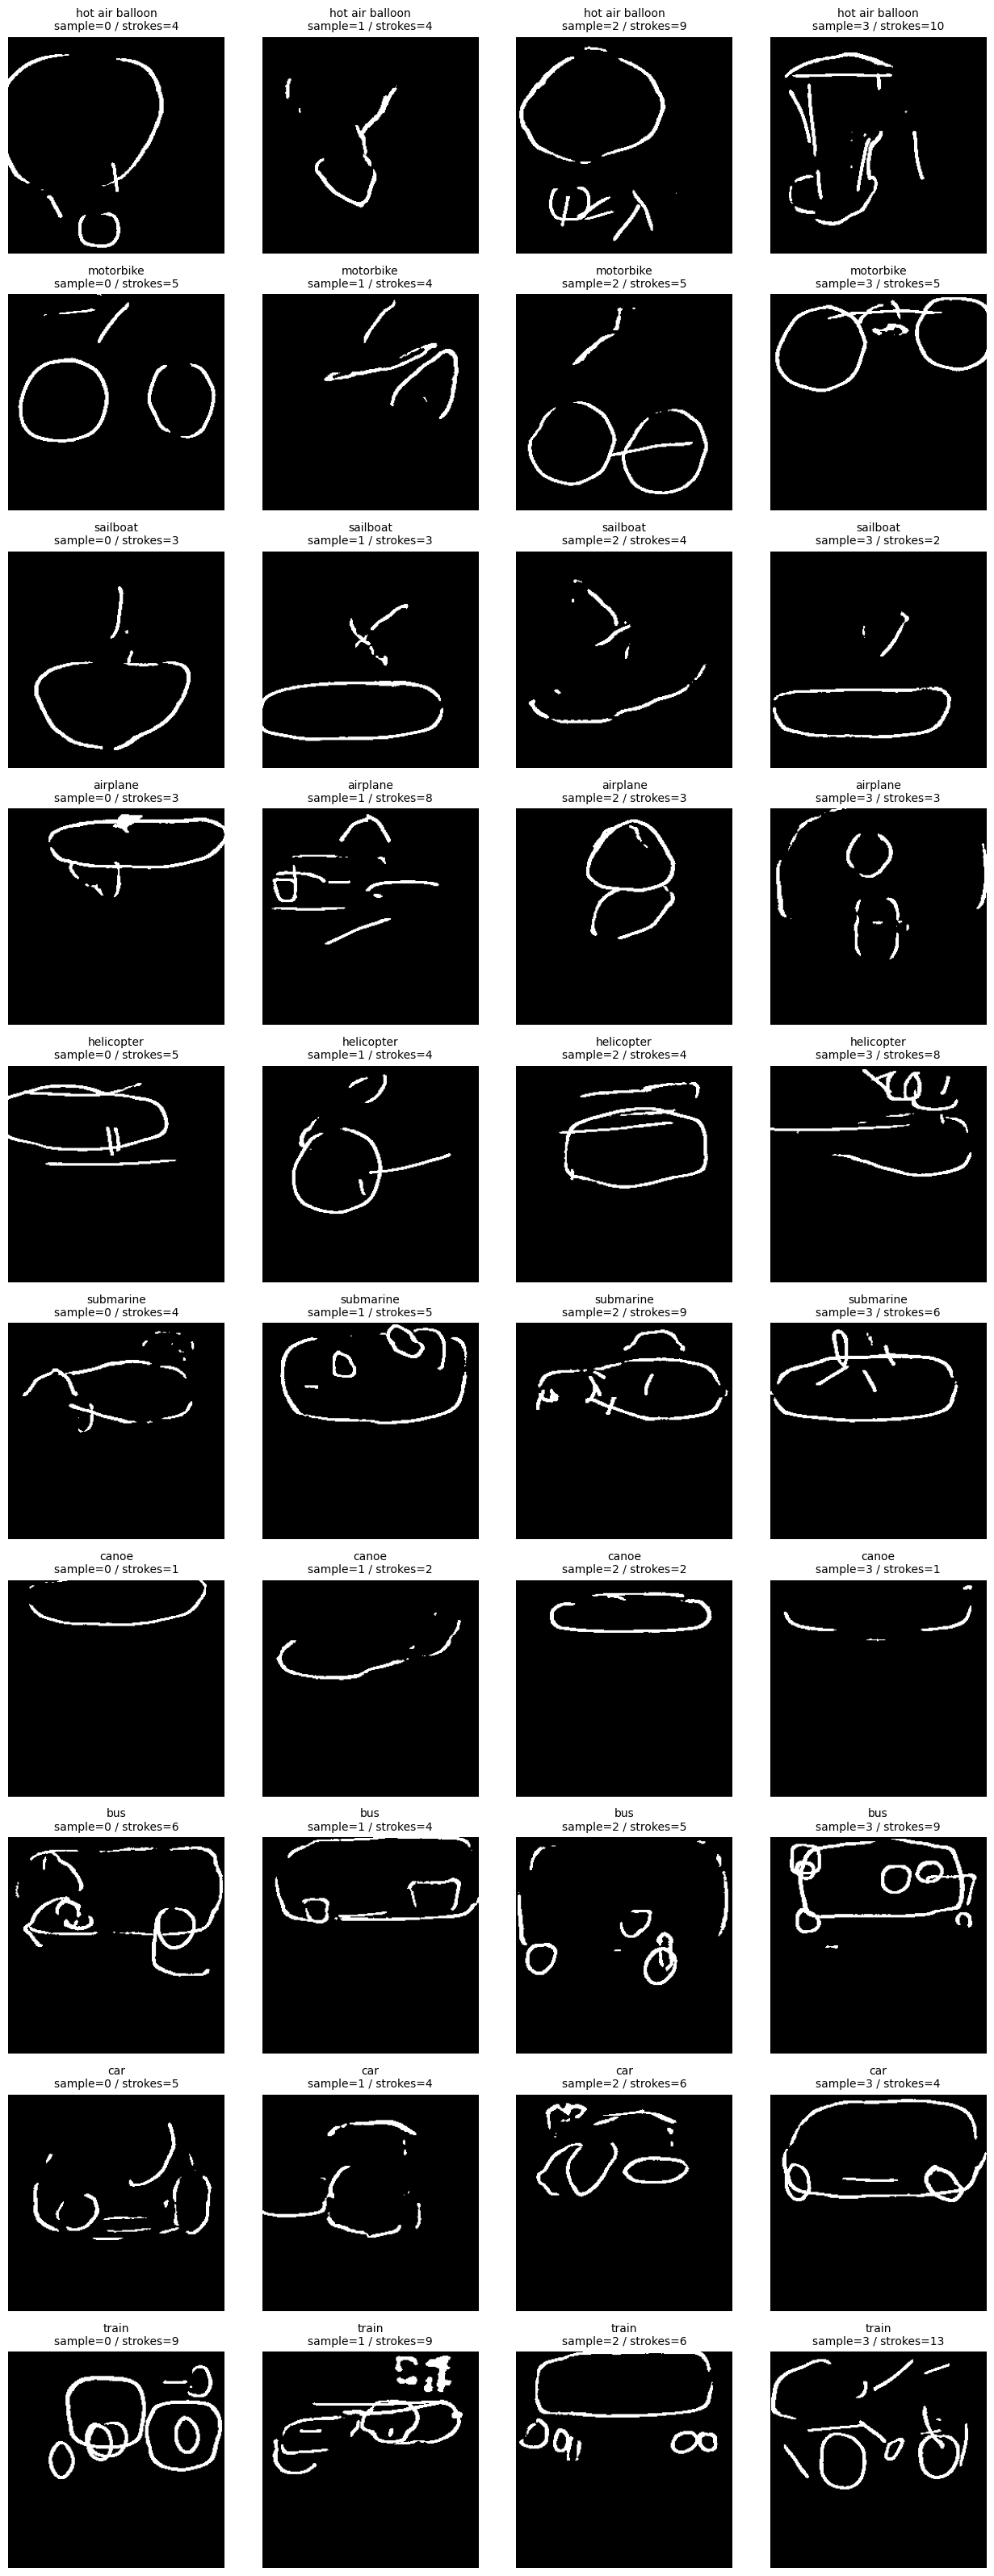

In [19]:
# ===== 1) Class-conditioned generation visualization =====

CLASS_NAMES_TO_SHOW = None   # 예: ["hot air balloon", "motorbike"]
SAMPLES_PER_CLASS = 4
TEMPERATURE = float(_GEN_CFG["generator"]["temperature"])
TOP_P = float(_GEN_CFG["generator"]["top_p"])
MAX_STEPS = int(_GEN_CFG["dataset"]["max_strokes"])
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

all_class_names = list(_GEN_CFG["dataset"]["classes"])
class_names = all_class_names if CLASS_NAMES_TO_SHOW is None else list(CLASS_NAMES_TO_SHOW)

n_rows = len(class_names)
n_cols = SAMPLES_PER_CLASS
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
if n_rows == 1:
    axes = np.array([axes])
if axes.ndim == 1:
    axes = axes.reshape(n_rows, n_cols)

for row, class_name in enumerate(class_names):
    class_id = _class_name_to_id(_GEN_CFG, class_name)
    samples = sample_class_conditioned_sketches(
        _GEN_CFG,
        generator,
        shape_ae,
        location_ae,
        shape_tokenizer,
        location_tokenizer,
        class_id=class_id,
        num_samples=SAMPLES_PER_CLASS,
        device=_DEVICE,
        max_steps=MAX_STEPS,
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )

    for col in range(n_cols):
        ax = axes[row, col]
        ax.axis("off")

        item = samples[col]   # list에서 개별 sample dict 꺼냄

        if "canvas" in item:
            canvas = item["canvas"]
        elif "canvases" in item:
            canvas = item["canvases"]
        else:
            raise KeyError(f"canvas key not found. available keys: {list(item.keys())}")

        if "length" in item:
            length = int(item["length"])
        elif "lengths" in item:
            length = int(item["lengths"])
        elif "shape_tokens" in item:
            length = len(item["shape_tokens"])
        else:
            length = 0

        ax.imshow(canvas, cmap="gray")
        ax.set_title(f"{class_name}\nsample={col} / strokes={length}", fontsize=10)

plt.tight_layout()
plt.show()

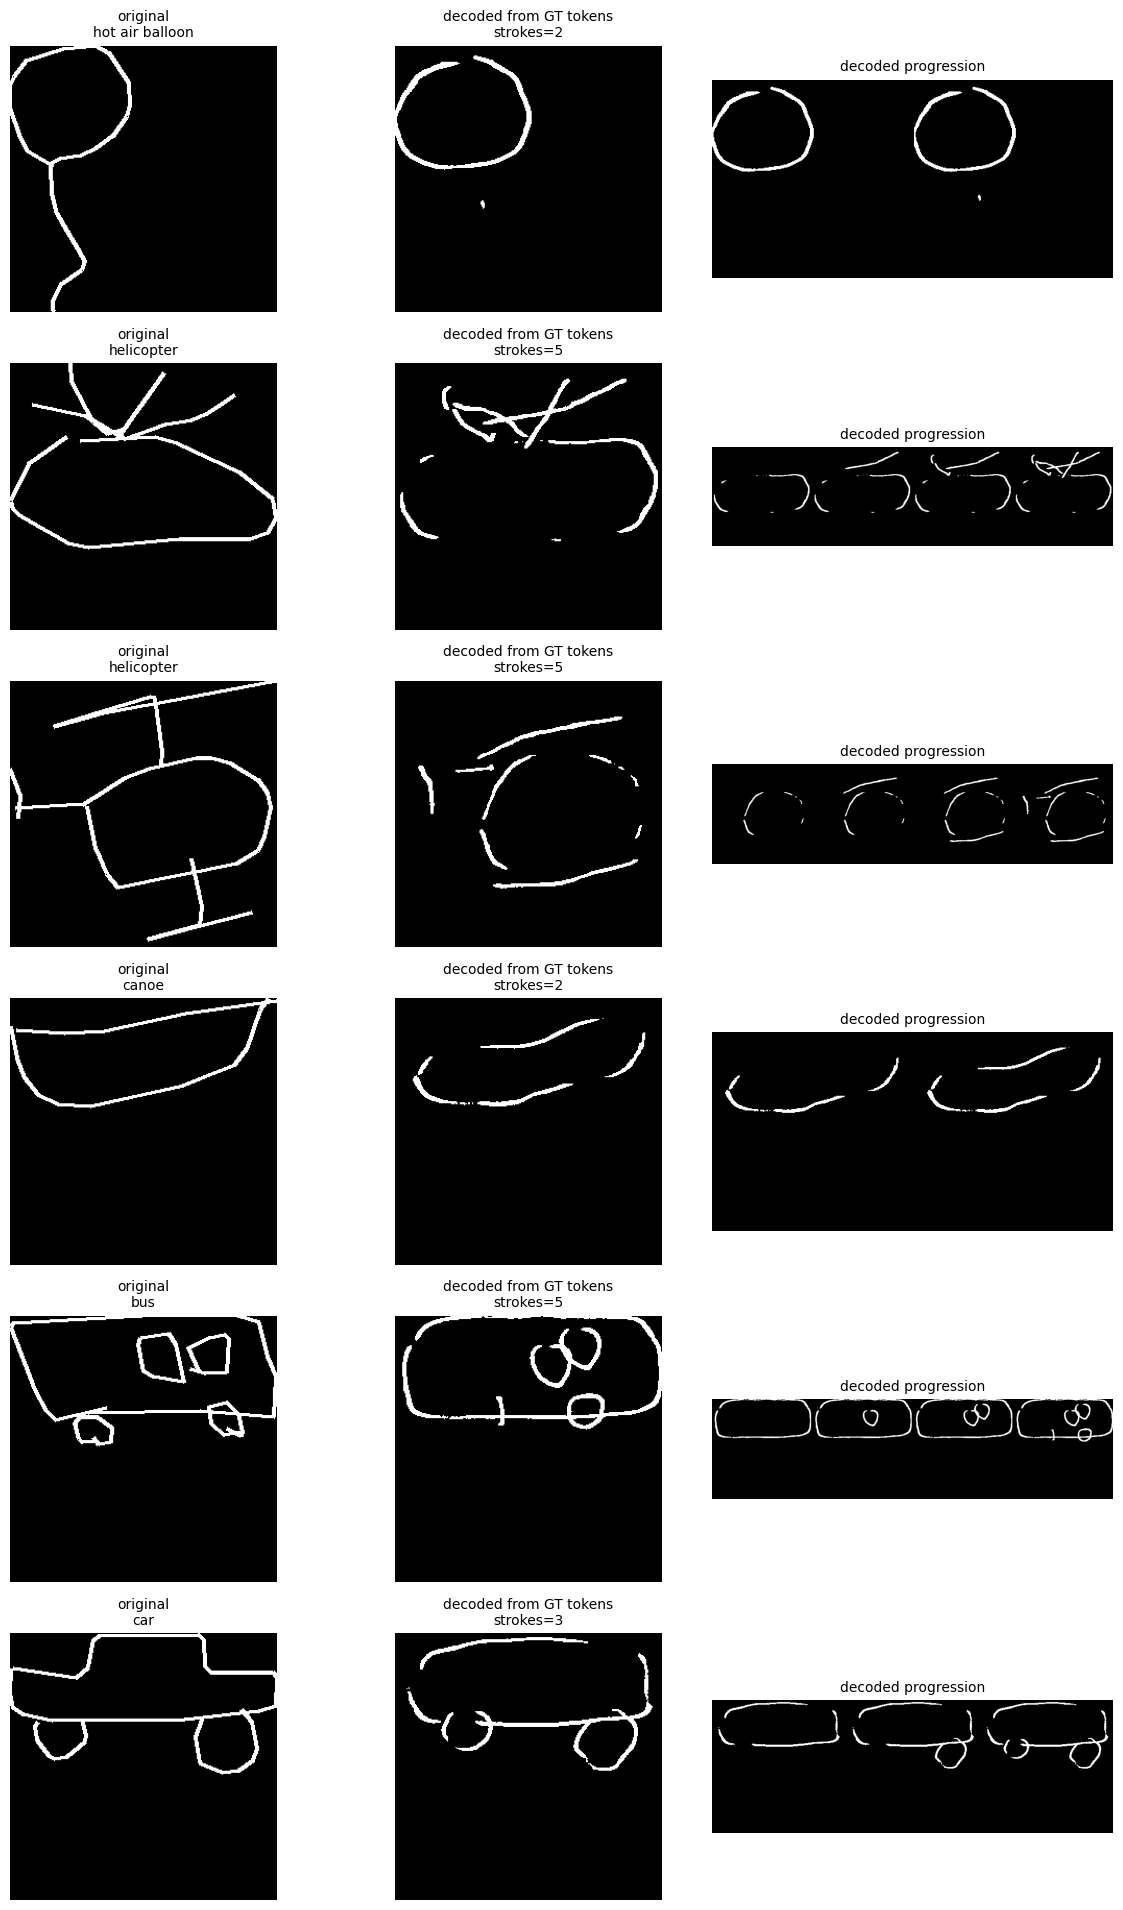

In [20]:
# ===== 2) Decode GT tokens and compare with original sketches =====

SPLIT = "val"                # "train" / "val" / "test"
CLASS_NAMES_TO_SHOW = None   # 예: ["hot air balloon"]
N_SHOW = 6
SEED = 42
N_PROGRESS_FRAMES = 4

npz_tokens = _get_token_npz(SPLIT)
rows = _filter_token_rows(npz_tokens, _VIS_CFG, class_names=CLASS_NAMES_TO_SHOW)
rows = _sample_rows(rows, n_show=N_SHOW, seed=SEED)

assert len(rows) > 0, "No matching samples found."

source_indices = npz_tokens["source_indices"].astype(np.int64)
shape_tokens = npz_tokens["shape_tokens"].astype(np.int64)
loc_tokens = npz_tokens["loc_tokens"].astype(np.int64)
lengths = npz_tokens["lengths"].astype(np.int64)
class_ids = npz_tokens["class_ids"].astype(np.int64)

fig, axes = plt.subplots(len(rows), 3, figsize=(12, 3.2 * len(rows)))
if len(rows) == 1:
    axes = np.array([axes])

for r, row_idx in enumerate(rows):
    class_name = _VIS_CFG["dataset"]["classes"][int(class_ids[row_idx])]
    L = int(lengths[row_idx])

    original_canvas, record = _render_full_sketch_from_index(
        _VIS_CFG,
        split=SPLIT,
        sketch_index=int(source_indices[row_idx]),
    )

    decoded_canvas, decoded_frames = decode_token_sequence(
        _VIS_CFG,
        shape_ae,
        location_ae,
        shape_tokenizer,
        location_tokenizer,
        shape_tokens[row_idx, :L],
        loc_tokens[row_idx, :L],
    )
    progress_strip = _make_progress_strip(decoded_frames, n_frames=N_PROGRESS_FRAMES)

    axes[r, 0].imshow(original_canvas, cmap="gray")
    axes[r, 0].set_title(f"original\n{class_name}", fontsize=10)
    axes[r, 0].axis("off")

    axes[r, 1].imshow(decoded_canvas, cmap="gray")
    axes[r, 1].set_title(f"decoded from GT tokens\nstrokes={L}", fontsize=10)
    axes[r, 1].axis("off")

    if progress_strip is not None:
        axes[r, 2].imshow(progress_strip, cmap="gray")
        axes[r, 2].set_title("decoded progression", fontsize=10)
    else:
        axes[r, 2].imshow(decoded_canvas, cmap="gray")
        axes[r, 2].set_title("decoded progression", fontsize=10)
    axes[r, 2].axis("off")

plt.tight_layout()
plt.show()

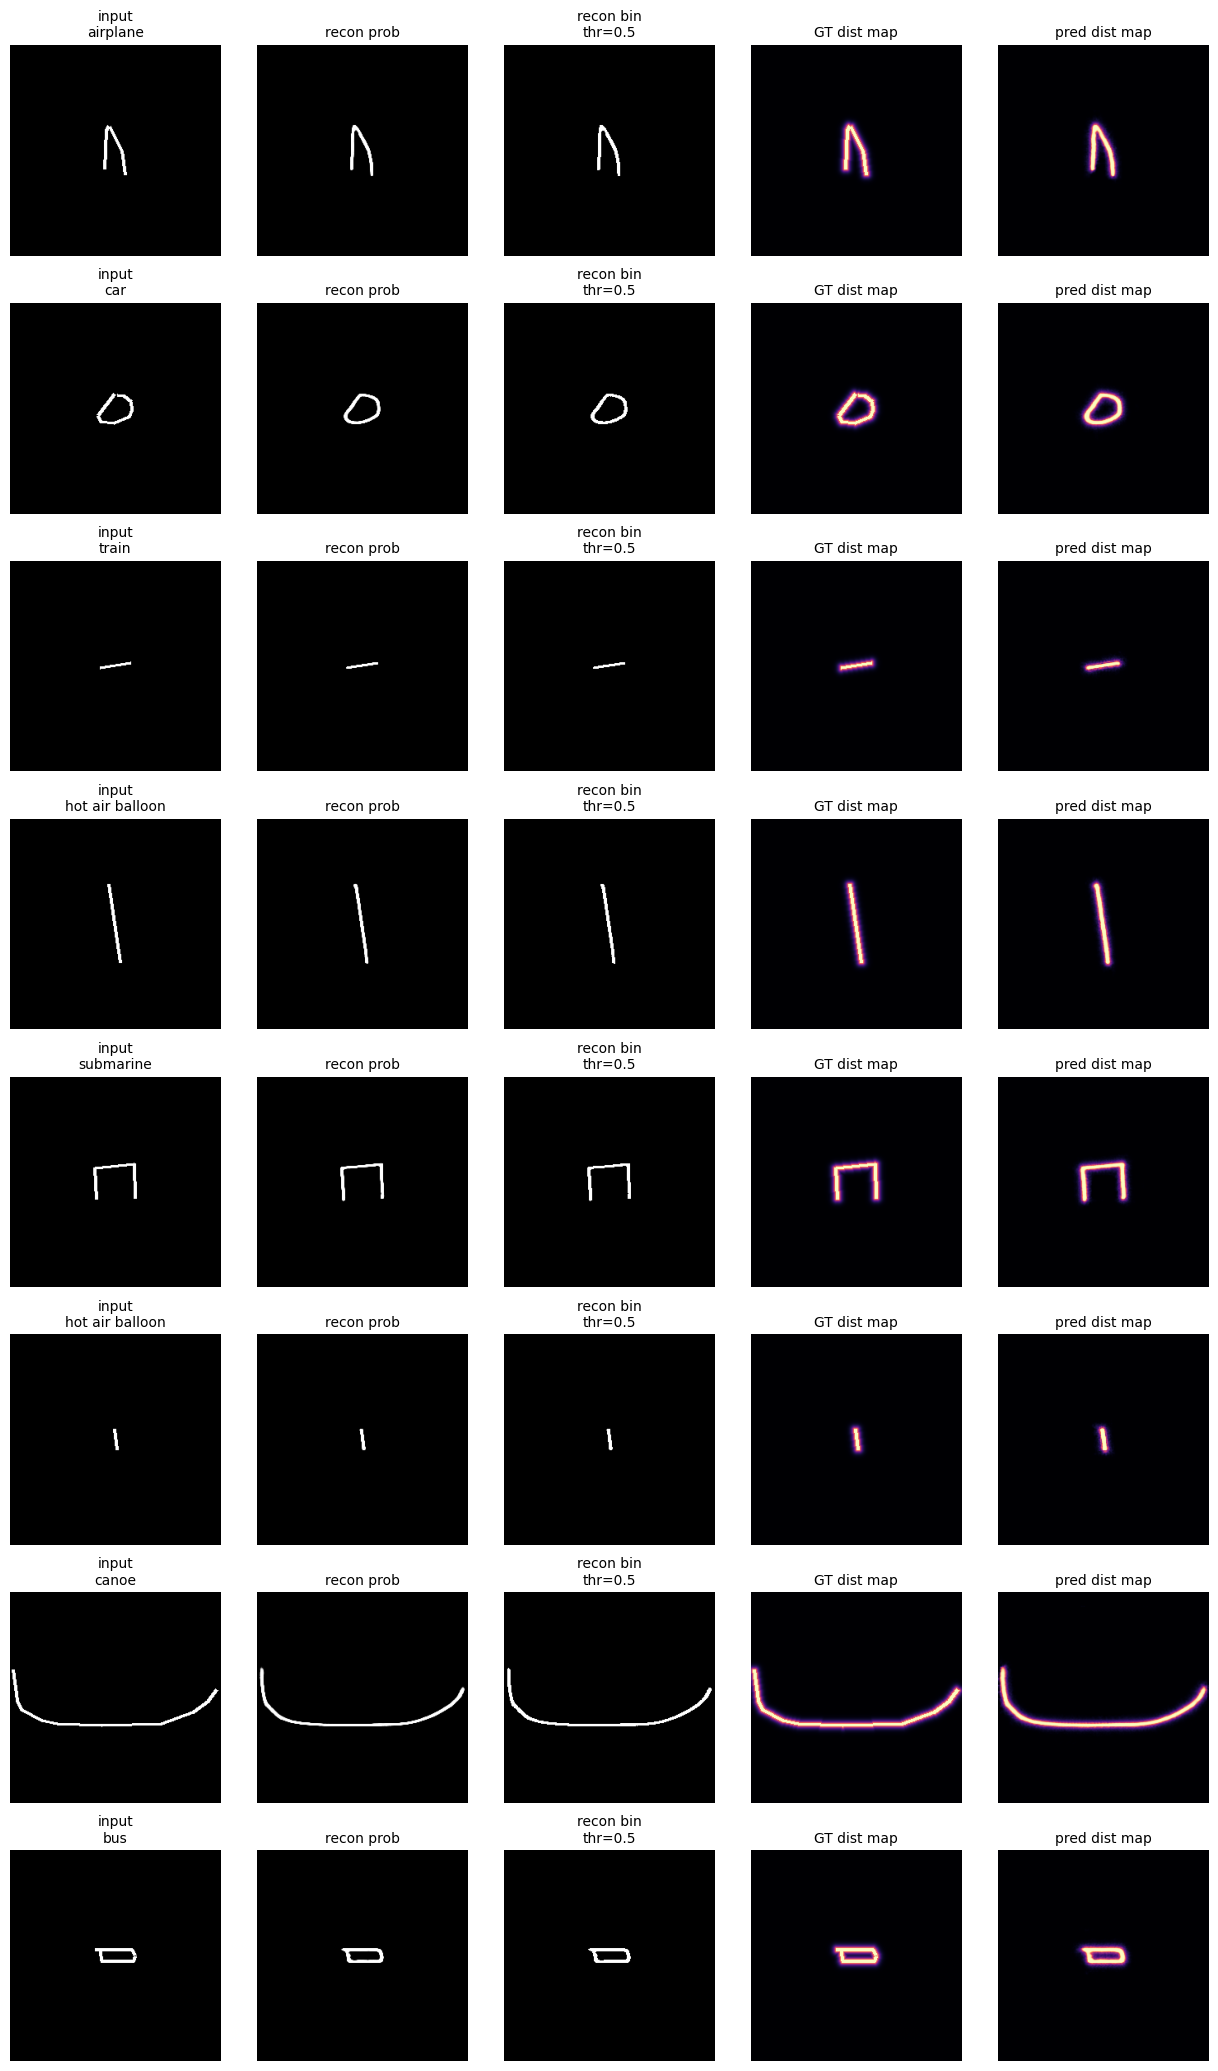

In [21]:
# ===== 3) Shape AE reconstruction debug =====

SPLIT = "val"
CLASS_NAME = None    # 예: "motorbike"
N_SHOW = 8
SEED = 42
THRESH = 0.5

shape_ds = QuickDrawStrokeDataset(_VIS_CFG, split=SPLIT, mode="shape_ae")

candidate_indices = []
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(shape_ds))
for ds_idx in perm:
    item = shape_ds[int(ds_idx)]
    class_name = _VIS_CFG["dataset"]["classes"][int(item["class_id"])]
    if (CLASS_NAME is None) or (class_name == CLASS_NAME):
        candidate_indices.append(int(ds_idx))
    if len(candidate_indices) >= N_SHOW:
        break

assert len(candidate_indices) > 0, "No matching stroke samples found."

fig, axes = plt.subplots(len(candidate_indices), 5, figsize=(12.5, 2.6 * len(candidate_indices)))
if len(candidate_indices) == 1:
    axes = np.array([axes])

with torch.no_grad():
    for row, ds_idx in enumerate(candidate_indices):
        item = shape_ds[ds_idx]
        x = item["image"].unsqueeze(0).to(_DEVICE)
        out = shape_ae(x)

        inp = item["image"].squeeze(0).cpu().numpy()
        recon_prob = out["bitmap"].squeeze(0).squeeze(0).cpu().numpy()
        recon_bin = (recon_prob >= THRESH).astype(np.float32)
        gt_dist = item["dist_map"].squeeze(0).cpu().numpy()
        pred_dist = out["dist_map"].squeeze(0).squeeze(0).cpu().numpy()

        class_name = _VIS_CFG["dataset"]["classes"][int(item["class_id"])]

        axes[row, 0].imshow(inp, cmap="gray")
        axes[row, 0].set_title(f"input\n{class_name}", fontsize=10)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(recon_prob, cmap="gray")
        axes[row, 1].set_title("recon prob", fontsize=10)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(recon_bin, cmap="gray")
        axes[row, 2].set_title(f"recon bin\nthr={THRESH}", fontsize=10)
        axes[row, 2].axis("off")

        axes[row, 3].imshow(gt_dist, cmap="magma")
        axes[row, 3].set_title("GT dist map", fontsize=10)
        axes[row, 3].axis("off")

        axes[row, 4].imshow(pred_dist, cmap="magma")
        axes[row, 4].set_title("pred dist map", fontsize=10)
        axes[row, 4].axis("off")

plt.tight_layout()
plt.show()

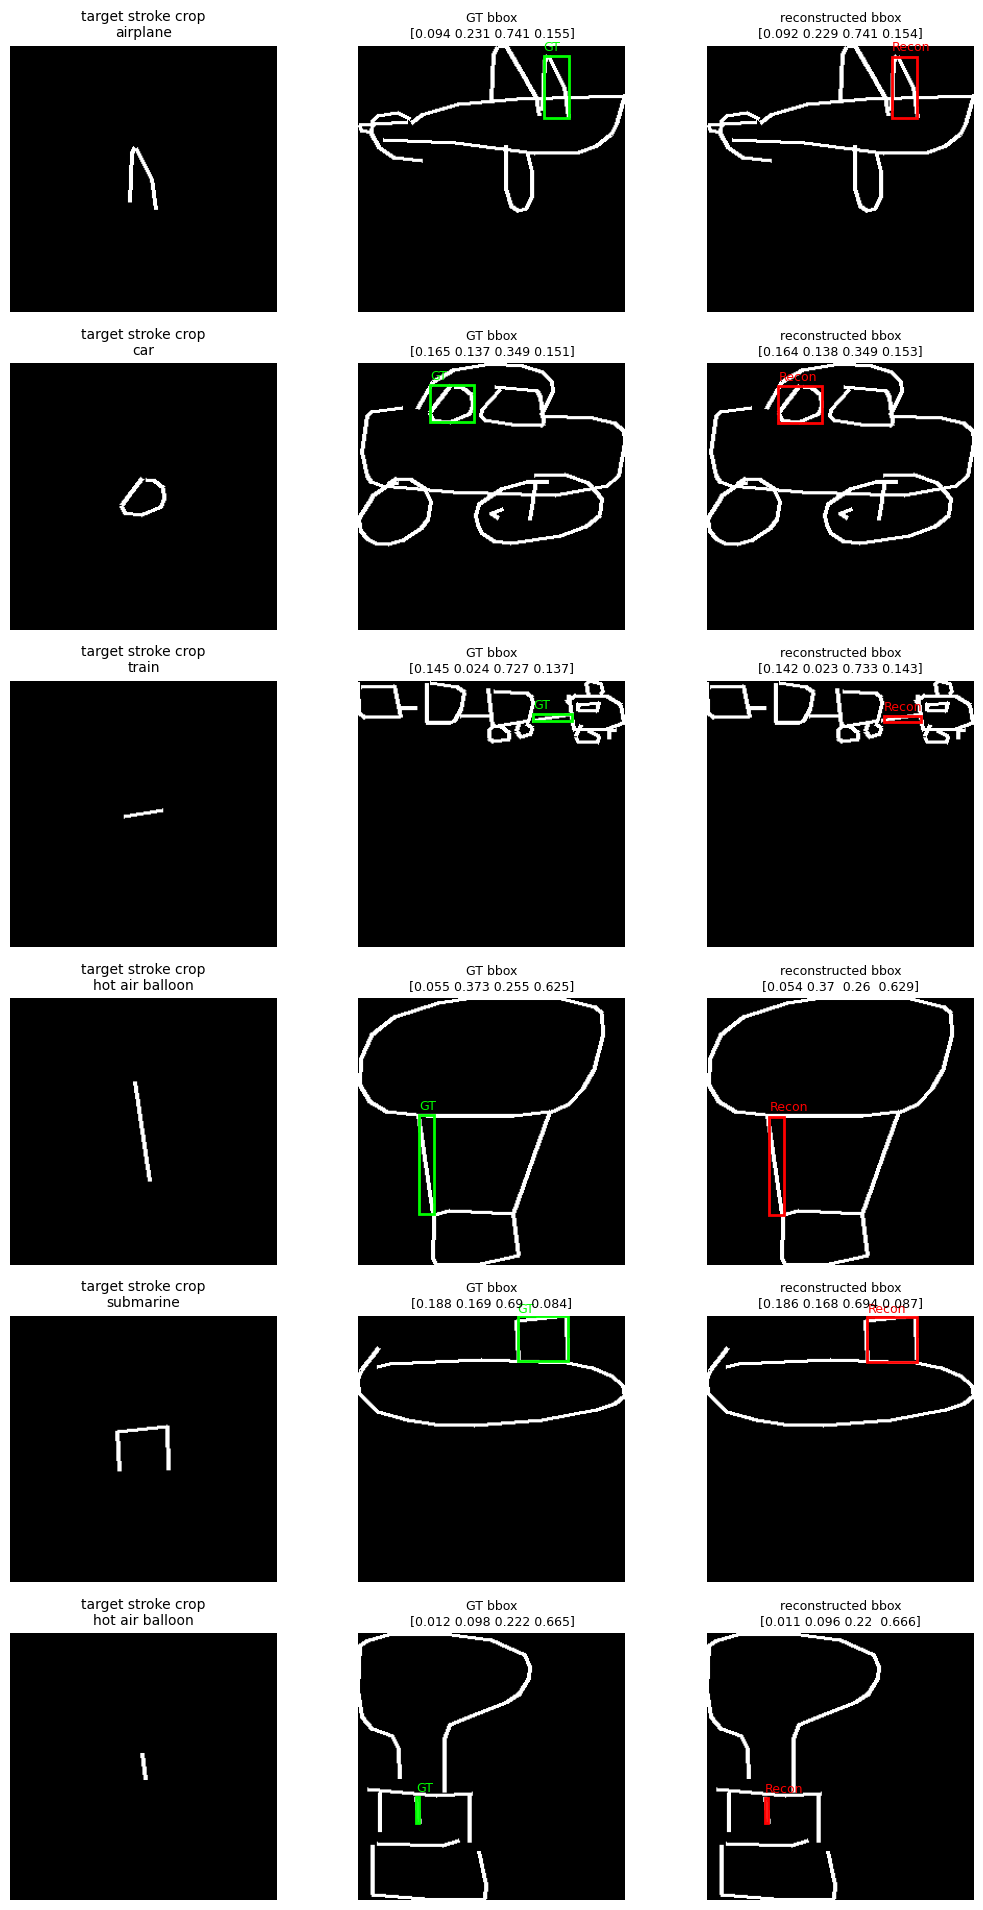

In [22]:
# ===== 4) Location AE reconstruction debug =====

SPLIT = "val"
CLASS_NAME = None   # 예: "motorbike"
N_SHOW = 6
SEED = 42

loc_ds = QuickDrawStrokeDataset(_VIS_CFG, split=SPLIT, mode="location_ae")

candidate_indices = []
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(loc_ds))
for ds_idx in perm:
    item = loc_ds[int(ds_idx)]
    class_name = _VIS_CFG["dataset"]["classes"][int(item["class_id"])]
    if (CLASS_NAME is None) or (class_name == CLASS_NAME):
        candidate_indices.append(int(ds_idx))
    if len(candidate_indices) >= N_SHOW:
        break

assert len(candidate_indices) > 0, "No matching stroke samples found."

fig, axes = plt.subplots(len(candidate_indices), 3, figsize=(11, 3.2 * len(candidate_indices)))
if len(candidate_indices) == 1:
    axes = np.array([axes])

canvas_size = int(_VIS_CFG["dataset"]["canvas_size"])

with torch.no_grad():
    for row, ds_idx in enumerate(candidate_indices):
        item = loc_ds[ds_idx]
        bbox_gt = item["vector"].cpu().numpy()
        bbox_pred = location_ae(item["vector"].unsqueeze(0).to(_DEVICE))["recon"].squeeze(0).cpu().numpy()

        sketch_idx = int(item["sketch_index"])
        stroke_local_idx = int(loc_ds.index.stroke_local_index[ds_idx])
        full_canvas, record = _render_full_sketch_from_index(_VIS_CFG, split=SPLIT, sketch_index=sketch_idx)
        stroke_points = record["point_strokes"][stroke_local_idx]

        rendered = render_single_stroke_to_normalized_bbox(
            stroke_points,
            image_size=int(_VIS_CFG["dataset"]["image_size"]),
            source_canvas_size=int(_VIS_CFG["dataset"]["source_canvas_size"]),
            line_width=int(_VIS_CFG["dataset"]["shape_stroke_width"]),
            distance_decay=float(_VIS_CFG["dataset"]["distance_decay"]),
            center_scale_margin=float(_VIS_CFG["dataset"]["shape_center_scale_margin"]),
            max_canvas_coverage=float(_VIS_CFG["dataset"]["shape_max_canvas_coverage"]),
        )
        stroke_img = rendered.image

        class_name = _VIS_CFG["dataset"]["classes"][int(item["class_id"])]

        axes[row, 0].imshow(stroke_img, cmap="gray")
        axes[row, 0].set_title(f"target stroke crop\n{class_name}", fontsize=10)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(full_canvas, cmap="gray")
        _draw_bbox(axes[row, 1], bbox_gt, canvas_size=canvas_size, color="lime", linewidth=2, label="GT")
        axes[row, 1].set_title(
            "GT bbox\n" + np.array2string(bbox_gt, precision=3, suppress_small=True),
            fontsize=9,
        )
        axes[row, 1].axis("off")

        axes[row, 2].imshow(full_canvas, cmap="gray")
        _draw_bbox(axes[row, 2], bbox_pred, canvas_size=canvas_size, color="red", linewidth=2, label="Recon")
        axes[row, 2].set_title(
            "reconstructed bbox\n" + np.array2string(bbox_pred, precision=3, suppress_small=True),
            fontsize=9,
        )
        axes[row, 2].axis("off")

plt.tight_layout()
plt.show()